In [111]:
import pandas as pd
from pathlib import Path

# Point to the folder containing the CSV files (current notebook folder).
data_dir = Path('.')

calendar = pd.read_csv(data_dir / 'calendar.csv')
customers = pd.read_csv(data_dir / 'customers.csv')
products = pd.read_csv(data_dir / 'products.csv')
sales = pd.read_csv(data_dir / 'sales.csv')
stores = pd.read_csv(data_dir / 'stores.csv')

print('Loaded shapes:')
print('calendar :', calendar.shape)
print('customers:', customers.shape)
print('products :', products.shape)
print('sales    :', sales.shape)
print('stores   :', stores.shape)

# Quick preview
display(calendar.head())
display(customers.head())
display(products.head())
display(sales.head())
display(stores.head())

Loaded shapes:
calendar : (731, 6)
customers: (50000, 5)
products : (200, 6)
sales    : (1000000, 11)
stores   : (100, 5)


,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31


,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online


In [112]:
# Put all datasets in one dictionary for easy processing
dfs = {
    'calendar': calendar,
    'customers': customers,
    'products': products,
    'sales': sales,
    'stores': stores
}

# 1) Check null counts and percentages
null_report = {}
for name, df in dfs.items():
    report = pd.DataFrame({
        'null_count': df.isnull().sum(),
        'null_pct': (df.isnull().mean() * 100).round(2)
    })
    report = report[report['null_count'] > 0].sort_values('null_count', ascending=False)
    null_report[name] = report
    
    print(f"\n{name.upper()} - columns with nulls")
    if report.empty:
        print('No missing values')
    else:
        display(report)

# 2) Handle nulls (create cleaned copies so originals are preserved)
cleaned_dfs = {}
for name, df in dfs.items():
    temp = df.copy()

    # Try to detect date-like columns and fill with forward/backward fill
    for col in temp.columns:
        if 'date' in col.lower() or 'dt' in col.lower():
            temp[col] = temp[col].ffill().bfill()

    # Fill numeric columns with median
    num_cols = temp.select_dtypes(include='number').columns
    for col in num_cols:
        temp[col] = temp[col].fillna(temp[col].median())

    # Fill non-numeric columns with mode; fallback to 'Unknown'
    cat_cols = temp.select_dtypes(exclude='number').columns
    for col in cat_cols:
        if temp[col].isnull().any():
            mode_vals = temp[col].mode(dropna=True)
            fill_value = mode_vals.iloc[0] if not mode_vals.empty else 'Unknown'
            temp[col] = temp[col].fillna(fill_value)

    cleaned_dfs[name] = temp

# Unpack cleaned dataframes if you want to use them directly
calendar_clean = cleaned_dfs['calendar']
customers_clean = cleaned_dfs['customers']
products_clean = cleaned_dfs['products']
sales_clean = cleaned_dfs['sales']
stores_clean = cleaned_dfs['stores']

print('\nMissing value handling complete.')


CALENDAR - columns with nulls
No missing values

CUSTOMERS - columns with nulls
No missing values

PRODUCTS - columns with nulls
No missing values

SALES - columns with nulls
No missing values

STORES - columns with nulls
No missing values

Missing value handling complete.


In [113]:
for name, df in {
    "calendar": calendar,
    "customers": customers,
    "products": products,
    "sales": sales,
    "stores": stores
}.items():
    print(name, "->", int(df.isnull().sum().sum()), "nulls")

calendar -> 0 nulls
customers -> 0 nulls
products -> 0 nulls
sales -> 0 nulls
stores -> 0 nulls


In [114]:
# Calendar rename

#Rename specific columns
calendar_renamed = calendar_clean.rename(columns={
    'date': 'calendar_date',
    'day_of_week': 'weekday'
})


print(list(calendar_renamed.columns))



['calendar_date', 'year', 'month', 'day', 'week', 'weekday']


In [115]:
# Customers rename examples

print('Customers columns:')
print(list(customers_clean.columns))

# Rename specific columns
customers_renamed = customers_clean.rename(columns={
    'customer_id': 'cust_id',
    'loyalty_member': 'is_loyalty_member',
    
})

print('\nSelective rename:')
print(list(customers_renamed.columns))

Customers columns:
['customer_id', 'age', 'gender', 'loyalty_member', 'join_date']

Selective rename:
['cust_id', 'age', 'gender', 'is_loyalty_member', 'join_date']


In [116]:
# Check data types for all datasets
for name, df in {
    'calendar': calendar,
    'customers': customers,
    'products': products,
    'sales': sales,
    'stores': stores
}.items():
    print(f"\n{name.upper()} dtypes:")
    display(df.dtypes.to_frame('dtype'))


CALENDAR dtypes:


,dtype
date,str
year,int64
month,int64
day,int64
week,int64
day_of_week,int64



CUSTOMERS dtypes:


,dtype
customer_id,str
age,int64
gender,str
loyalty_member,int64
join_date,str



PRODUCTS dtypes:


,dtype
product_id,str
product_name,str
brand,str
category,str
cocoa_percent,int64
weight_g,int64



SALES dtypes:


,dtype
order_id,str
order_date,str
product_id,str
store_id,str
customer_id,str
quantity,int64
unit_price,float64
discount,float64
revenue,float64
cost,float64



STORES dtypes:


,dtype
store_id,str
store_name,str
city,str
country,str
store_type,str


In [117]:
# Display DataFrame info for all datasets
for name, df in {
    'calendar': calendar,
    'customers': customers,
    'products': products,
    'sales': sales,
    'stores': stores
}.items():
    print(f"\n{'=' * 20} {name.upper()} INFO {'=' * 20}")
    df.info()


==================== CALENDAR INFO ====================
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         731 non-null    str  
 1   year         731 non-null    int64
 2   month        731 non-null    int64
 3   day          731 non-null    int64
 4   week         731 non-null    int64
 5   day_of_week  731 non-null    int64
dtypes: int64(5), str(1)
memory usage: 34.4 KB

==================== CUSTOMERS INFO ====================
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     50000 non-null  str  
 1   age             50000 non-null  int64
 2   gender          50000 non-null  str  
 3   loyalty_member  50000 non-null  int64
 4   join_date       50000 non-null  str  
dtypes: int64(2), str(3)
me

In [118]:
# Fix Data Type
calendar['date'] = pd.to_datetime(calendar['date'])
sales['order_date'] = pd.to_datetime(sales['order_date'])
customers['join_date'] = pd.to_datetime(customers['join_date'])

In [119]:
# Integrate all tables into one analysis-ready dataset
calendar_analysis = calendar_clean.copy()
customers_analysis = customers_clean.copy()
products_analysis = products_clean.copy()
sales_analysis = sales_clean.copy()
stores_analysis = stores_clean.copy()

# Convert date columns before merging
calendar_analysis['date'] = pd.to_datetime(calendar_analysis['date'])
customers_analysis['join_date'] = pd.to_datetime(customers_analysis['join_date'])
sales_analysis['order_date'] = pd.to_datetime(sales_analysis['order_date'])

# Merge sales with dimension tables
analysis_df = (
    sales_analysis
    .merge(products_analysis, on='product_id', how='left', validate='m:1')
    .merge(customers_analysis, on='customer_id', how='left', validate='m:1')
    .merge(stores_analysis, on='store_id', how='left', validate='m:1')
    .merge(
        calendar_analysis,
        left_on='order_date',
        right_on='date',
        how='left',
        validate='m:1'
    )
)

print('Integrated dataset shape:', analysis_df.shape)
print('\nIntegrated dataset columns:')
print(list(analysis_df.columns))

display(analysis_df.head(10))

Integrated dataset shape: (1000000, 30)

Integrated dataset columns:
['order_id', 'order_date', 'product_id', 'store_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'age', 'gender', 'loyalty_member', 'join_date', 'store_name', 'city', 'country', 'store_type', 'date', 'year', 'month', 'day', 'week', 'day_of_week']


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,store_name,city,country,store_type,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,Chocolate Store 93,Sydney,UK,Airport,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,Chocolate Store 65,New York,Australia,Retail,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,Chocolate Store 78,London,UK,Airport,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,Chocolate Store 88,Toronto,USA,Retail,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,Chocolate Store 54,London,Canada,Online,2024-09-24,2024,9,24,39,1
5,0RD00000006,2024-03-29,P0160,S089,C008918,4,13.52,0.00,54.08,36.59,...,Chocolate Store 89,Paris,Canada,Online,2024-03-29,2024,3,29,13,4
6,0RD00000007,2023-02-26,P0062,S024,C002897,1,11.97,0.10,10.77,7.16,...,Chocolate Store 24,Paris,France,Online,2023-02-26,2023,2,26,8,6
7,0RD00000008,2023-11-03,P0111,S085,C038072,5,4.62,0.00,23.10,16.15,...,Chocolate Store 85,Melbourne,USA,Online,2023-11-03,2023,11,3,44,4
8,0RD00000009,2024-10-11,P0135,S029,C003786,4,7.88,0.00,31.52,19.90,...,Chocolate Store 29,Melbourne,Australia,Online,2024-10-11,2024,10,11,41,4
9,0RD00000010,2023-12-17,P0069,S056,C043148,3,8.88,0.00,26.64,18.19,...,Chocolate Store 56,Melbourne,Germany,Online,2023-12-17,2023,12,17,50,6


In [120]:
total_revenue = analysis_df['revenue'].sum()
print(f"Total revenue: {total_revenue:,.2f}")

Total revenue: 25,486,128.86


In [121]:
total_orders = analysis_df['order_id'].nunique()
print(f"Total orders placed: {total_orders:,}")

Total orders placed: 1,000,000


In [122]:
# Average order value?
average_order_value = total_revenue / total_orders
print(f"Average order value: {average_order_value:,.2f}")

Average order value: 25.49


In [123]:
# Total quantity sold?
total_quantity_sold = analysis_df['quantity'].sum()
print(f"Total quantity sold: {total_quantity_sold:,}")

Total quantity sold: 2,999,589


In [124]:
# Month with highest sales?
import calendar as cal

monthly_sales = analysis_df.groupby('month')['revenue'].sum()
highest_sales_month = monthly_sales.idxmax()
month_name = cal.month_name[highest_sales_month]

print(f"Month with the highest sales: {month_name} (Month {highest_sales_month}) with revenue {monthly_sales.max():,.2f}")

Month with the highest sales: January (Month 1) with revenue 2,179,770.20


In [125]:
# Year-over-year (YoY) growth?
yoy_growth = (analysis_df.groupby('year')['revenue'].sum().pct_change() * 100).iloc[-1]
print(f"Year-over-year (YoY) growth: {yoy_growth:.2f}%")

Year-over-year (YoY) growth: 0.12%


In [126]:
# Day of the week with highest sales?
day_names = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday', 7: 'Sunday'}

daily_sales = analysis_df.groupby('day_of_week')['revenue'].sum()
highest_sales_day = daily_sales.idxmax()
day_name = day_names.get(highest_sales_day, f'Day {highest_sales_day}')

print(f"Day of the week with highest sales: {day_name} (Day {highest_sales_day}) with revenue {daily_sales.max():,.2f}")

Day of the week with highest sales: Monday (Day 1) with revenue 3,673,211.72


In [127]:
# What are the weekly sales trends?
weekly_sales = analysis_df.groupby('week')['revenue'].sum()
print("Weekly sales trends:")
print(weekly_sales)

Weekly sales trends:
week
1     568322.38
2     491335.85
3     492627.40
4     487311.85
5     492451.58
6     486726.10
7     486212.27
8     486006.48
9     493823.69
10    488691.26
11    485595.66
12    489944.81
13    485517.06
14    490919.69
15    485914.57
16    486382.87
17    479089.52
18    486077.51
19    485596.97
20    489598.26
21    489448.62
22    489296.50
23    486896.85
24    489723.83
25    487550.79
26    482193.90
27    492156.48
28    491003.14
29    484468.39
30    492340.69
31    488596.60
32    491223.18
33    486857.96
34    490902.93
35    494144.38
36    497188.54
37    488427.88
38    490893.27
39    490188.41
40    480692.92
41    481251.82
42    485918.45
43    488888.44
44    484612.78
45    484627.77
46    485434.07
47    482675.23
48    488311.40
49    493760.73
50    483278.00
51    487737.09
52    517292.04
Name: revenue, dtype: float64


In [128]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "-q"])
print("Plotly installed successfully!")

Plotly installed successfully!


In [129]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\hetal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


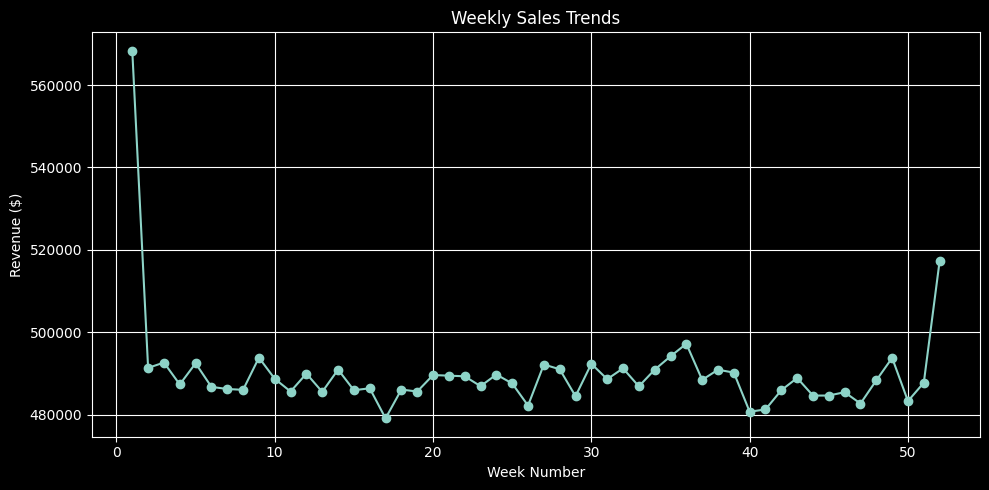


Weekly Sales Summary:


,Week,Revenue,Quantity,Orders
0,1,568322.38,66715,22226
1,2,491335.85,57657,19238
2,3,492627.40,58054,19383
3,4,487311.85,57284,19087
4,5,492451.58,57813,19220
5,6,486726.10,57694,19144
6,7,486212.27,57337,19195
7,8,486006.48,57181,19089
8,9,493823.69,57646,19173
9,10,488691.26,57457,19125


In [130]:
# Weekly sales trends

import matplotlib.pyplot as plt


weekly_sales = analysis_df.groupby('week').agg({
    'revenue': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'
}).reset_index()

weekly_sales.columns = ['Week', 'Revenue', 'Quantity', 'Orders']

# Plot line chart
plt.figure(figsize=(10, 5))
plt.plot(weekly_sales['Week'], weekly_sales['Revenue'], marker='o')

# Labels & title
plt.xlabel('Week Number')
plt.ylabel('Revenue ($)')
plt.title('Weekly Sales Trends')

# Improve readability
plt.grid(True)
plt.tight_layout()

# Show chart
plt.show()

print('\nWeekly Sales Summary:')
display(weekly_sales)

In [131]:
# The top-selling products?
top_selling_products = analysis_df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)
print("Top-selling products:")
print(top_selling_products)

Top-selling products:
product_name
Dark Chocolate 50%       1775041.34
Truffle Chocolate 80%    1643258.83
Milk Chocolate 70%       1384758.27
Praline Chocolate 50%    1382597.04
Dark Chocolate 60%       1272649.97
White Chocolate 50%      1265949.75
White Chocolate 90%      1137968.57
White Chocolate 80%      1133285.39
Truffle Chocolate 90%    1132883.80
Praline Chocolate 70%    1127404.94
Name: revenue, dtype: float64


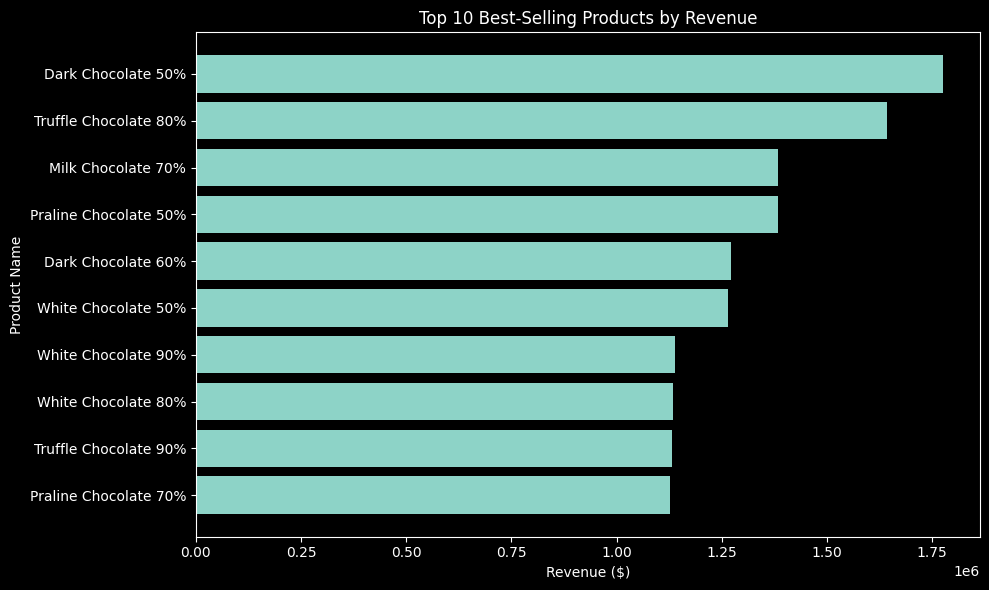


Top 10 Best-Selling Products:


,Product,Revenue,Quantity,Orders
12,Praline Chocolate 70%,1127404.94,132564,44377
19,Truffle Chocolate 90%,1132883.80,133692,44693
23,White Chocolate 80%,1133285.39,133171,44455
24,White Chocolate 90%,1137968.57,134217,44709
20,White Chocolate 50%,1265949.75,149170,49699
1,Dark Chocolate 60%,1272649.97,149346,49813
10,Praline Chocolate 50%,1382597.04,162670,54056
7,Milk Chocolate 70%,1384758.27,162335,54127
18,Truffle Chocolate 80%,1643258.83,193431,64490
0,Dark Chocolate 50%,1775041.34,208996,69625


In [132]:
# Top-selling products
import matplotlib.pyplot as plt

# Group by product and calculate metrics
top_products = analysis_df.groupby('product_name').agg({
    'revenue': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'
}).reset_index()

top_products.columns = ['Product', 'Revenue', 'Quantity', 'Orders']

# Get top 10 (highest revenue)
top_products = top_products.sort_values('Revenue', ascending=False).head(10)

# Reverse for horizontal bar (so highest is on top)
top_products = top_products.sort_values('Revenue', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_products['Product'], top_products['Revenue'])

# Labels & title
plt.xlabel('Revenue ($)')
plt.ylabel('Product Name')
plt.title('Top 10 Best-Selling Products by Revenue')

# Layout
plt.tight_layout()

# Show
plt.show()

print('\nTop 10 Best-Selling Products:')
display(top_products)

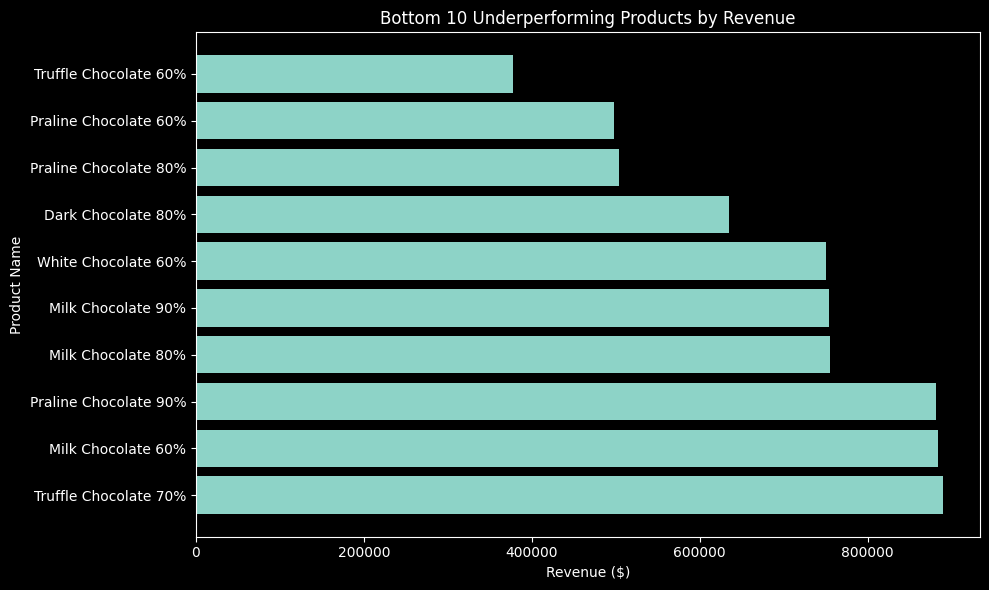


Bottom 10 Underperforming Products:


,Product,Revenue,Quantity,Orders,Avg_Price
17,Truffle Chocolate 70%,889254.20,104445,34853,8.51
6,Milk Chocolate 60%,883264.52,103564,34480,8.53
14,Praline Chocolate 90%,881139.19,103964,34522,8.48
8,Milk Chocolate 80%,754675.84,88784,29623,8.50
9,Milk Chocolate 90%,753459.18,88507,29690,8.51
21,White Chocolate 60%,750658.69,88704,29534,8.46
3,Dark Chocolate 80%,634638.76,74734,24798,8.49
13,Praline Chocolate 80%,503618.28,59422,19841,8.48
11,Praline Chocolate 60%,497887.59,58771,19566,8.47
16,Truffle Chocolate 60%,377126.43,44244,14811,8.52


In [133]:
# Underperforming Products (Low Sales)
import matplotlib.pyplot as plt

# Group all products
all_products = analysis_df.groupby('product_name').agg({
    'revenue': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'
}).reset_index()

all_products.columns = ['Product', 'Revenue', 'Quantity', 'Orders']

# Average price
all_products['Avg_Price'] = (all_products['Revenue'] / all_products['Quantity']).round(2)

# ✅ Get bottom 10 (Lowest revenue)
low_sales = all_products.sort_values('Revenue', ascending=True).head(10)

# Reverse for better display (small → big)
low_sales = low_sales.sort_values('Revenue', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(low_sales['Product'], low_sales['Revenue'])

# Labels
plt.xlabel('Revenue ($)')
plt.ylabel('Product Name')
plt.title('Bottom 10 Underperforming Products by Revenue')

plt.tight_layout()
plt.show()

print('\nBottom 10 Underperforming Products:')
display(low_sales)

,Product,Revenue,Quantity,Orders
0,Dark Chocolate 50%,1775041.34,208996,69625
18,Truffle Chocolate 80%,1643258.83,193431,64490
7,Milk Chocolate 70%,1384758.27,162335,54127
10,Praline Chocolate 50%,1382597.04,162670,54056
1,Dark Chocolate 60%,1272649.97,149346,49813
20,White Chocolate 50%,1265949.75,149170,49699
24,White Chocolate 90%,1137968.57,134217,44709
23,White Chocolate 80%,1133285.39,133171,44455
19,Truffle Chocolate 90%,1132883.80,133692,44693
12,Praline Chocolate 70%,1127404.94,132564,44377


Text(0.5, 1.0, 'Top 10 Products by Revenue')

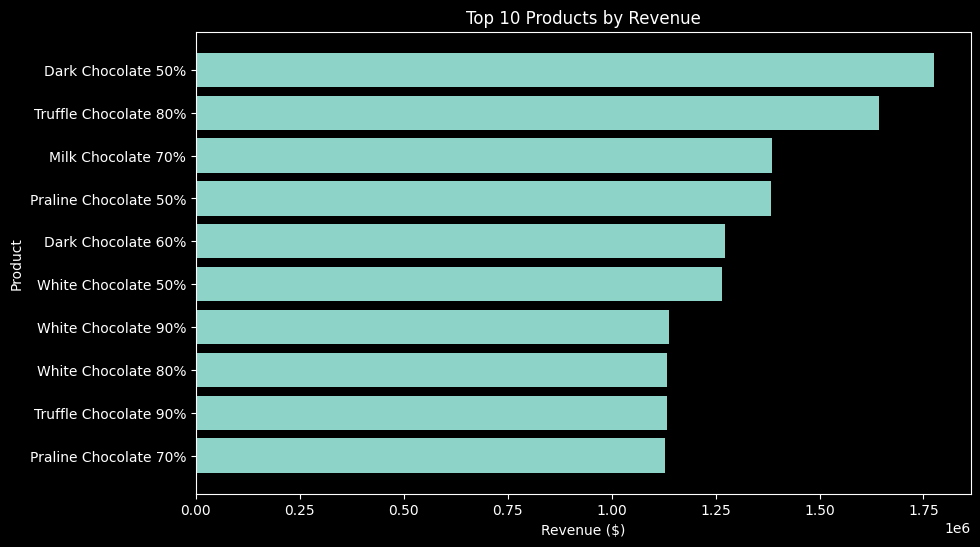

In [134]:
# Top 10 products by revenue - chart
import matplotlib.pyplot as plt

# Top 10 products by revenue
top_10_revenue = (
    analysis_df.groupby('product_name', as_index=False)['revenue']
    .sum()
    .sort_values('revenue', ascending=False)
    .head(10)
)
top_products = analysis_df.groupby('product_name').agg({
	'revenue': 'sum',
	'quantity': 'sum',
	'order_id': 'nunique'
}).reset_index()

top_products.columns = ['Product', 'Revenue', 'Quantity', 'Orders']
top_products = top_products.sort_values('Revenue', ascending=False).head(10)

display(top_products)

# Sort for horizontal chart (small → big)
plot_df = top_10_revenue.sort_values('revenue', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(plot_df['product_name'], plot_df['revenue'])

# Labels & title
plt.xlabel('Revenue ($)')
plt.ylabel('Product')
plt.title('Top 10 Products by Revenue')

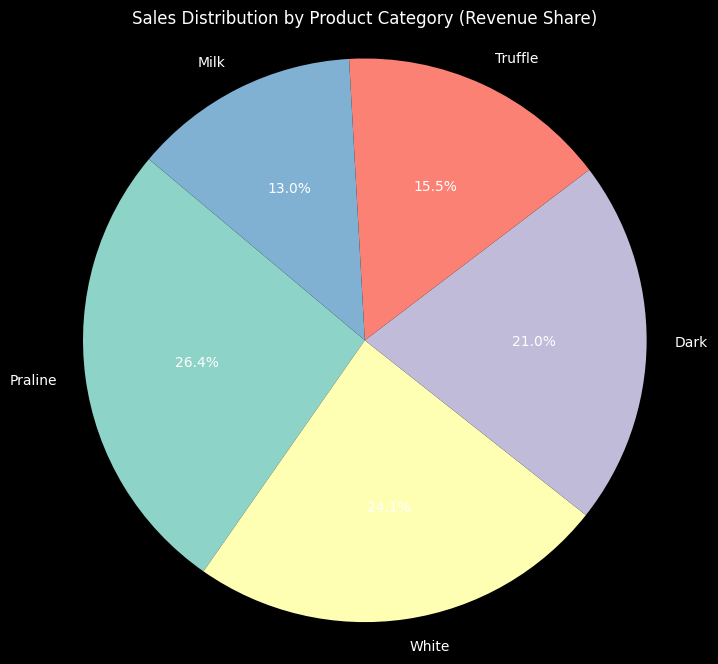

Sales distribution by product category:


,Category,Revenue,Quantity,Orders,Revenue Share %
2,Praline,6665641.32,784435,261678,26.41
4,White,6070172.20,714967,238513,24.05
0,Dark,5298123.27,623247,207727,20.99
3,Truffle,3924343.24,462202,153729,15.55
1,Milk,3280368.19,385619,128589,13.00


In [135]:
# Sales distribution by product category
import matplotlib.pyplot as plt

# Category sales aggregation
category_sales = (
    analysis_df.groupby('category', as_index=False)
    .agg(Revenue=('revenue', 'sum'),
         Quantity=('quantity', 'sum'),
         Orders=('order_id', 'nunique'))
    .sort_values('Revenue', ascending=False)
)

# Revenue share %
category_sales['Revenue Share %'] = (
    category_sales['Revenue'] / category_sales['Revenue'].sum() * 100
).round(2)

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    category_sales['Revenue'],
    labels=category_sales['category'],
    autopct='%1.1f%%',
    startangle=140
)

# Title
plt.title('Sales Distribution by Product Category (Revenue Share)')

# Equal aspect ratio
plt.axis('equal')

# Show
plt.show()

print('Sales distribution by product category:')
display(category_sales.rename(columns={'category': 'Category'}))

In [136]:

# Create analysis_df before charts
calendar_analysis = calendar_clean.copy()
customers_analysis = customers_clean.copy()
products_analysis = products_clean.copy()
sales_analysis = sales_clean.copy()
stores_analysis = stores_clean.copy()

calendar_analysis['date'] = pd.to_datetime(calendar_analysis['date'])
customers_analysis['join_date'] = pd.to_datetime(customers_analysis['join_date'])
sales_analysis['order_date'] = pd.to_datetime(sales_analysis['order_date'])

analysis_df = (
    sales_analysis
    .merge(products_analysis, on='product_id', how='left')
    .merge(customers_analysis, on='customer_id', how='left')
    .merge(stores_analysis, on='store_id', how='left')
    .merge(calendar_analysis, left_on='order_date', right_on='date', how='left')
)

print(analysis_df.shape)

(1000000, 30)


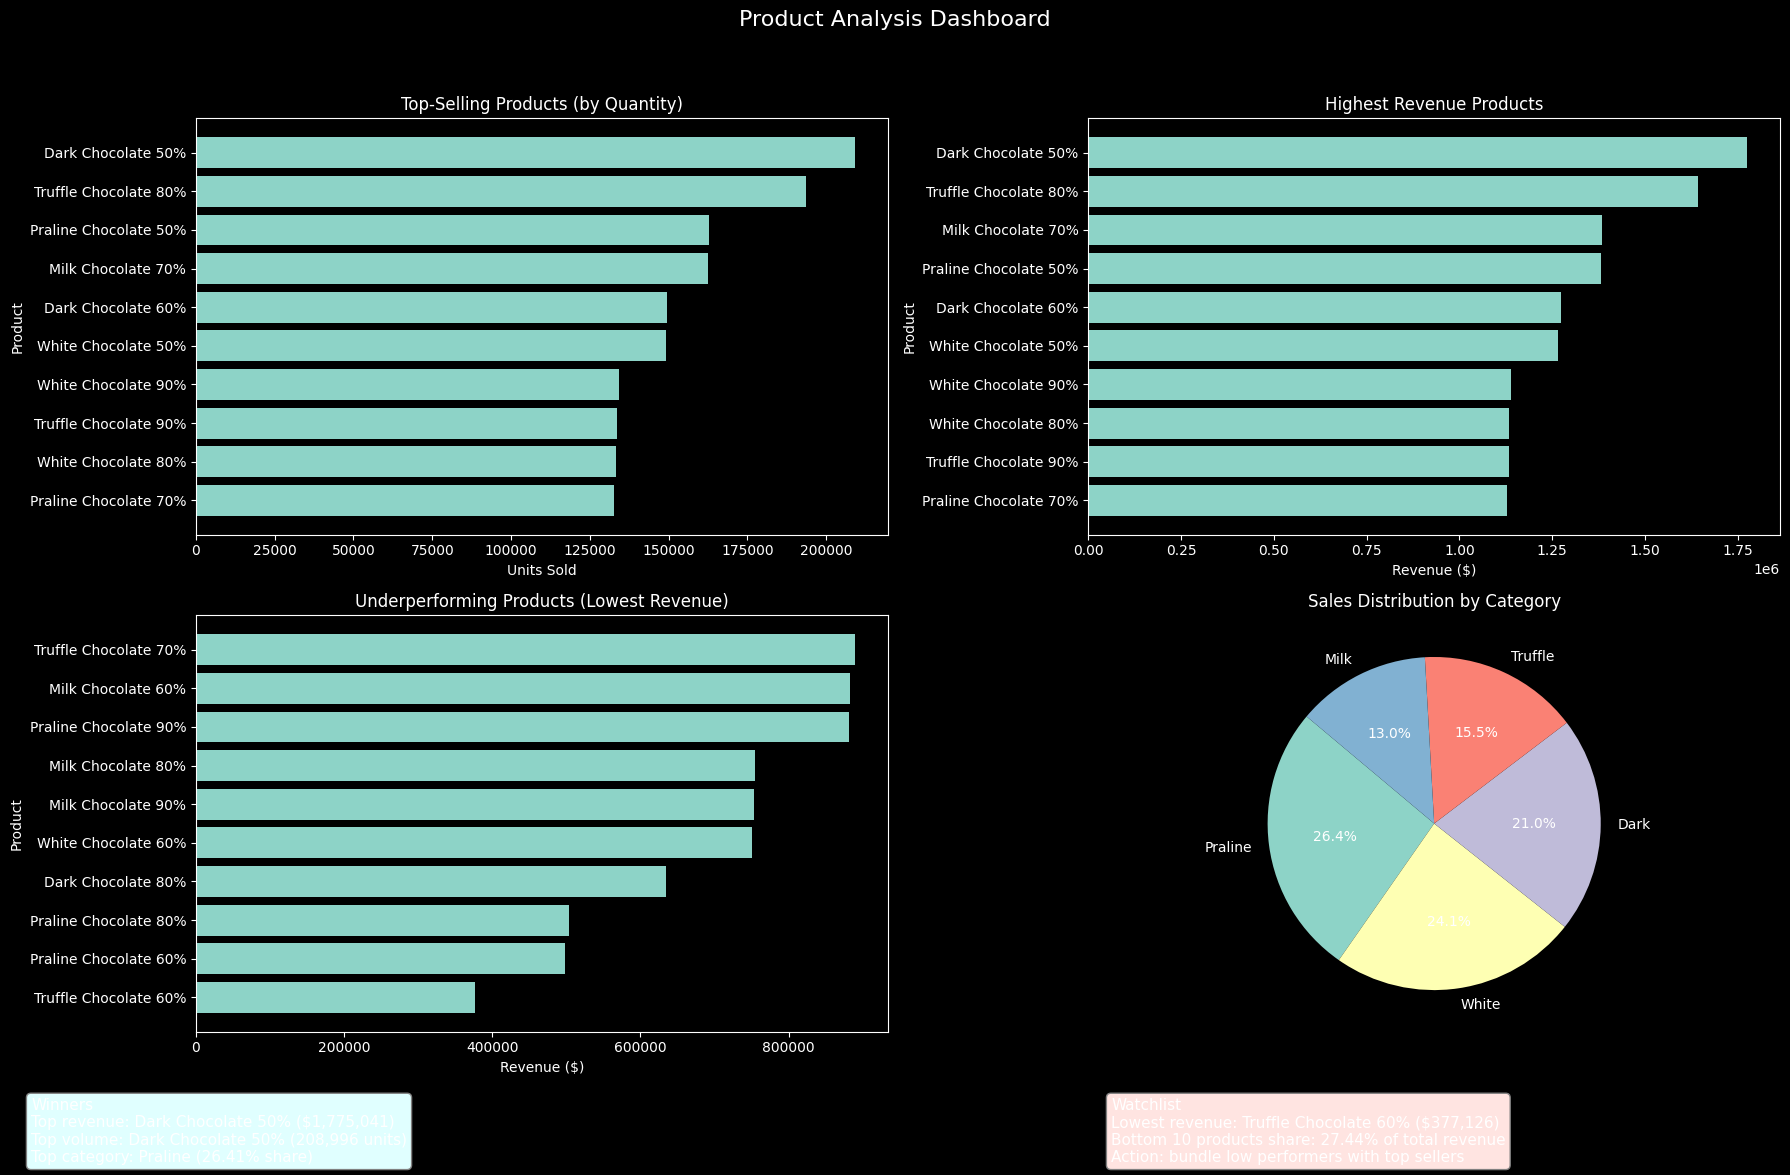

In [137]:
import matplotlib.pyplot as plt


required_cols = {'product_name', 'revenue', 'quantity', 'order_id', 'category'}

if 'analysis_df' not in globals():
    for name, obj in globals().items():
        if hasattr(obj, 'columns') and required_cols.issubset(set(obj.columns)):
            analysis_df = obj.copy()
            break

if 'analysis_df' not in globals():
    raise NameError(
        "analysis_df is not defined. Run the data preparation cell first, "
        "or set analysis_df to a DataFrame containing: "
        "product_name, revenue, quantity, order_id, category."
    )

# Product metrics
product_metrics = (
    analysis_df.groupby('product_name', as_index=False)
    .agg(Revenue=('revenue', 'sum'),
         Quantity=('quantity', 'sum'),
         Orders=('order_id', 'nunique'))
)

top_selling_qty = product_metrics.nlargest(10, 'Quantity').sort_values('Quantity', ascending=True)
top_revenue = product_metrics.nlargest(10, 'Revenue').sort_values('Revenue', ascending=True)
low_sales = product_metrics.nsmallest(10, 'Revenue').sort_values('Revenue', ascending=True)

category_dist = (
    analysis_df.groupby('category', as_index=False)
    .agg(Revenue=('revenue', 'sum'))
    .sort_values('Revenue', ascending=False)
)
category_dist['Share %'] = (category_dist['Revenue'] / category_dist['Revenue'].sum() * 100).round(2)

# Insight values
top_rev_product = top_revenue.iloc[-1]
top_qty_product = top_selling_qty.iloc[-1]
lowest_product = low_sales.iloc[0]
bottom10_rev_share = (low_sales['Revenue'].sum() / product_metrics['Revenue'].sum()) * 100

# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top-selling by quantity
axes[0, 0].barh(top_selling_qty['product_name'], top_selling_qty['Quantity'])
axes[0, 0].set_title('Top-Selling Products (by Quantity)')
axes[0, 0].set_xlabel('Units Sold')
axes[0, 0].set_ylabel('Product')

# Highest revenue products
axes[0, 1].barh(top_revenue['product_name'], top_revenue['Revenue'])
axes[0, 1].set_title('Highest Revenue Products')
axes[0, 1].set_xlabel('Revenue ($)')
axes[0, 1].set_ylabel('Product')

# Underperforming products
axes[1, 0].barh(low_sales['product_name'], low_sales['Revenue'])
axes[1, 0].set_title('Underperforming Products (Lowest Revenue)')
axes[1, 0].set_xlabel('Revenue ($)')
axes[1, 0].set_ylabel('Product')

# Category pie chart
axes[1, 1].pie(
    category_dist['Revenue'],
    labels=category_dist['category'],
    autopct='%1.1f%%',
    startangle=140
)
axes[1, 1].set_title('Sales Distribution by Category')

# Main title
fig.suptitle('Product Analysis Dashboard', fontsize=16)

# Insight boxes
insight_left = (
    f"Winners\n"
    f"Top revenue: {top_rev_product['product_name']} (${top_rev_product['Revenue']:,.0f})\n"
    f"Top volume: {top_qty_product['product_name']} ({int(top_qty_product['Quantity']):,} units)\n"
    f"Top category: {category_dist.iloc[0]['category']} ({category_dist.iloc[0]['Share %']:.2f}% share)"
)

insight_right = (
    f"Watchlist\n"
    f"Lowest revenue: {lowest_product['product_name']} (${lowest_product['Revenue']:,.0f})\n"
    f"Bottom 10 products share: {bottom10_rev_share:.2f}% of total revenue\n"
    f"Action: bundle low performers with top sellers"
)

fig.text(
    0.02, 0.02, insight_left,
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='lightcyan', edgecolor='gray')
)

fig.text(
    0.62, 0.02, insight_right,
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='mistyrose', edgecolor='gray')
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

In [138]:
# Store with the highest revenue?
store_label_col = 'store_name' if 'store_name' in analysis_df.columns else 'store_id'

top_store_df = (
    analysis_df.groupby(['store_id', store_label_col], as_index=False)['revenue']
    .sum()
    .sort_values('revenue', ascending=False)
)

top_store = top_store_df.iloc[0]
print(f"Store with the highest revenue: {top_store[store_label_col]} (ID: {top_store['store_id']})")
print(f"Revenue: ${top_store['revenue']:,.2f}")

display(top_store_df.head(10))

Store with the highest revenue: Chocolate Store 74 (ID: S074)
Revenue: $261,393.77


,store_id,store_name,revenue
73,S074,Chocolate Store 74,261393.77
32,S033,Chocolate Store 33,260672.37
49,S050,Chocolate Store 50,259526.62
84,S085,Chocolate Store 85,259512.15
97,S098,Chocolate Store 98,259055.13
26,S027,Chocolate Store 27,259006.23
21,S022,Chocolate Store 22,258914.68
29,S030,Chocolate Store 30,258231.17
12,S013,Chocolate Store 13,258185.98
89,S090,Chocolate Store 90,258135.85


In [139]:
# Which store has the lowest performance?
store_label_col = 'store_name' if 'store_name' in analysis_df.columns else 'store_id'

store_revenue = (
    analysis_df.groupby(['store_id', store_label_col], as_index=False)['revenue']
    .sum()
    .sort_values('revenue', ascending=True)
)

lowest_store = store_revenue.iloc[0]
print(f"Store with the lowest performance: {lowest_store[store_label_col]} (ID: {lowest_store['store_id']})")
print(f"Revenue: ${lowest_store['revenue']:,.2f}")

display(store_revenue.head(10))

Store with the lowest performance: Chocolate Store 4 (ID: S004)
Revenue: $247,858.64


,store_id,store_name,revenue
3,S004,Chocolate Store 4,247858.64
56,S057,Chocolate Store 57,248778.57
47,S048,Chocolate Store 48,249272.38
1,S002,Chocolate Store 2,249737.67
76,S077,Chocolate Store 77,250220.40
44,S045,Chocolate Store 45,250430.30
74,S075,Chocolate Store 75,251092.17
23,S024,Chocolate Store 24,251128.76
43,S044,Chocolate Store 44,251216.13
91,S092,Chocolate Store 92,251282.68


Sales Comparison Across Stores
Top store   : Chocolate Store 74 (S074) -> $261,393.77
Bottom store: Chocolate Store 4 (S004) -> $247,858.64
Revenue gap : $13,535.13


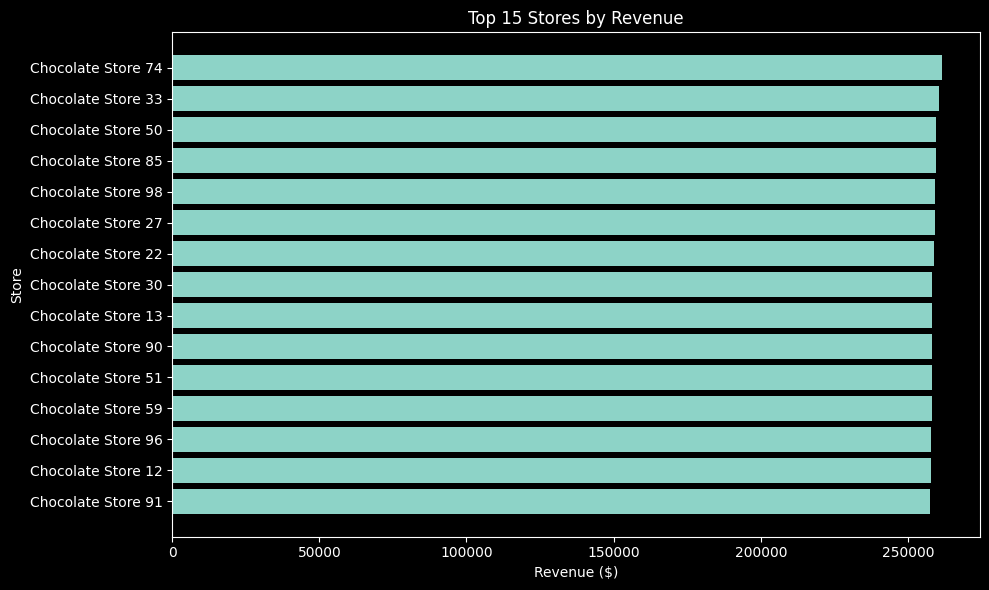

,store_id,store_name,Revenue,Orders,Quantity,Revenue Share %
73,S074,Chocolate Store 74,261393.77,10154,30761,1.03
32,S033,Chocolate Store 33,260672.37,10186,30671,1.02
49,S050,Chocolate Store 50,259526.62,10110,30490,1.02
84,S085,Chocolate Store 85,259512.15,10072,30366,1.02
97,S098,Chocolate Store 98,259055.13,10130,30655,1.02
26,S027,Chocolate Store 27,259006.23,10163,30427,1.02
21,S022,Chocolate Store 22,258914.68,10136,30288,1.02
29,S030,Chocolate Store 30,258231.17,10055,30373,1.01
12,S013,Chocolate Store 13,258185.98,10194,30499,1.01
89,S090,Chocolate Store 90,258135.85,10104,30192,1.01


In [140]:
import matplotlib.pyplot as plt

# Sales comparison across stores
store_sales_comparison = (
    analysis_df.groupby(['store_id', 'store_name'], as_index=False)
    .agg(
        Revenue=('revenue', 'sum'),
        Orders=('order_id', 'nunique'),
        Quantity=('quantity', 'sum')
    )
    .sort_values('Revenue', ascending=False)
)

# Revenue share %
store_sales_comparison['Revenue Share %'] = (
    store_sales_comparison['Revenue'] / store_sales_comparison['Revenue'].sum() * 100
).round(2)

# Insights
best_store = store_sales_comparison.iloc[0]
worst_store = store_sales_comparison.iloc[-1]
revenue_gap = best_store['Revenue'] - worst_store['Revenue']

print('Sales Comparison Across Stores')
print(f"Top store   : {best_store['store_name']} ({best_store['store_id']}) -> ${best_store['Revenue']:,.2f}")
print(f"Bottom store: {worst_store['store_name']} ({worst_store['store_id']}) -> ${worst_store['Revenue']:,.2f}")
print(f"Revenue gap : ${revenue_gap:,.2f}")

# Top 15 stores
top_stores = store_sales_comparison.head(15).sort_values('Revenue', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_stores['store_name'], top_stores['Revenue'])

# Labels
plt.xlabel('Revenue ($)')
plt.ylabel('Store')
plt.title('Top 15 Stores by Revenue')


plt.tight_layout()
plt.show()

display(store_sales_comparison.head(15))

In [141]:
# Which location (city/state) performs best?
# Build a location-enriched base using stores table columns.
base_df = analysis_df.merge(stores, on='store_id', how='left', suffixes=('', '_stores'))

location_cols = [
    c for c in base_df.columns
    if any(k in c.lower() for k in ['city', 'state', 'province', 'region', 'country', 'location'])
]

# Prefer city/state style comparison, then fallback to other geographic pairs.
priority_pairs = [
    ('city', 'state'),
    ('city', 'province'),
    ('city', 'region'),
    ('city', 'country'),
    ('location', 'state'),
    ('location', 'country'),
    ('region', 'country')
]

selected_pair = None
for left_key, right_key in priority_pairs:
    left_col = next((c for c in location_cols if left_key in c.lower()), None)
    right_col = next((c for c in location_cols if right_key in c.lower() and c != left_col), None)
    if left_col and right_col:
        selected_pair = (left_col, right_col)
        break

if selected_pair:
    loc_col_1, loc_col_2 = selected_pair
    location_performance = (
        base_df.groupby([loc_col_1, loc_col_2], as_index=False)
        .agg(
            Revenue=('revenue', 'sum'),
            Orders=('order_id', 'nunique'),
            Quantity=('quantity', 'sum')
        )
        .sort_values('Revenue', ascending=False)
    )

    top_location = location_performance.iloc[0]
    print('Best-performing location:')
    print(f"{top_location[loc_col_1]}, {top_location[loc_col_2]}")
    print(f"Revenue: ${top_location['Revenue']:,.2f}")
    print(f"(Using columns: {loc_col_1} + {loc_col_2})")
    display(location_performance.head(10))

else:
    single_loc_col = next((c for c in location_cols), None)
    if single_loc_col is None:
        raise ValueError('No location-like columns found in merged data.')

    location_performance = (
        base_df.groupby(single_loc_col, as_index=False)
        .agg(
            Revenue=('revenue', 'sum'),
            Orders=('order_id', 'nunique'),
            Quantity=('quantity', 'sum')
        )
        .sort_values('Revenue', ascending=False)
    )

    top_location = location_performance.iloc[0]
    print('Best-performing location:')
    print(f"{top_location[single_loc_col]}")
    print(f"Revenue: ${top_location['Revenue']:,.2f}")
    print(f"(Using column: {single_loc_col})")
    display(location_performance.head(10))

Best-performing location:
Toronto, Canada
Revenue: $1,524,861.29
(Using columns: city + country)


,city,country,Revenue,Orders,Quantity
36,Toronto,Canada,1524861.29,59880,179613
27,Paris,UK,1255058.46,49307,147929
35,Toronto,Australia,1027853.23,40286,121055
16,Melbourne,USA,1026666.26,40056,120223
34,Sydney,USA,1025942.94,40094,120545
37,Toronto,France,1025140.12,40165,120378
6,London,Canada,1015609.90,39997,119890
22,New York,USA,1014689.45,39810,119574
21,New York,UK,773096.50,30183,90759
7,London,France,768404.50,29931,89872


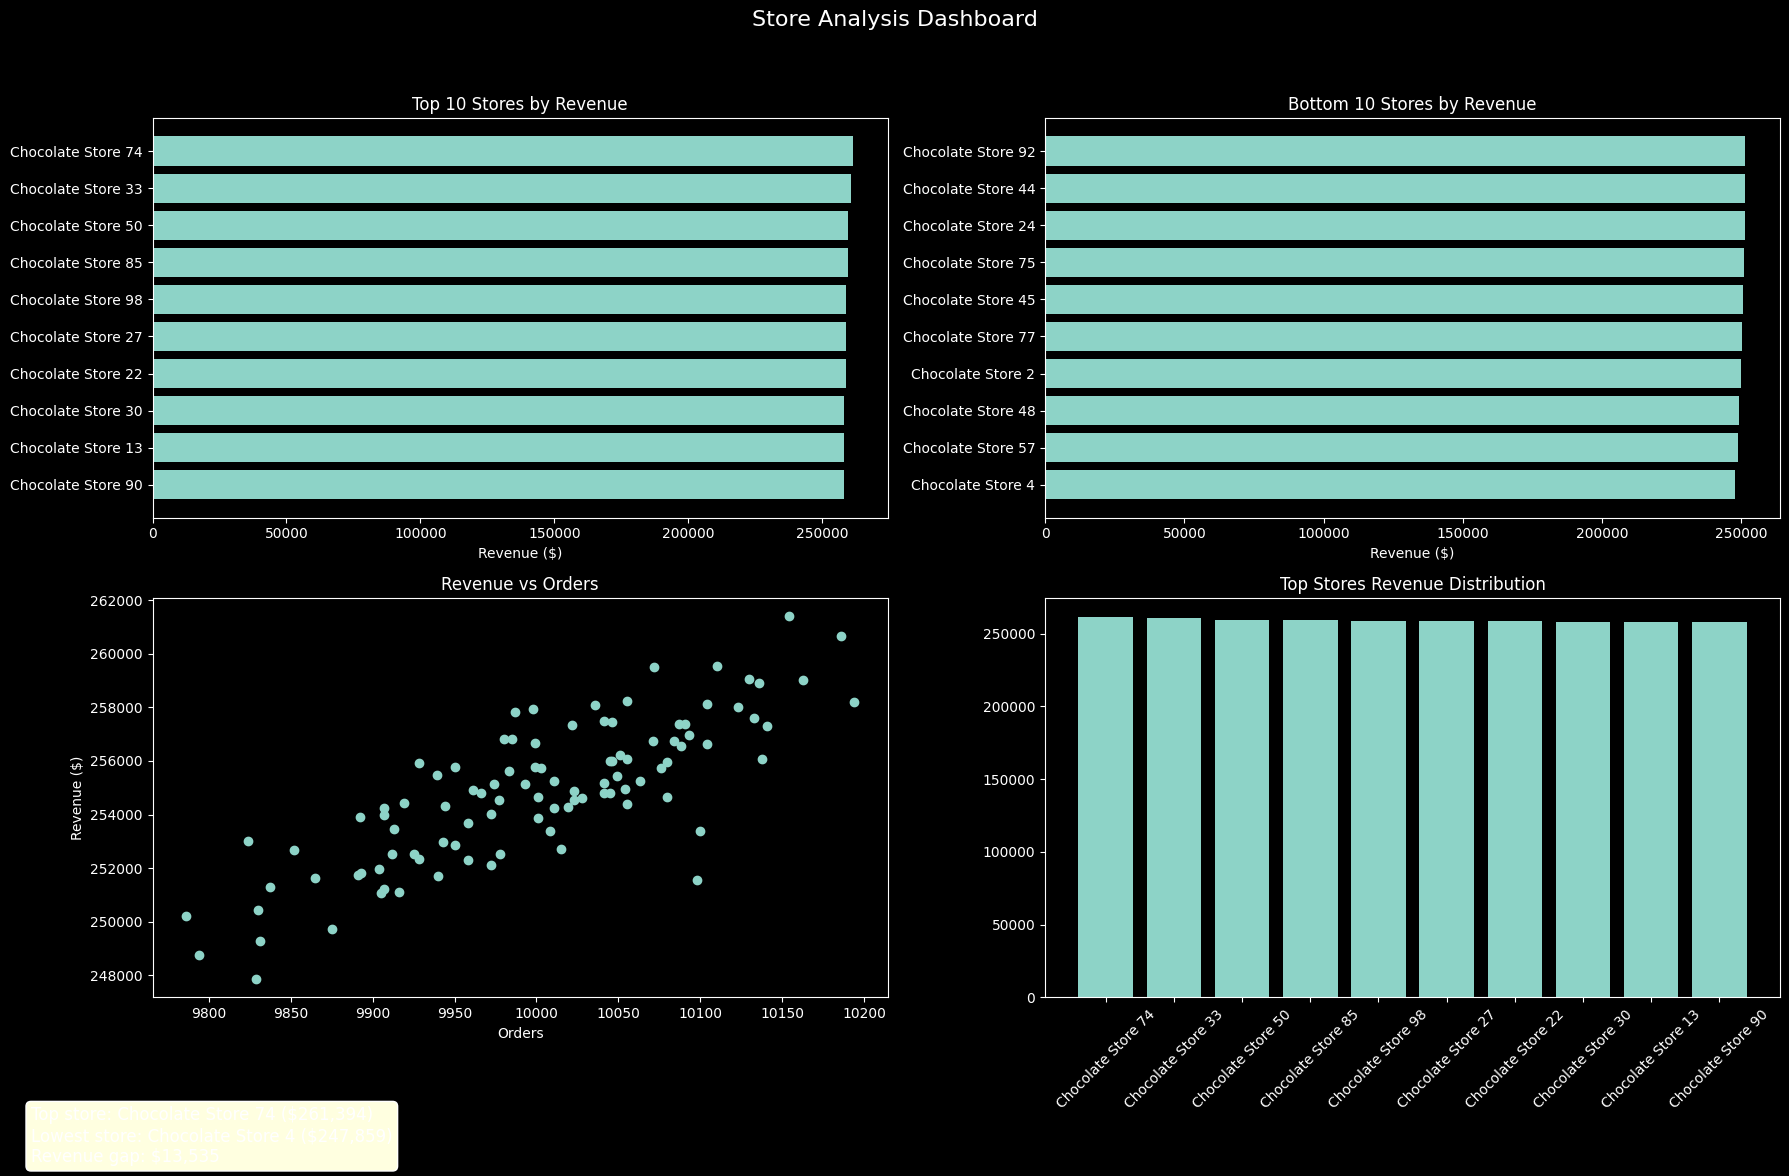

Store Analysis Summary
Top store: Chocolate Store 74 -> $261,393.77
Lowest store: Chocolate Store 4 -> $247,858.64


In [142]:
import matplotlib.pyplot as plt

store_label_col = 'store_name' if 'store_name' in analysis_df.columns else 'store_id'

store_perf = (
    analysis_df.groupby(['store_id', store_label_col], as_index=False)
    .agg(
        Revenue=('revenue', 'sum'),
        Orders=('order_id', 'nunique'),
        Quantity=('quantity', 'sum')
    )
).sort_values('Revenue', ascending=False)

best_store = store_perf.iloc[0]
worst_store = store_perf.iloc[-1]
revenue_gap = best_store['Revenue'] - worst_store['Revenue']

# Top & Bottom stores
top10 = store_perf.head(10).sort_values('Revenue', ascending=True)
bottom10 = store_perf.tail(10).sort_values('Revenue', ascending=True)

# Create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 🔹 Top 10 Stores
axes[0, 0].barh(top10[store_label_col], top10['Revenue'])
axes[0, 0].set_title('Top 10 Stores by Revenue')
axes[0, 0].set_xlabel('Revenue ($)')

# 🔹 Bottom 10 Stores
axes[0, 1].barh(bottom10[store_label_col], bottom10['Revenue'])
axes[0, 1].set_title('Bottom 10 Stores by Revenue')
axes[0, 1].set_xlabel('Revenue ($)')

# 🔹 Scatter: Revenue vs Orders
axes[1, 0].scatter(store_perf['Orders'], store_perf['Revenue'])
axes[1, 0].set_title('Revenue vs Orders')
axes[1, 0].set_xlabel('Orders')
axes[1, 0].set_ylabel('Revenue ($)')

# 🔹 Revenue distribution (simple bar instead of location logic)
axes[1, 1].bar(store_perf[store_label_col].head(10), store_perf['Revenue'].head(10))
axes[1, 1].set_title('Top Stores Revenue Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

# Main title
fig.suptitle('Store Analysis Dashboard', fontsize=16)

# Insights (text)
insight = (
    f"Top store: {best_store[store_label_col]} (${best_store['Revenue']:,.0f})\n"
    f"Lowest store: {worst_store[store_label_col]} (${worst_store['Revenue']:,.0f})\n"
    f"Revenue gap: ${revenue_gap:,.0f}"
)

fig.text(0.02, 0.02, insight, fontsize=12,
         bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print('Store Analysis Summary')
print(f"Top store: {best_store[store_label_col]} -> ${best_store['Revenue']:,.2f}")
print(f"Lowest store: {worst_store[store_label_col]} -> ${worst_store['Revenue']:,.2f}")

In [143]:
# Average customer age?
average_customer_age = customers['age'].mean()
print(f"Average customer age: {average_customer_age:.2f} years")

Average customer age: 44.03 years


In [144]:
# Total customers are there?
total_customers = customers['customer_id'].nunique()
print(f"Total customers: {total_customers}")

Total customers: 50000


In [145]:
# Sales by gender?
sales_by_gender = (
	analysis_df.groupby('gender', as_index=False)['revenue']
	.sum()
	.rename(columns={'revenue': 'sales'})
)
print(sales_by_gender)

   gender        sales
0  Female  12630103.60
1    Male  12856025.26


Revenue Forecast (Baseline Linear Trend)
Forecast total revenue - next 3 months: $3,202,114.75
Forecast total revenue - next 6 months: $6,407,862.54


,Month,Forecast Revenue
0,2025-01-01,1.066968e+06
1,2025-02-01,1.067372e+06
2,2025-03-01,1.067775e+06
3,2025-04-01,1.068179e+06
4,2025-05-01,1.068583e+06
5,2025-06-01,1.068986e+06


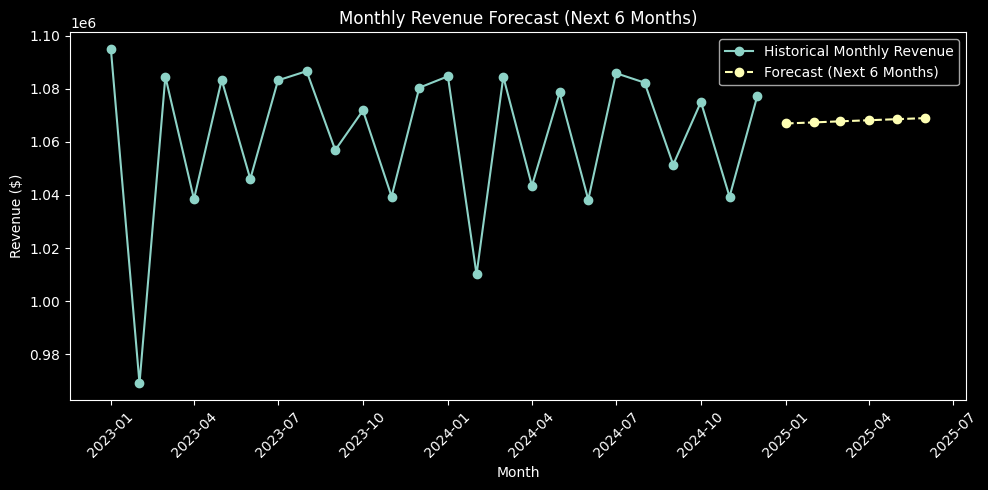

In [146]:
import numpy as np
import matplotlib.pyplot as plt

# Build monthly revenue time series
monthly_revenue_ts = (
    analysis_df.groupby(pd.Grouper(key='order_date', freq='MS'))['revenue']
    .sum()
    .sort_index()
)

if len(monthly_revenue_ts) < 6:
    raise ValueError('Need at least 6 months of data for a basic forecast.')

# Linear trend forecast
x = np.arange(len(monthly_revenue_ts))
y = monthly_revenue_ts.values
slope, intercept = np.polyfit(x, y, 1)

future_horizon = 6
future_x = np.arange(len(monthly_revenue_ts), len(monthly_revenue_ts) + future_horizon)
future_dates = pd.date_range(
    monthly_revenue_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=future_horizon,
    freq='MS'
)
future_forecast = intercept + slope * future_x
future_forecast = np.maximum(future_forecast, 0)

forecast_df = pd.DataFrame({
    'Month': future_dates,
    'Forecast Revenue': future_forecast
})

next_3m_total = forecast_df['Forecast Revenue'].head(3).sum()
next_6m_total = forecast_df['Forecast Revenue'].sum()

print('Revenue Forecast (Baseline Linear Trend)')
print(f"Forecast total revenue - next 3 months: ${next_3m_total:,.2f}")
print(f"Forecast total revenue - next 6 months: ${next_6m_total:,.2f}")

display(forecast_df)

# Plot history + forecast
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_revenue_ts.index,
    monthly_revenue_ts.values,
    marker='o',
    label='Historical Monthly Revenue'
)
plt.plot(
    forecast_df['Month'],
    forecast_df['Forecast Revenue'],
    marker='o',
    linestyle='--',
    label='Forecast (Next 6 Months)'
)

plt.title('Monthly Revenue Forecast (Next 6 Months)')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Top stores by future revenue forecast
Highest forecast store (next 6 months): Chocolate Store 96 (S096)
Forecast next 3 months: $34,027.27
Forecast next 6 months: $68,451.38


,store_id,store_name,Forecast Next 3 Months,Forecast Next 6 Months,Latest Monthly Revenue
95,S096,Chocolate Store 96,34027.271043,68451.380652,11327.09
71,S072,Chocolate Store 72,33934.965139,68293.873087,12033.13
73,S074,Chocolate Store 74,33389.280622,66937.463326,11265.89
70,S071,Chocolate Store 71,33190.306157,66646.195348,11264.42
64,S065,Chocolate Store 65,33183.696061,66589.967913,11187.40
90,S091,Chocolate Store 91,33158.704300,66530.196500,11775.68
30,S031,Chocolate Store 31,33137.867230,66512.787457,10986.50
62,S063,Chocolate Store 63,33070.579957,66416.639348,10458.60
17,S018,Chocolate Store 18,33007.650070,66335.901543,10814.58
19,S020,Chocolate Store 20,33019.892478,66299.857174,11749.72


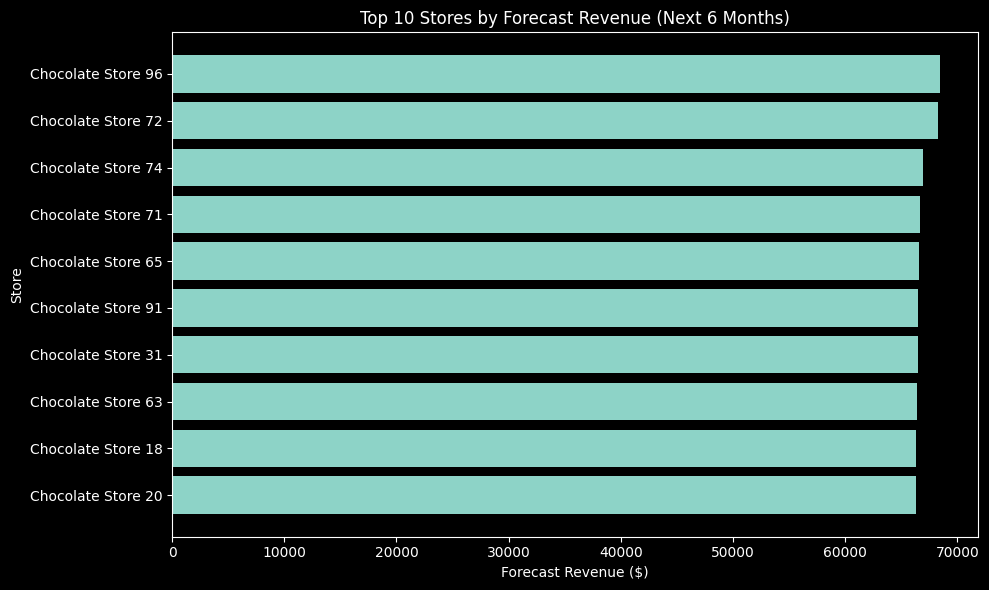

In [147]:
# Which stores will generate the highest future revenue?
import numpy as np
import matplotlib.pyplot as plt

store_label_col = 'store_name' if 'store_name' in analysis_df.columns else 'store_id'

store_monthly_revenue = (
    analysis_df.groupby(['store_id', store_label_col, pd.Grouper(key='order_date', freq='MS')])['revenue']
    .sum()
    .reset_index()
    .rename(columns={'order_date': 'Month', 'revenue': 'Revenue'})
)

all_months = pd.date_range(
    store_monthly_revenue['Month'].min(),
    store_monthly_revenue['Month'].max(),
    freq='MS'
)

forecast_rows = []

for (store_id, store_name), group in store_monthly_revenue.groupby(['store_id', store_label_col]):
    monthly_series = (
        group.set_index('Month')['Revenue']
        .reindex(all_months, fill_value=0.0)
    )

    if len(monthly_series) < 6:
        continue

    x = np.arange(len(monthly_series))
    y = monthly_series.values
    slope, intercept = np.polyfit(x, y, 1)

    future_horizon = 6
    future_x = np.arange(len(monthly_series), len(monthly_series) + future_horizon)
    future_forecast = np.maximum(intercept + slope * future_x, 0)

    forecast_rows.append({
        'store_id': store_id,
        store_label_col: store_name,
        'Forecast Next 3 Months': future_forecast[:3].sum(),
        'Forecast Next 6 Months': future_forecast.sum(),
        'Latest Monthly Revenue': monthly_series.iloc[-1]
    })

store_forecast_df = pd.DataFrame(forecast_rows).sort_values('Forecast Next 6 Months', ascending=False)
top_forecast_store = store_forecast_df.iloc[0]

print('Top stores by future revenue forecast')
print(f"Highest forecast store (next 6 months): {top_forecast_store[store_label_col]} ({top_forecast_store['store_id']})")
print(f"Forecast next 3 months: ${top_forecast_store['Forecast Next 3 Months']:,.2f}")
print(f"Forecast next 6 months: ${top_forecast_store['Forecast Next 6 Months']:,.2f}")

display(store_forecast_df.head(10))

# Plot top 10
plot_df = store_forecast_df.head(10).sort_values('Forecast Next 6 Months', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df[store_label_col], plot_df['Forecast Next 6 Months'])

plt.xlabel('Forecast Revenue ($)')
plt.ylabel('Store')
plt.title('Top 10 Stores by Forecast Revenue (Next 6 Months)')
plt.tight_layout()
plt.show()

In [148]:
# Expected daily/weekly sales trend forecast
import numpy as np


# -----------------------------
# 1) Daily expected pattern
# -----------------------------
daily_profile = (
    analysis_df.groupby('day_of_week', as_index=False)['revenue']
    .mean()
    .rename(columns={'revenue': 'Avg Daily Revenue'})
    .sort_values('day_of_week')
)

weekday_map = {
    0: 'Sunday',
    1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday',
    5: 'Friday', 6: 'Saturday', 7: 'Sunday'
}
daily_profile['Weekday'] = daily_profile['day_of_week'].map(weekday_map)
daily_profile['Weekday'] = daily_profile['Weekday'].fillna('Unknown')

# -----------------------------
# 2) Weekly trend + forecast
# -----------------------------
weekly_ts = (
    analysis_df.groupby(pd.Grouper(key='order_date', freq='W-MON'))['revenue']
    .sum()
    .sort_index()
)

if len(weekly_ts) < 8:
    raise ValueError('Need at least 8 weeks of data for weekly trend forecast.')

x = np.arange(len(weekly_ts))
y = weekly_ts.values
slope, intercept = np.polyfit(x, y, 1)

future_weeks = 8
future_x = np.arange(len(weekly_ts), len(weekly_ts) + future_weeks)
future_dates = pd.date_range(weekly_ts.index[-1] + pd.Timedelta(days=7), periods=future_weeks, freq='W-MON')
future_forecast = np.maximum(intercept + slope * future_x, 0)

weekly_forecast_df = pd.DataFrame({
    'Week Start': future_dates,
    'Forecast Weekly Revenue': future_forecast
})

trend_direction = 'upward' if slope > 0 else 'downward' if slope < 0 else 'flat'

print('Expected Sales Trend')
print(f"Daily pattern peak: {daily_profile.loc[daily_profile['Avg Daily Revenue'].idxmax(), 'Weekday']}")
print(f"Daily pattern low : {daily_profile.loc[daily_profile['Avg Daily Revenue'].idxmin(), 'Weekday']}")
print(f"Weekly trend direction (next 8 weeks): {trend_direction}")
print(f"Forecast next 4 weeks total: ${weekly_forecast_df['Forecast Weekly Revenue'].head(4).sum():,.2f}")
print(f"Forecast next 8 weeks total: ${weekly_forecast_df['Forecast Weekly Revenue'].sum():,.2f}")

display(daily_profile[['Weekday', 'Avg Daily Revenue']])
display(weekly_forecast_df)



Expected Sales Trend
Daily pattern peak: Monday
Daily pattern low : Saturday
Weekly trend direction (next 8 weeks): downward
Forecast next 4 weeks total: $955,224.13
Forecast next 8 weeks total: $1,909,974.33


,Weekday,Avg Daily Revenue
0,Sunday,25.498647
1,Monday,25.514439
2,Tuesday,25.513171
3,Wednesday,25.464160
4,Thursday,25.510859
5,Friday,25.460640
6,Saturday,25.441131


,Week Start,Forecast Weekly Revenue
0,2025-01-13,238850.463736
1,2025-01-20,238820.842910
2,2025-01-27,238791.222084
3,2025-02-03,238761.601258
4,2025-02-10,238731.980432
5,2025-02-17,238702.359606
6,2025-02-24,238672.738780
7,2025-03-03,238643.117954


=== Predicted Seasonal Spikes ===
Spike detection basis: adaptive threshold (top quartile, >= 1.021)
Spike months: January, March, July

Upcoming spike periods (next 12 months):
- Jan 2025: $1,097,375.68
- Mar 2025: $1,092,045.45
- Jul 2025: $1,091,995.47

Monthly seasonality index (1.00 = average month):
month_name  season_index
   January      1.028499
     March      1.022730
      July      1.021139
    August      1.020710
       May      1.018586
  December      1.013828
   October      1.009544
 September      0.991773
      June      0.981562
     April      0.981173
  November      0.977103
  February      0.933354


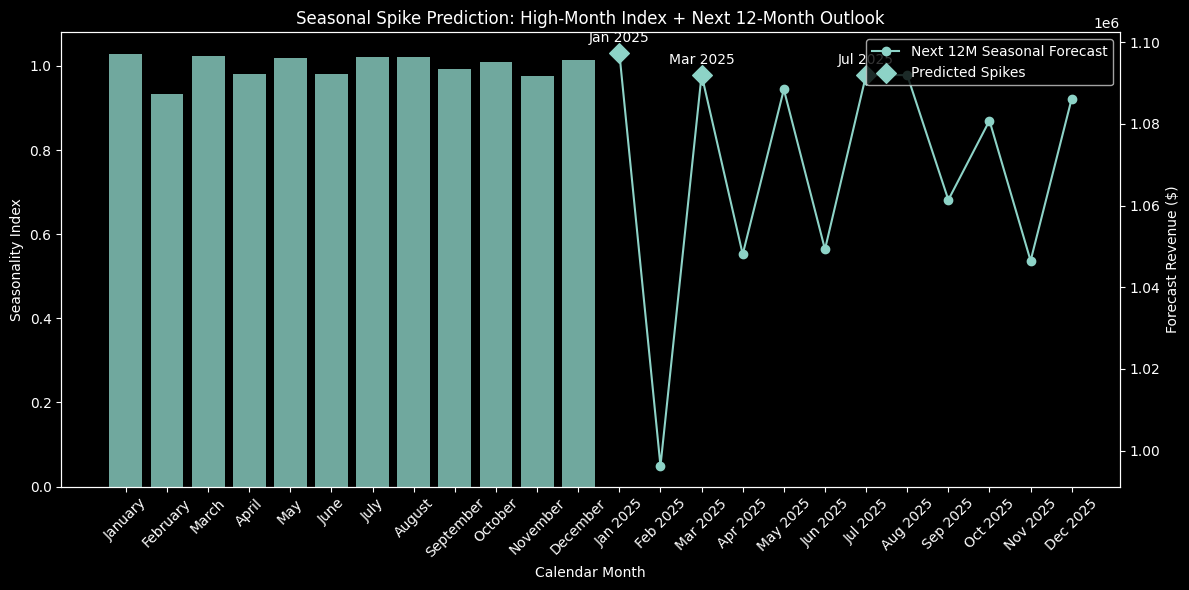

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')

# 1) Prepare monthly revenue time series
seasonal_ts = monthly_revenue_ts.copy().sort_index().asfreq('MS')
seasonal_ts = seasonal_ts.fillna(seasonal_ts.median())

# 2) Estimate trend and seasonal index
x_hist = np.arange(len(seasonal_ts))
trend_coef = np.polyfit(x_hist, seasonal_ts.values, 1)
trend_hist = np.polyval(trend_coef, x_hist)
trend_hist = np.maximum(trend_hist, 1e-9)

hist_df = pd.DataFrame({
    'date': seasonal_ts.index,
    'revenue': seasonal_ts.values,
    'trend': trend_hist
})
hist_df['month_num'] = hist_df['date'].dt.month
hist_df['season_ratio'] = hist_df['revenue'] / hist_df['trend']

month_seasonality = hist_df.groupby('month_num', as_index=False)['season_ratio'].mean()
month_seasonality['season_index'] = month_seasonality['season_ratio'] / month_seasonality['season_ratio'].mean()
month_seasonality['month_name'] = pd.to_datetime(
    month_seasonality['month_num'], format='%m'
).dt.strftime('%B')

# 3) Forecast next 12 months
future_months = 12
future_dates_seasonal = pd.date_range(
    seasonal_ts.index.max() + pd.offsets.MonthBegin(1),
    periods=future_months,
    freq='MS'
)
x_future = np.arange(len(seasonal_ts), len(seasonal_ts) + future_months)
trend_future = np.polyval(trend_coef, x_future)
trend_future = np.maximum(trend_future, 0)

future_df = pd.DataFrame({'date': future_dates_seasonal, 'trend_base': trend_future})
future_df['month_num'] = future_df['date'].dt.month
future_df = future_df.merge(
    month_seasonality[['month_num', 'season_index']],
    on='month_num',
    how='left'
)
future_df['seasonal_forecast'] = future_df['trend_base'] * future_df['season_index']

# 4) Flag spikes
strong_threshold = 1.10
adaptive_threshold = max(1.00, month_seasonality['season_index'].quantile(0.75))

strong_spikes = month_seasonality[month_seasonality['season_index'] >= strong_threshold].copy()
if not strong_spikes.empty:
    spike_months = strong_spikes.copy()
    spike_label = f'strong threshold (>= {strong_threshold:.2f})'
else:
    spike_months = month_seasonality[month_seasonality['season_index'] >= adaptive_threshold].copy()
    spike_label = f'adaptive threshold (top quartile, >= {adaptive_threshold:.3f})'

spike_months = spike_months.sort_values('season_index', ascending=False)
future_df['is_spike'] = future_df['month_num'].isin(spike_months['month_num'])
next_spikes = future_df[future_df['is_spike']].copy()

# 5) Print summary
print('=== Predicted Seasonal Spikes ===')
print('Spike detection basis:', spike_label)
print('Spike months:', ', '.join(spike_months['month_name'].tolist()))

print('\nUpcoming spike periods (next 12 months):')
for _, row in next_spikes.iterrows():
    print(f"- {row['date'].strftime('%b %Y')}: ${row['seasonal_forecast']:,.2f}")

print('\nMonthly seasonality index (1.00 = average month):')
print(
    month_seasonality[['month_name', 'season_index']]
    .sort_values('season_index', ascending=False)
    .to_string(index=False)
)

# 6) Matplotlib chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: seasonality index bar chart
seasonality_plot = month_seasonality.sort_values('month_num')
ax1.bar(
    seasonality_plot['month_name'],
    seasonality_plot['season_index'],
    alpha=0.8
)
ax1.set_xlabel('Calendar Month')
ax1.set_ylabel('Seasonality Index')
ax1.set_title('Seasonal Spike Prediction: High-Month Index + Next 12-Month Outlook')
plt.xticks(rotation=45)

# Right axis: forecast line
ax2 = ax1.twinx()
ax2.plot(
    future_df['date'].dt.strftime('%b %Y'),
    future_df['seasonal_forecast'],
    marker='o',
    linestyle='-',
    label='Next 12M Seasonal Forecast'
)

# Highlight spikes
ax2.scatter(
    next_spikes['date'].dt.strftime('%b %Y'),
    next_spikes['seasonal_forecast'],
    s=100,
    marker='D',
    label='Predicted Spikes'
)

ax2.set_ylabel('Forecast Revenue ($)')

# Add labels for spikes
for _, row in next_spikes.iterrows():
    ax2.annotate(
        row['date'].strftime('%b %Y'),
        (row['date'].strftime('%b %Y'), row['seasonal_forecast']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [150]:
# Create customer summary
customer_summary = (
    analysis_df.groupby('customer_id', as_index=False)
    .agg(
        Total_Revenue=('revenue', 'sum'),
        Total_Orders=('order_id', 'nunique'),
        Total_Quantity=('quantity', 'sum')
    )
)

# Simple scoring (you can improve later)
customer_summary['high_value_likelihood'] = (
    customer_summary['Total_Revenue'] * 0.5 +
    customer_summary['Total_Orders'] * 0.3 +
    customer_summary['Total_Quantity'] * 0.2
)

# Get top customers
likely_upgrades = customer_summary.sort_values(
    'high_value_likelihood',
    ascending=False
)

In [151]:
customer_col = 'customer_id'
name_col = None  # or 'customer_name' if exists

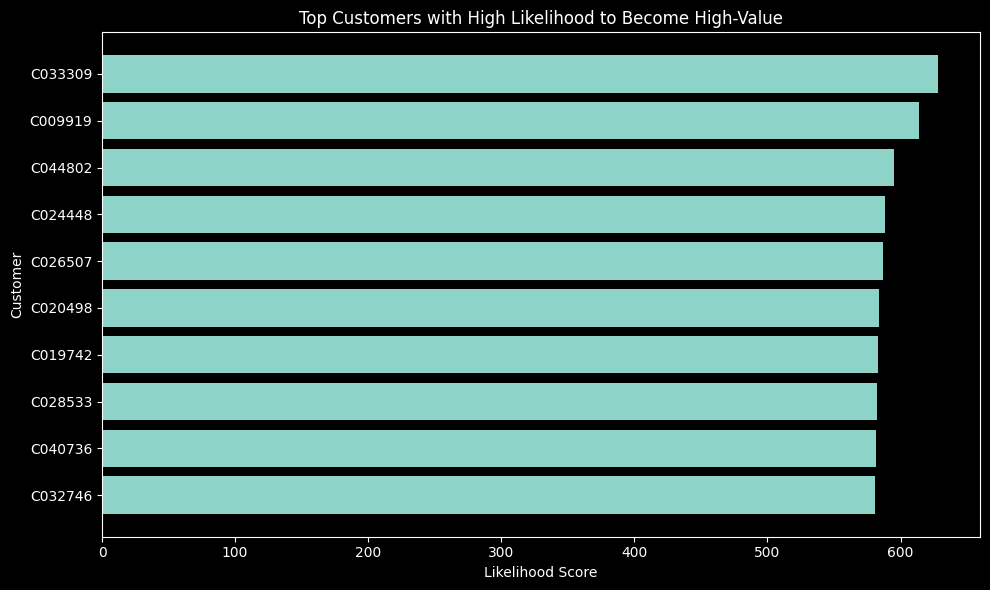

In [152]:
# Visualize top 10 likely upgrade customers
plot_top = likely_upgrades.head(10).copy()
plot_top['label'] = plot_top[customer_col].astype(str)

if name_col is not None:
    plot_top['label'] = (
        plot_top[name_col].fillna(plot_top['label']).astype(str)
        + ' (' + plot_top[customer_col].astype(str) + ')'
    )

plot_top = plot_top.sort_values('high_value_likelihood', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_top['label'], plot_top['high_value_likelihood'])

plt.xlabel('Likelihood Score')
plt.ylabel('Customer')
plt.title('Top Customers with High Likelihood to Become High-Value')
plt.tight_layout()
plt.show()

In [153]:
# Why customer C043343 has a high likelihood score
cid = 'C043343'
row = customer_scores.loc[customer_scores[customer_col] == cid].copy()

if row.empty:
    print(f'Customer {cid} not found in customer_scores.')
else:
    r = row.iloc[0]

    weighted_recency = 0.35 * r['recency_score']
    weighted_frequency = 0.25 * r['frequency_score']
    weighted_monetary = 0.25 * r['monetary_score']
    weighted_momentum = 0.15 * r['momentum_score']

    print(f'Customer: {cid}')
    print(f"Current high-value threshold (top 20% total revenue): ${hv_cutoff:,.2f}")
    print(f"Customer total revenue: ${r['total_revenue']:,.2f}")
    print(f"Already high-value now?: {bool(r['is_current_high_value'])}")

    print('\nRaw behavior signals:')
    print(f"- Orders: {int(r['order_count'])}")
    print(f"- Avg order value: ${r['avg_order_value']:,.2f}")
    print(f"- Revenue last 90 days: ${r['revenue_last_90']:,.2f}")
    print(f"- Momentum (last 90 - previous 90): ${r['momentum']:,.2f}")
    print(f"- Recency: {int(r['recency_days'])} days since last purchase")

    print('\nNormalized score components (0-1):')
    print(f"- Recency score  : {r['recency_score']:.3f} | weighted: {weighted_recency:.3f}")
    print(f"- Frequency score: {r['frequency_score']:.3f} | weighted: {weighted_frequency:.3f}")
    print(f"- Monetary score : {r['monetary_score']:.3f} | weighted: {weighted_monetary:.3f}")
    print(f"- Momentum score : {r['momentum_score']:.3f} | weighted: {weighted_momentum:.3f}")

    total = weighted_recency + weighted_frequency + weighted_monetary + weighted_momentum
    print(f"\nTotal high-value likelihood score: {total:.6f}")

    print('\nInterpretation:')
    print('- The customer is very recent (2 days), which strongly boosts score via recency weight 35%.')
    print('- Revenue momentum is strongly positive, indicating accelerating spend behavior.')
    print('- Order frequency and avg order value are both healthy, so this customer is near the high-value cutoff and likely to cross it soon.')

KeyError: 'recency_score'

In [ ]:
# Create customer_scores from analysis_df
customer_scores = (
    analysis_df.groupby('customer_id', as_index=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        order_count=('order_id', 'nunique'),
        total_quantity=('quantity', 'sum'),
        last_order_date=('order_date', 'max')
    )
)

# Snapshot date (today or max date)
snapshot_date = analysis_df['order_date'].max()

# Recency (days since last purchase)
customer_scores['recency_days'] = (
    snapshot_date - customer_scores['last_order_date']
).dt.days

# Recent revenue (last 90 days)
recent_data = analysis_df[
    analysis_df['order_date'] >= snapshot_date - pd.Timedelta(days=90)
]

recent_revenue = (
    recent_data.groupby('customer_id')['revenue']
    .sum()
    .reset_index(name='revenue_last_90')
)

customer_scores = customer_scores.merge(
    recent_revenue,
    on='customer_id',
    how='left'
).fillna({'revenue_last_90': 0})

# Momentum (simple: recent vs total)
customer_scores['momentum'] = (
    customer_scores['revenue_last_90'] - (customer_scores['total_revenue'] / 2)
)

In [ ]:
customer_col = 'customer_id'

In [ ]:
# 3) High + Critical only
high_critical_df = churn_df[churn_df['churn_tier'].isin(['Critical', 'High'])].copy()
high_critical_df['label'] = high_critical_df[customer_col].astype(str)

high_critical_top = high_critical_df.head(15).sort_values('churn_risk_score', ascending=True)

hc_colors = [tier_colors[t] for t in high_critical_top['churn_tier']]

axes[2].barh(high_critical_top['label'], high_critical_top['churn_risk_score'], color=hc_colors)
axes[2].set_title('High & Critical Risk Customers', fontsize=13, weight='bold')
axes[2].set_xlabel('Churn Risk Score')
axes[2].set_ylabel('Customer')
axes[2].grid(axis='x', linestyle='--', alpha=0.4)
axes[2].set_xlim(0, max(high_critical_top['churn_risk_score']) * 1.15 if len(high_critical_top) > 0 else 1)

for i, v in enumerate(high_critical_top['churn_risk_score']):
    axes[2].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)

=== Future Purchase Frequency Forecast (Next 90 Days) ===
Snapshot date    : 2024-12-31
Forecast horizon : 90 days
Total customers  : 50,000
Active customers : 42,631
Inactive/Churned : 7,369

Buyer segment distribution:
              Segment  Customers
High Freq (6+ orders)          0
    Medium Freq (3-5)      10059
       Low Freq (1-2)      32572
             Inactive       7369

Overall avg predicted orders (active only): 2.55

Top 15 customers by predicted purchase frequency (next 90 days):
customer_id  predicted_orders_90d  avg_gap_days  days_until_next_purchase       predicted_next_purchase  order_count  total_revenue     buyer_segment
    C033309                   5.1     17.657895                  5.657895 2025-01-05 15:47:22.105263157           39        1183.16 Medium Freq (3-5)
    C044952                   5.1     17.525000                 16.050000 2025-01-16 01:12:00.000000000           41         811.95 Medium Freq (3-5)
    C003898                   5.1     17.774194 

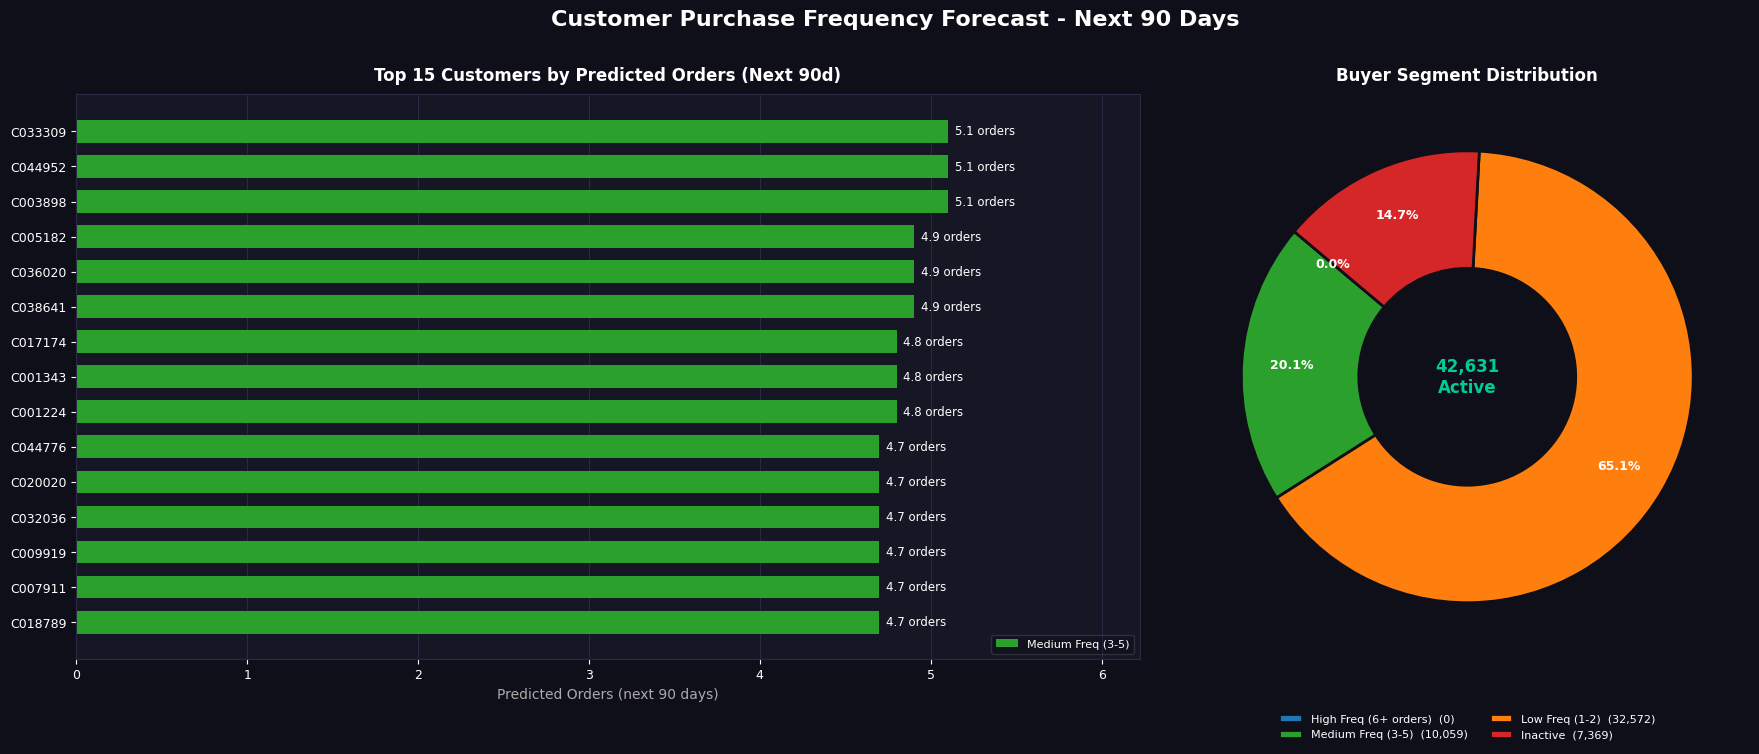

In [ ]:
# Predict future purchase frequency per customer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

FORECAST_DAYS = 90   # horizon for the prediction

# ── 1. Per-customer order history ─────────────────────────────────────────────
order_dates = (
    sales[["customer_id", "order_date", "order_id"]]
    .drop_duplicates(subset=["customer_id", "order_id"])
    .sort_values(["customer_id", "order_date"])
)

def avg_gap(dates):
    dates = dates.sort_values()
    if len(dates) < 2:
        return np.nan
    return dates.diff().dt.days.dropna().mean()

gap_df = (
    order_dates.groupby("customer_id")["order_date"]
    .apply(avg_gap)
    .rename("avg_gap_days")
    .reset_index()
)

# ── 2. Build customer-level frame ─────────────────────────────────────────────
snapshot_date = sales["order_date"].max()

cust_stats = (
    sales.groupby("customer_id")
    .agg(
        order_count=("order_id", "nunique"),
        last_purchase=("order_date", "max"),
        total_revenue=("revenue", "sum"),
    )
    .reset_index()
)
cust_stats["recency_days"] = (snapshot_date - cust_stats["last_purchase"]).dt.days

freq_df = cust_stats.merge(gap_df, on="customer_id", how="left")

# ── 3. Predicted orders in next FORECAST_DAYS days ────────────────────────────
data_window_days = (sales["order_date"].max() - sales["order_date"].min()).days
single_order_gap = data_window_days / 2

freq_df["gap_used"] = freq_df["avg_gap_days"].fillna(single_order_gap).clip(lower=1)

freq_df["expected_next_purchase_day"] = freq_df["recency_days"] % freq_df["gap_used"]
freq_df["days_until_next_purchase"] = (
    freq_df["gap_used"] - freq_df["expected_next_purchase_day"]
).clip(lower=0)

# Active: last purchase within 2x avg gap
freq_df["is_active"] = freq_df["recency_days"] <= (2 * freq_df["gap_used"])

freq_df["predicted_orders_90d"] = np.where(
    freq_df["is_active"],
    (FORECAST_DAYS / freq_df["gap_used"]).round(1),
    0.0,
)

freq_df["predicted_next_purchase"] = snapshot_date + pd.to_timedelta(
    freq_df["days_until_next_purchase"], unit="D"
)
freq_df.loc[~freq_df["is_active"], "predicted_next_purchase"] = pd.NaT

# ── 4. Segment buyers ─────────────────────────────────────────────────────────
def buyer_segment(row):
    if not row["is_active"]:
        return "Inactive"
    p = row["predicted_orders_90d"]
    if p >= 6:
        return "High Freq (6+ orders)"
    elif p >= 3:
        return "Medium Freq (3-5)"
    return "Low Freq (1-2)"

freq_df["buyer_segment"] = freq_df.apply(buyer_segment, axis=1)

seg_order  = ["High Freq (6+ orders)", "Medium Freq (3-5)", "Low Freq (1-2)", "Inactive"]
seg_colors = {
    "High Freq (6+ orders)": "#1F77B4",
    "Medium Freq (3-5)"    : "#2CA02C",
    "Low Freq (1-2)"       : "#FF7F0E",
    "Inactive"             : "#D62728",
}

seg_summary = (
    freq_df["buyer_segment"]
    .value_counts()
    .reindex(seg_order, fill_value=0)
    .reset_index()
)
seg_summary.columns = ["Segment", "Customers"]

# ── 5. Top 15 highest-predicted active customers ──────────────────────────────
top_freq = (
    freq_df[freq_df["is_active"]]
    .sort_values("predicted_orders_90d", ascending=False)
    .head(15)
    .copy()
)

# ── 6. Print summary ──────────────────────────────────────────────────────────
print("=== Future Purchase Frequency Forecast (Next 90 Days) ===")
print(f"Snapshot date    : {snapshot_date.date()}")
print(f"Forecast horizon : {FORECAST_DAYS} days")
print(f"Total customers  : {len(freq_df):,}")
print(f"Active customers : {freq_df['is_active'].sum():,}")
print(f"Inactive/Churned : {(~freq_df['is_active']).sum():,}")
print()
print("Buyer segment distribution:")
print(seg_summary.to_string(index=False))
print()
print(f"Overall avg predicted orders (active only): "
      f"{freq_df.loc[freq_df['is_active'], 'predicted_orders_90d'].mean():.2f}")
print()
print("Top 15 customers by predicted purchase frequency (next 90 days):")
show_cols = ["customer_id", "predicted_orders_90d", "avg_gap_days",
             "days_until_next_purchase", "predicted_next_purchase",
             "order_count", "total_revenue", "buyer_segment"]
print(top_freq[show_cols].to_string(index=False))

# ── 7. matplotlib dashboard ───────────────────────────────────────────────────
plt.style.use("dark_background")
PANEL_FC = "#161625"
BG_FC    = "#0F0F1A"

fig, (ax_bar, ax_pie) = plt.subplots(
    1, 2,
    figsize=(18, 7),
    facecolor=BG_FC,
    gridspec_kw={"width_ratios": [1.7, 1]},
)
fig.suptitle(
    f"Customer Purchase Frequency Forecast - Next {FORECAST_DAYS} Days",
    fontsize=16, fontweight="bold", color="white", y=1.01,
)

for ax in (ax_bar, ax_pie):
    ax.set_facecolor(PANEL_FC)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2a45")

# ── Left: horizontal bar chart (top 15) ──────────────────────────────────────
plot_df  = top_freq.iloc[::-1].reset_index(drop=True)
bar_clrs = [seg_colors.get(s, "#888") for s in plot_df["buyer_segment"]]

bars = ax_bar.barh(
    plot_df["customer_id"].astype(str),
    plot_df["predicted_orders_90d"],
    color=bar_clrs,
    edgecolor="none",
    height=0.65,
)
ax_bar.bar_label(bars,
                 labels=[f"{v:.1f} orders" for v in plot_df["predicted_orders_90d"]],
                 padding=5, color="white", fontsize=8.5)
ax_bar.set_xlim(0, plot_df["predicted_orders_90d"].max() * 1.22)
ax_bar.set_xlabel("Predicted Orders (next 90 days)", color="#aaaaaa", fontsize=10)
ax_bar.set_title(f"Top 15 Customers by Predicted Orders (Next {FORECAST_DAYS}d)",
                 color="white", fontsize=12, fontweight="bold", pad=10)
ax_bar.tick_params(colors="white", labelsize=9)
ax_bar.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_bar.grid(axis="x", color="#2a2a45", linewidth=0.7)
ax_bar.set_axisbelow(True)

legend_handles = [
    Patch(facecolor=c, label=s)
    for s, c in seg_colors.items()
    if s in plot_df["buyer_segment"].values
]
ax_bar.legend(handles=legend_handles, loc="lower right",
              fontsize=8, framealpha=0.15, labelcolor="white")

# ── Right: donut chart ────────────────────────────────────────────────────────
donut_colors = [seg_colors[s] for s in seg_summary["Segment"]]
wedges, texts, autotexts = ax_pie.pie(
    seg_summary["Customers"],
    labels=None,
    colors=donut_colors,
    autopct="%1.1f%%",
    pctdistance=0.78,
    startangle=140,
    wedgeprops=dict(width=0.52, edgecolor=BG_FC, linewidth=2),
)
for at in autotexts:
    at.set_color("white"); at.set_fontsize(9); at.set_fontweight("bold")

active_total = int(freq_df["is_active"].sum())
ax_pie.text(0, 0, f"{active_total:,}\nActive",
            ha="center", va="center",
            fontsize=12, color="#00CC96", fontweight="bold")

ax_pie.set_title("Buyer Segment Distribution",
                 color="white", fontsize=12, fontweight="bold", pad=10)

legend_labels_pie = [
    f"{row.Segment}  ({row.Customers:,})"
    for row in seg_summary.itertuples()
]
ax_pie.legend(wedges, legend_labels_pie,
              loc="lower center", bbox_to_anchor=(0.5, -0.16),
              ncol=2, fontsize=8, framealpha=0, labelcolor="white")

plt.tight_layout()
plt.savefig("purchase_frequency_forecast.png", dpi=150,
            bbox_inches="tight", facecolor=BG_FC)
plt.show()

In [ ]:
# Quick summary of purchase frequency prediction results
print('Buyer segment distribution:')
print(freq_df['buyer_segment'].value_counts().to_string())
print()
print(f"Active customers : {freq_df['is_active'].sum():,}")
print(f"Inactive/Churned : {(~freq_df['is_active']).sum():,}")
print(f"Avg predicted orders/90d (active): {freq_df.loc[freq_df['is_active'],'predicted_orders_90d'].mean():.2f}")
print(f"Max predicted orders/90d          : {freq_df['predicted_orders_90d'].max():.1f}")
print()
print('Top 10 highest-frequency customers:')
cols = [customer_col,'predicted_orders_90d','avg_gap_days','days_until_next_purchase',
        'predicted_next_purchase','total_revenue','buyer_segment']
print(freq_df[freq_df['is_active']].sort_values('predicted_orders_90d',ascending=False).head(10)[cols].to_string(index=False))

Buyer segment distribution:
buyer_segment
Low Freq (1–2)       32572
Medium Freq (3–5)    10059
Inactive              7369

Active customers : 42,631
Inactive/Churned : 7,369
Avg predicted orders/90d (active): 2.55
Max predicted orders/90d          : 5.1

Top 10 highest-frequency customers:
customer_id  predicted_orders_90d  avg_gap_days  days_until_next_purchase       predicted_next_purchase  total_revenue     buyer_segment
    C033309                   5.1     17.657895                  5.657895 2025-01-05 15:47:22.105263157        1183.16 Medium Freq (3–5)
    C044952                   5.1     17.525000                 16.050000 2025-01-16 01:12:00.000000000         811.95 Medium Freq (3–5)
    C003898                   5.1     17.774194                  2.774194 2025-01-02 18:34:50.322580645         894.22 Medium Freq (3–5)
    C005182                   4.9     18.394737                  2.394737 2025-01-02 09:28:25.263157897         962.48 Medium Freq (3–5)
    C036020            

In [ ]:
# Products likely to have high future demand
import numpy as np
import pandas as pd
import plotly.graph_objects as go

product_label_col = 'product_name' if 'product_name' in analysis_df.columns else 'product_id'

product_monthly_qty = (
    analysis_df.groupby(['product_id', product_label_col, pd.Grouper(key='order_date', freq='MS')])['quantity']
    .sum()
    .reset_index()
    .rename(columns={'order_date': 'Month', 'quantity': 'Quantity'})
)

all_product_months = pd.date_range(
    product_monthly_qty['Month'].min(),
    product_monthly_qty['Month'].max(),
    freq='MS'
)

product_forecast_rows = []

for (product_id, product_name), group in product_monthly_qty.groupby(['product_id', product_label_col]):
    monthly_series = (
        group.set_index('Month')['Quantity']
        .reindex(all_product_months, fill_value=0.0)
    )

    if len(monthly_series) < 6:
        continue

    x = np.arange(len(monthly_series))
    y = monthly_series.values
    slope, intercept = np.polyfit(x, y, 1)

    forecast_horizon = 3
    future_x = np.arange(len(monthly_series), len(monthly_series) + forecast_horizon)
    future_qty = np.maximum(intercept + slope * future_x, 0)

    recent_3m_avg = monthly_series.tail(3).mean()

    product_forecast_rows.append({
        'product_id': product_id,
        product_label_col: product_name,
        'Forecast Next 3 Months Qty': future_qty.sum(),
        'Forecast Avg Monthly Qty': future_qty.mean(),
        'Recent 3M Avg Qty': recent_3m_avg,
        'Latest Month Qty': monthly_series.iloc[-1],
        'Trend Slope': slope
    })

product_forecast_df = pd.DataFrame(product_forecast_rows).sort_values('Forecast Next 3 Months Qty', ascending=False)
top_future_products = product_forecast_df.head(10).copy()
leading_product = top_future_products.iloc[0]

print('=== Products with Highest Future Demand ===')
print(f"Top forecast product: {leading_product[product_label_col]} ({leading_product['product_id']})")
print(f"Forecast next 3 months quantity: {leading_product['Forecast Next 3 Months Qty']:,.0f}")
print(f"Forecast average monthly quantity: {leading_product['Forecast Avg Monthly Qty']:,.1f}")
print()
print('Top products by expected next-3-month demand:')
print(top_future_products[[
    'product_id', product_label_col, 'Forecast Next 3 Months Qty',
    'Forecast Avg Monthly Qty', 'Recent 3M Avg Qty', 'Trend Slope'
]].to_string(index=False))


    

=== Products with Highest Future Demand ===
Top forecast product: White Chocolate 90% (P0008)
Forecast next 3 months quantity: 2,017
Forecast average monthly quantity: 672.5

Top products by expected next-3-month demand:
product_id          product_name  Forecast Next 3 Months Qty  Forecast Avg Monthly Qty  Recent 3M Avg Qty  Trend Slope
     P0008   White Chocolate 90%                 2017.494783                672.498261         659.000000     2.509130
     P0177 Praline Chocolate 50%                 2001.939565                667.313188         629.000000     4.168261
     P0161 Praline Chocolate 60%                 1999.713478                666.571159         645.000000     3.813913
     P0058 Truffle Chocolate 80%                 1998.476522                666.158841         660.333333     2.916087
     P0065   White Chocolate 80%                 1996.570000                665.523333         674.333333     3.940000
     P0147    Dark Chocolate 60%                 1988.747391     

In [ ]:

# ── Products Likely to Become Low-Performing ─────────────────────────────────
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── 1. Build per-product historical metrics ───────────────────────────────────
prod_hist = (
    analysis_df
    .groupby([product_label_col], as_index=False)
    .agg(
        total_revenue=(revenue_col, 'sum'),
        total_qty=('quantity', 'sum'),
        total_orders=(order_col, 'nunique'),
    )
)

# ── 2. Merge with product_forecast_df ────────────────────────────────────────
decline_df = product_forecast_df.copy()
decline_df = decline_df.merge(
    prod_hist,
    on=product_label_col,
    how='left'
)

# ── 3. Decline signals ───────────────────────────────────────────────────────
# a) Trend slope relative to recent average (slope below -2% per month = declining)
avg_recent = decline_df['Recent 3M Avg Qty'].replace(0, np.nan)
decline_df['slope_pct'] = decline_df['Trend Slope'] / avg_recent * 100  # % per month

# b) Forecast drop: forecast avg vs recent 3m avg
decline_df['forecast_drop_pct'] = (
    (decline_df['Forecast Avg Monthly Qty'] - decline_df['Recent 3M Avg Qty'])
    / avg_recent * 100
)

# c) Revenue rank (bottom 30% = already low revenue baseline)
revenue_rank_pct = decline_df['total_revenue'].rank(pct=True)
decline_df['low_revenue_base'] = (revenue_rank_pct < 0.30).astype(int)

# ── 4. Risk scoring (0–100) ──────────────────────────────────────────────────
# Negative slope → higher risk
slope_score = (-decline_df['slope_pct']).clip(lower=0)
slope_score = (slope_score / slope_score.max() * 40).fillna(0)           # weight 40%

# Forecast drop → higher risk
drop_score = (-decline_df['forecast_drop_pct']).clip(lower=0)
drop_score = (drop_score / drop_score.max() * 40).fillna(0)              # weight 40%

# Low revenue base → adds 20 pts
base_score = decline_df['low_revenue_base'] * 20                          # weight 20%

decline_df['decline_risk_score'] = (slope_score + drop_score + base_score).clip(0, 100)

# ── 5. Risk tier ─────────────────────────────────────────────────────────────
def assign_risk(score, slope_pct, forecast_drop_pct):
    if score >= 60 and slope_pct < 0:
        return 'High Risk'
    elif score >= 35 or slope_pct < -1:
        return 'Medium Risk'
    else:
        return 'Watch'

decline_df['risk_tier'] = [
    assign_risk(s, sp, fd)
    for s, sp, fd in zip(decline_df['decline_risk_score'],
                         decline_df['slope_pct'],
                         decline_df['forecast_drop_pct'])
]

# Only show truly declining products (negative slope)
at_risk = decline_df[decline_df['Trend Slope'] < 0].sort_values(
    'decline_risk_score', ascending=False
).reset_index(drop=True)

# ── 6. Summary print ─────────────────────────────────────────────────────────
high_risk  = at_risk[at_risk['risk_tier'] == 'High Risk']
med_risk   = at_risk[at_risk['risk_tier'] == 'Medium Risk']
watch      = at_risk[at_risk['risk_tier'] == 'Watch']

print("=" * 70)
print("  PRODUCTS LIKELY TO BECOME LOW-PERFORMING")
print("=" * 70)
print(f"  Declining products (negative trend):  {len(at_risk)}")
print(f"    ⚠  High Risk  : {len(high_risk)}")
print(f"    ▲  Medium Risk: {len(med_risk)}")
print(f"    ○  Watch      : {len(watch)}")
print()

cols_show = [product_label_col, 'Trend Slope', 'slope_pct',
             'forecast_drop_pct', 'total_revenue', 'risk_tier', 'decline_risk_score']
rename_map = {
    product_label_col:  'Product',
    'Trend Slope':      'Slope (units/mo)',
    'slope_pct':        'Slope (%/mo)',
    'forecast_drop_pct':'Forecast Drop %',
    'total_revenue':    'Total Revenue ($)',
    'risk_tier':        'Risk Tier',
    'decline_risk_score':'Risk Score',
}

top_at_risk = at_risk[cols_show].head(15).rename(columns=rename_map)
top_at_risk['Slope (%/mo)']    = top_at_risk['Slope (%/mo)'].round(2)
top_at_risk['Forecast Drop %'] = top_at_risk['Forecast Drop %'].round(2)
top_at_risk['Total Revenue ($)'] = top_at_risk['Total Revenue ($)'].round(2)
top_at_risk['Risk Score']      = top_at_risk['Risk Score'].round(1)

print(f"Top {len(top_at_risk)} products most at risk of low performance:\n")
print(top_at_risk.to_string(index=False))
print()
if not high_risk.empty:
    worst = high_risk.iloc[0]
    print(f"Most at-risk product: {worst[product_label_col]}")
    print(f"  Trend slope : {worst['Trend Slope']:.2f} units/month")
    print(f"  Demand drop : {worst['forecast_drop_pct']:.1f}% vs recent 3-month average")
    print(f"  Risk score  : {worst['decline_risk_score']:.1f}/100")


  PRODUCTS LIKELY TO BECOME LOW-PERFORMING
  Declining products (negative trend):  83
    ⚠  High Risk  : 6
    ▲  Medium Risk: 21
    ○  Watch      : 56

Top 15 products most at risk of low performance:

              Product  Slope (units/mo)  Slope (%/mo)  Forecast Drop %  Total Revenue ($)   Risk Tier  Risk Score
   Milk Chocolate 60%         -3.576522         -0.59            -3.86          883264.52   High Risk        80.4
Praline Chocolate 80%         -3.252174         -0.54            -2.31          503618.28   High Risk        68.4
Truffle Chocolate 90%         -3.182174         -0.52            -6.20         1132883.80   High Risk        68.1
Truffle Chocolate 60%         -0.748261         -0.12            -7.41          377126.43   High Risk        67.0
   Milk Chocolate 80%         -2.316957         -0.39            -3.17          754675.84   High Risk        62.8
   Milk Chocolate 80%         -1.675217         -0.27            -4.43          754675.84   High Risk        61

In [ ]:

print(f"Declining products total: {len(at_risk)}")
print(f"High Risk : {len(at_risk[at_risk['risk_tier']=='High Risk'])}")
print(f"Med Risk  : {len(at_risk[at_risk['risk_tier']=='Medium Risk'])}")
print(f"Watch     : {len(at_risk[at_risk['risk_tier']=='Watch'])}")
print()
cols = [product_label_col,'Trend Slope','slope_pct','forecast_drop_pct','risk_tier','decline_risk_score']
print(at_risk[cols].head(10).to_string(index=False))


Declining products total: 83
High Risk : 6
Med Risk  : 21
Watch     : 56

         product_name  Trend Slope  slope_pct  forecast_drop_pct   risk_tier  decline_risk_score
   Milk Chocolate 60%    -3.576522  -0.592794          -3.859068   High Risk           80.418747
Praline Chocolate 80%    -3.252174  -0.536073          -2.305662   High Risk           68.372135
Truffle Chocolate 90%    -3.182174  -0.523384          -6.195342   High Risk           68.096656
Truffle Chocolate 60%    -0.748261  -0.115294          -7.405216   High Risk           66.961538
   Milk Chocolate 80%    -2.316957  -0.385731          -3.174902   High Risk           62.826752
   Milk Chocolate 80%    -1.675217  -0.272393          -4.429339   High Risk           61.816409
  White Chocolate 90%    -2.936957  -0.477037          -4.714225 Medium Risk           57.132538
  White Chocolate 70%    -0.830435  -0.131398          -4.621973 Medium Risk           53.321711
Truffle Chocolate 60%    -0.355652  -0.055055        

  PRODUCT-WISE SALES QUANTITY FORECAST - NEXT 6 MONTHS
              Product  Trend Slope  Recent 3M Avg Qty  Forecast Avg/Mo (6M)  Forecast Total 6M Qty     Trend
   Dark Chocolate 50%     6.094783        8802.666667           8799.588406           52797.530435   Growing
Truffle Chocolate 80%     5.154348        8032.666667           8136.940217           48821.641304   Growing
Praline Chocolate 50%     3.565217        6848.333333           6831.394928           40988.369565   Growing
   Milk Chocolate 70%    -3.508261        6815.666667           6711.334420           40268.006522 Declining
  White Chocolate 50%     3.328696        6263.333333           6265.347101           37592.082609   Growing
   Dark Chocolate 60%     0.668696        6226.000000           6232.780435           37396.682609   Growing
  White Chocolate 90%     4.283913        5591.666667           5656.633696           33939.802174   Growing
Truffle Chocolate 90%     4.300870        5653.000000           5635.0130

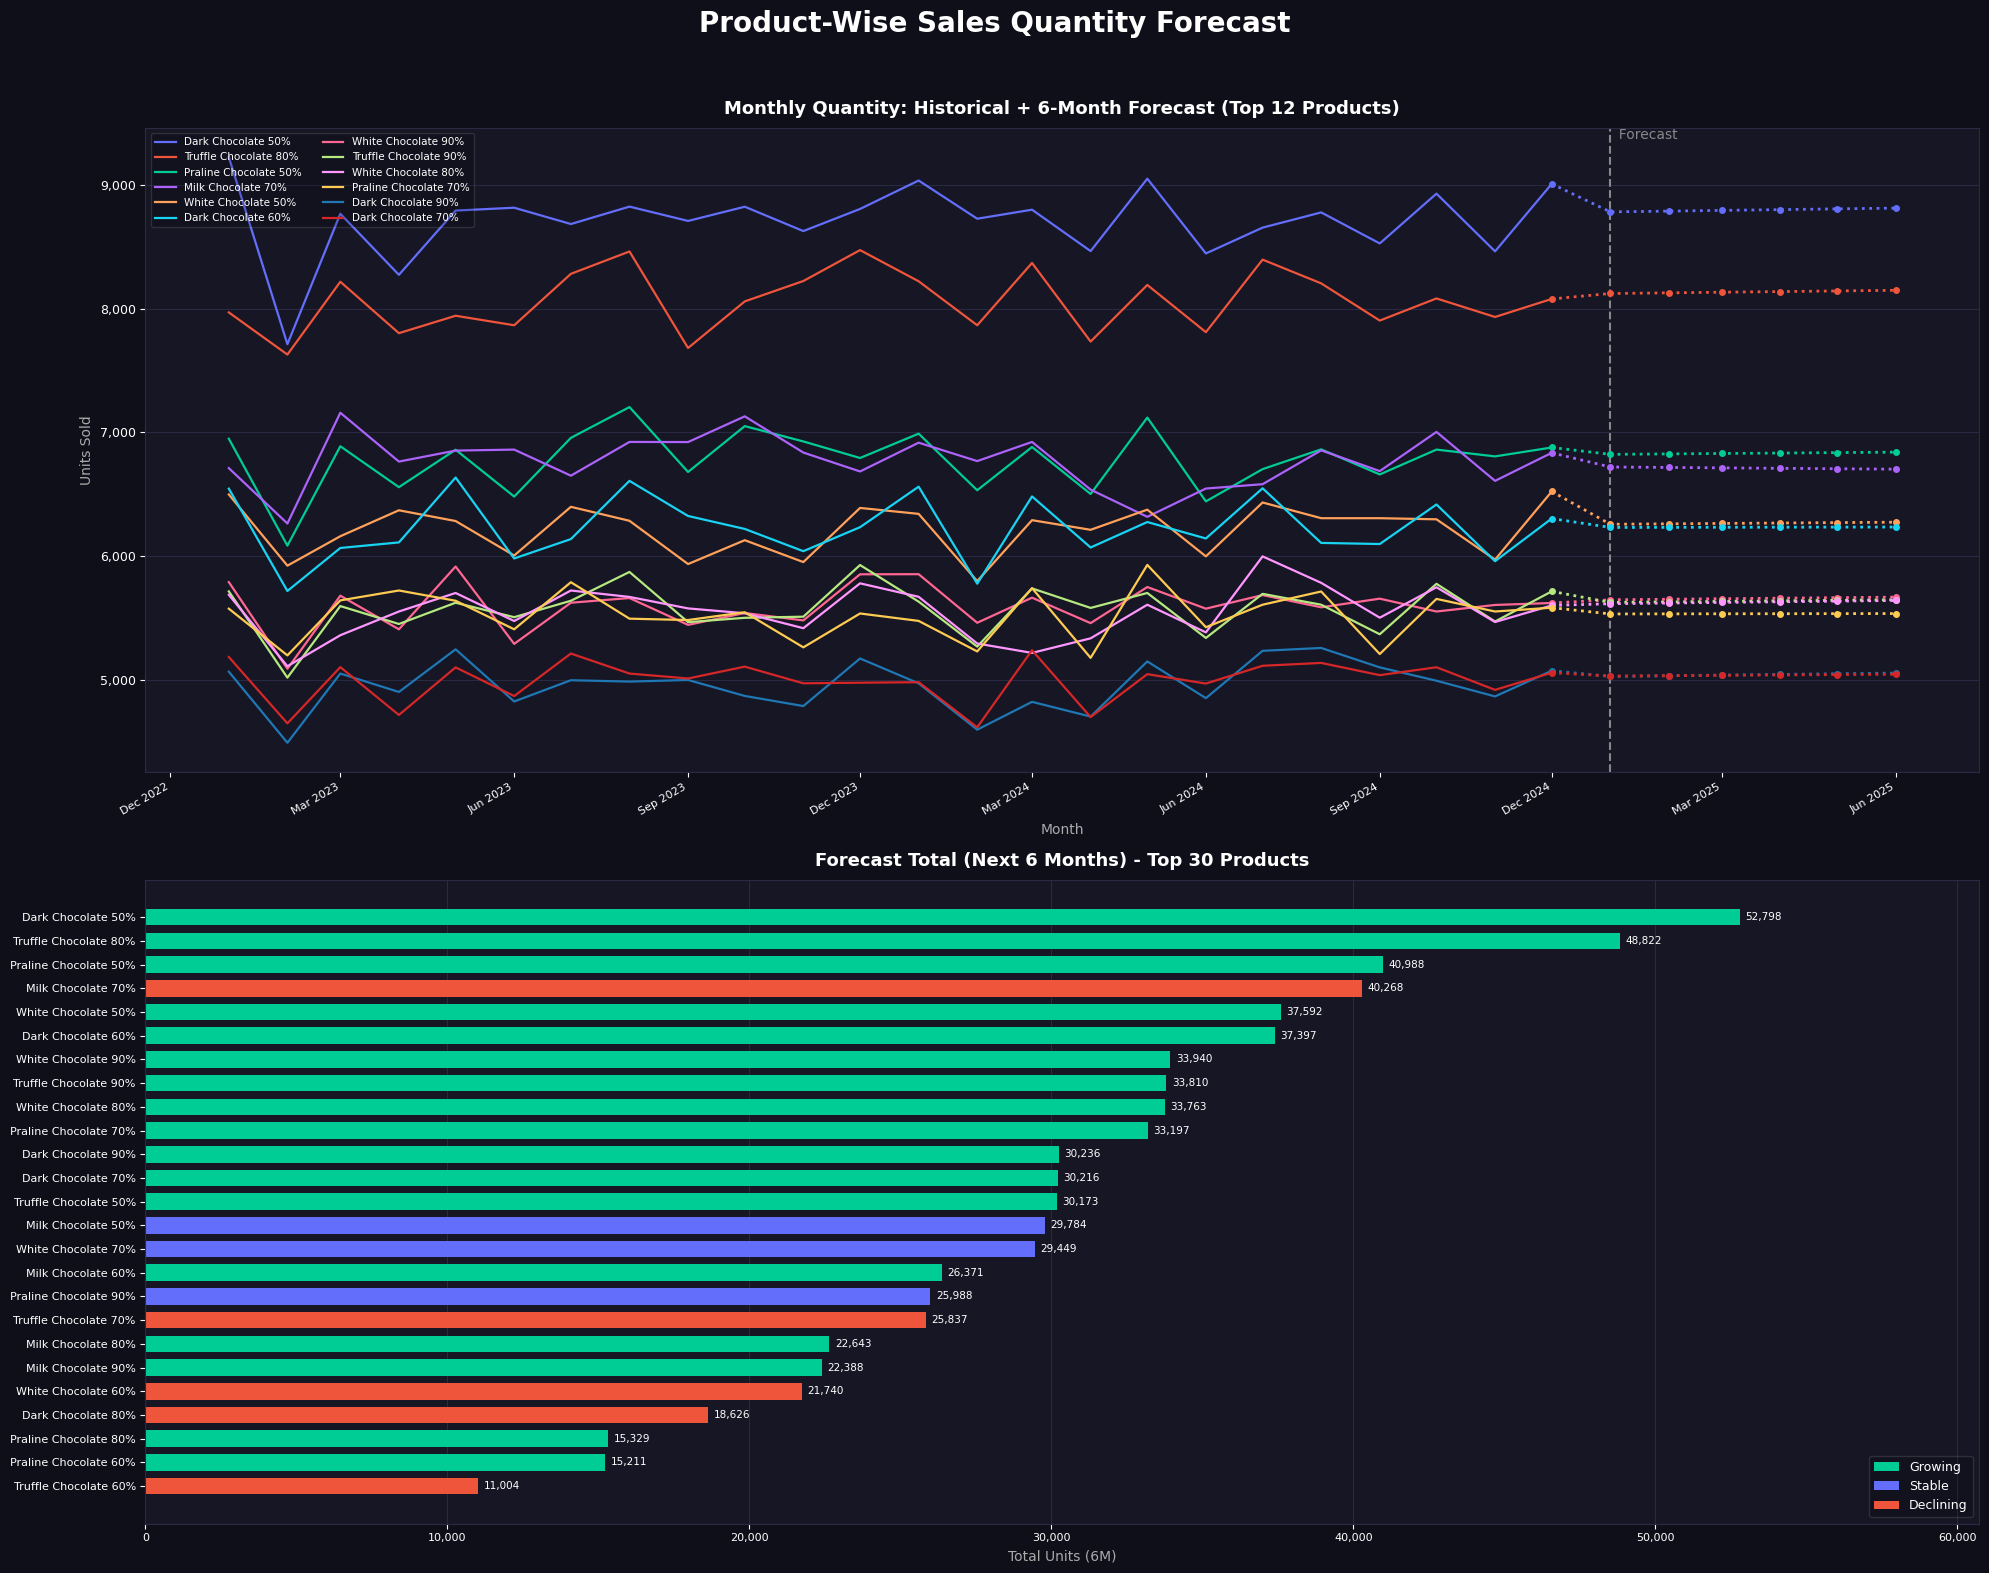

In [ ]:
# ── Product-Wise Sales Quantity Forecast ─────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch

FORECAST_MONTHS = 6
TOP_N           = 12   # products to show in the multi-line chart

# ── 1. Build monthly qty series per product ───────────────────────────────────
pq = (
    sales.merge(products[["product_id", "product_name"]], on="product_id")
    .assign(month=sales["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["product_name", "month"])["quantity"]
    .sum()
    .reset_index()
)

all_months_pw = pd.date_range(pq["month"].min(), pq["month"].max(), freq="MS")
products_list = pq["product_name"].unique()

# ── 2. Fit linear trend + 6-month forecast per product ────────────────────────
pw_rows = []
for pname in products_list:
    ts = (
        pq[pq["product_name"] == pname]
        .set_index("month")["quantity"]
        .reindex(all_months_pw, fill_value=0)
        .sort_index()
    )
    x    = np.arange(len(ts))
    coef = np.polyfit(x, ts.values, 1)

    future_months_idx = pd.date_range(
        ts.index[-1] + pd.DateOffset(months=1), periods=FORECAST_MONTHS, freq="MS"
    )
    x_future    = np.arange(len(ts), len(ts) + FORECAST_MONTHS)
    future_vals = np.polyval(coef, x_future).clip(0)

    pw_rows.append({
        "product_name"   : pname,
        "hist_months"    : list(ts.index),
        "hist_qty"       : list(ts.values),
        "future_months"  : list(future_months_idx),
        "future_qty"     : list(future_vals),
        "slope"          : coef[0],
        "total_hist_qty" : int(ts.sum()),
        "forecast_total" : float(future_vals.sum()),
        "forecast_avg_mo": float(future_vals.mean()),
        "recent_3m_avg"  : float(ts.values[-3:].mean()),
    })

pw_df = pd.DataFrame(pw_rows)

# ── 3. Summary table ──────────────────────────────────────────────────────────
summary = (
    pw_df[["product_name", "slope", "recent_3m_avg", "forecast_avg_mo", "forecast_total"]]
    .sort_values("forecast_total", ascending=False)
    .reset_index(drop=True)
)
summary.columns = ["Product", "Trend Slope", "Recent 3M Avg Qty",
                   "Forecast Avg/Mo (6M)", "Forecast Total 6M Qty"]
summary["Trend"] = summary["Trend Slope"].apply(
    lambda s: "Growing" if s > 0.5 else ("Declining" if s < -0.5 else "Stable")
)

print("=" * 72)
print("  PRODUCT-WISE SALES QUANTITY FORECAST - NEXT 6 MONTHS")
print("=" * 72)
print(summary.head(20).to_string(index=False))
print("-" * 72)
top_prd = summary.iloc[0]
low_prd = summary.iloc[-1]
print(f"\nHighest forecast: {top_prd['Product']} -> {top_prd['Forecast Total 6M Qty']:,.0f} units")
print(f"Lowest  forecast: {low_prd['Product']} -> {low_prd['Forecast Total 6M Qty']:,.0f} units")
growing   = (summary["Trend Slope"] >  0.5).sum()
declining = (summary["Trend Slope"] < -0.5).sum()
stable    = len(summary) - growing - declining
print(f"\nTrend breakdown:  Growing={growing}  Stable={stable}  Declining={declining}")

# ── 4. matplotlib dashboard ───────────────────────────────────────────────────
plt.style.use("dark_background")
BG_FC    = "#0F0F1A"
PANEL_FC = "#161625"

palette = [
    "#636EFA","#EF553B","#00CC96","#AB63FA","#FFA15A",
    "#19D3F3","#FF6692","#B6E880","#FF97FF","#FECB52",
    "#1F77B4","#D62728",
]
bar_colors_map = {"Growing": "#00CC96", "Stable": "#636EFA", "Declining": "#EF553B"}

top_products_pw  = summary.head(TOP_N)["Product"].tolist()
forecast_start   = pw_df.iloc[0]["future_months"][0]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(20, 16),
    facecolor=BG_FC,
    gridspec_kw={"height_ratios": [1, 1]},
)
fig.suptitle("Product-Wise Sales Quantity Forecast",
             fontsize=20, fontweight="bold", color="white", y=0.98)

for ax in (ax1, ax2):
    ax.set_facecolor(PANEL_FC)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2a45")

# ── Panel 1: time-series lines ────────────────────────────────────────────────
ax1.set_title(
    f"Monthly Quantity: Historical + {FORECAST_MONTHS}-Month Forecast (Top {TOP_N} Products)",
    color="white", fontsize=13, fontweight="bold", pad=10
)

for i, pname in enumerate(top_products_pw):
    r     = pw_df[pw_df["product_name"] == pname].iloc[0]
    color = palette[i % len(palette)]

    # historical
    ax1.plot(r["hist_months"], r["hist_qty"],
             color=color, linewidth=1.6, label=pname)

    # forecast (dotted, with markers) — connect from last hist point
    fc_x = [r["hist_months"][-1]] + r["future_months"]
    fc_y = [r["hist_qty"][-1]]    + r["future_qty"]
    ax1.plot(fc_x, fc_y,
             color=color, linewidth=2, linestyle=":", marker="o",
             markersize=4, markerfacecolor=color, zorder=5)

# forecast boundary line
ax1.axvline(forecast_start, color="#888888", linewidth=1.5, linestyle="--")
ax1.text(forecast_start, ax1.get_ylim()[1] if ax1.get_ylim()[1] else 1,
         "  Forecast", color="#888888", fontsize=10, va="top")

ax1.set_xlabel("Month", color="#aaaaaa", fontsize=10)
ax1.set_ylabel("Units Sold", color="#aaaaaa", fontsize=10)
ax1.tick_params(colors="white", labelsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.grid(axis="y", color="#2a2a45", linewidth=0.7)
ax1.set_axisbelow(True)
ax1.legend(fontsize=7.5, framealpha=0.15, labelcolor="white",
           loc="upper left", ncol=2)

# ── Panel 2: horizontal bar — top 30 products ─────────────────────────────────
ax2.set_title(
    "Forecast Total (Next 6 Months) - Top 30 Products",
    color="white", fontsize=13, fontweight="bold", pad=10
)

bar_data = summary.sort_values("Forecast Total 6M Qty", ascending=True).head(30)
bar_clrs = [bar_colors_map.get(t, "#888") for t in bar_data["Trend"]]

bars = ax2.barh(
    bar_data["Product"],
    bar_data["Forecast Total 6M Qty"],
    color=bar_clrs,
    edgecolor="none",
    height=0.7,
)
ax2.bar_label(bars,
              labels=[f"{v:,.0f}" for v in bar_data["Forecast Total 6M Qty"]],
              padding=4, color="white", fontsize=7.5)
ax2.set_xlim(0, bar_data["Forecast Total 6M Qty"].max() * 1.15)
ax2.set_xlabel("Total Units (6M)", color="#aaaaaa", fontsize=10)
ax2.tick_params(colors="white", labelsize=8)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.grid(axis="x", color="#2a2a45", linewidth=0.7)
ax2.set_axisbelow(True)

legend_handles = [Patch(facecolor=c, label=l) for l, c in bar_colors_map.items()]
ax2.legend(handles=legend_handles, loc="lower right",
           fontsize=9, framealpha=0.15, labelcolor="white")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("product_forecast.png", dpi=150, bbox_inches="tight", facecolor=BG_FC)
plt.show()

In [ ]:

print(summary.head(20).to_string(index=False))
print()
print(f"Growing={growing}  Stable={stable}  Declining={declining}")


              Product  Trend Slope  Recent 3M Avg Qty  Forecast Avg/Mo (6M)  Forecast Total 6M Qty     Trend
   Dark Chocolate 50%     4.771304        8816.666667           8779.736232           52678.417391   Growing
Truffle Chocolate 80%     4.457826        8134.000000           8126.492391           48758.954348   Growing
Praline Chocolate 50%     8.175652        6802.666667           6900.551449           41403.308696   Growing
   Milk Chocolate 70%     6.078696        6811.333333           6855.138768           41130.832609   Growing
   Dark Chocolate 60%     6.484348        6199.333333           6320.015217           37920.091304   Growing
  White Chocolate 50%    -0.229565        6225.333333           6211.973188           37271.839130    Stable
  White Chocolate 80%     3.472609        5540.333333           5600.880797           33605.284783   Growing
  White Chocolate 90%    -0.251739        5589.000000           5588.598913           33531.593478    Stable
Truffle Chocolate 9

PRODUCTS THAT SHOULD BE RESTOCKED MORE FREQUENTLY
              Product  Restock Priority Score         Suggested Cadence  Forecast Avg Monthly Qty  Trend Slope  Demand Volatility (CV)  Avg Monthly Orders (3M)
   Dark Chocolate 50%                    77.7 Very Frequent (2-3x/week)                    8780.0         4.77                    0.02                   2955.0
Praline Chocolate 50%                    73.8         Frequent (Weekly)                    6901.0         8.18                    0.02                   2257.0
Truffle Chocolate 80%                    70.4         Frequent (Weekly)                    8126.0         4.46                    0.01                   2720.7
   Milk Chocolate 70%                    66.3         Frequent (Weekly)                    6855.0         6.08                    0.02                   2281.0
   Dark Chocolate 60%                    66.0         Frequent (Weekly)                    6320.0         6.48                    0.03                

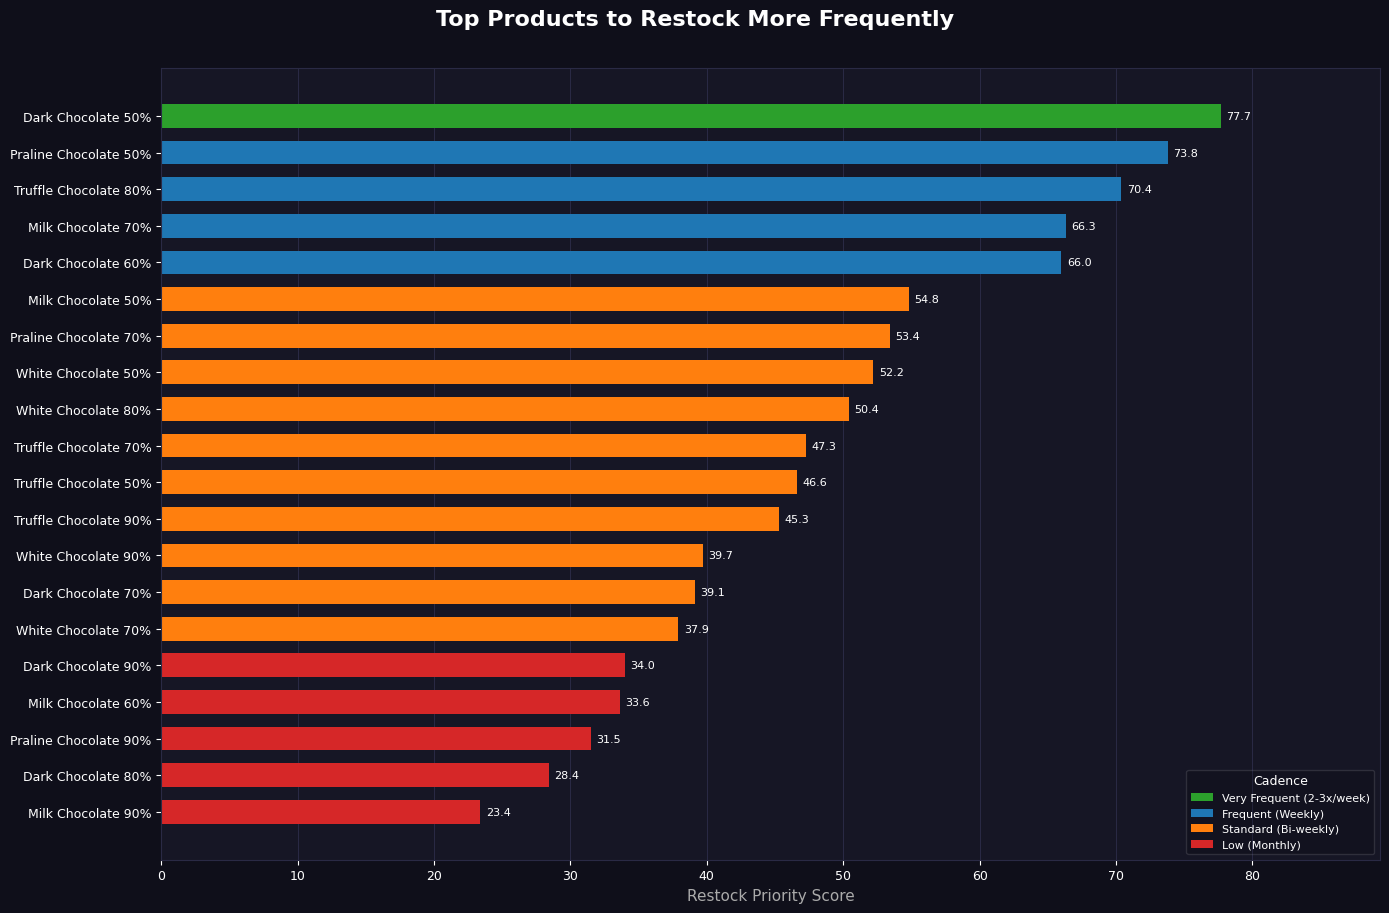

In [ ]:
# ── Products To Restock More Frequently ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

HORIZON_MONTHS = 6

# Column fallbacks (for independent cell execution)
if 'date_col' not in globals():
    date_col = 'order_date'
if 'product_label_col' not in globals():
    product_label_col = 'product_name'
if 'order_col' not in globals():
    order_col = 'order_id'

# Ensure date column is datetime
if not pd.api.types.is_datetime64_any_dtype(analysis_df[date_col]):
    analysis_df[date_col] = pd.to_datetime(analysis_df[date_col], errors='coerce')

# ── 1. Monthly quantity + monthly orders per product ──────────────────────────
prod_month = (
    analysis_df
    .assign(month=analysis_df[date_col].dt.to_period('M').dt.to_timestamp())
    .groupby([product_label_col, 'month'], as_index=False)
    .agg(monthly_qty=('quantity', 'sum'), monthly_orders=(order_col, 'nunique'))
)

all_months = pd.date_range(prod_month['month'].min(), prod_month['month'].max(), freq='MS')
products   = prod_month[product_label_col].unique()

rows = []
for p in products:
    g = (
        prod_month[prod_month[product_label_col] == p]
        .set_index('month')
        .reindex(all_months, fill_value=0)
        .sort_index()
    )
    qty  = g['monthly_qty'].values.astype(float)
    ords = g['monthly_orders'].values.astype(float)
    x    = np.arange(len(qty))

    slope, intercept = np.polyfit(x, qty, 1)
    future_x   = np.arange(len(qty), len(qty) + HORIZON_MONTHS)
    future_qty = np.polyval([slope, intercept], future_x).clip(0)

    recent_6m = qty[-6:] if len(qty) >= 6 else qty
    vol_cv    = (recent_6m.std() / recent_6m.mean()) if recent_6m.mean() > 0 else 0

    rows.append({
        'Product'                 : p,
        'Trend Slope'             : slope,
        'Recent 3M Avg Qty'       : qty[-3:].mean(),
        'Forecast Avg Monthly Qty': future_qty.mean(),
        'Forecast 6M Qty'         : future_qty.sum(),
        'Demand Volatility (CV)'  : vol_cv,
        'Avg Monthly Orders (3M)' : ords[-3:].mean(),
    })

restock_df = pd.DataFrame(rows)

# ── 2. Restock priority score (0-100) ────────────────────────────────────────
def minmax(s):
    rng = s.max() - s.min()
    if rng == 0:
        return pd.Series(np.ones(len(s)) * 0.5, index=s.index)
    return (s - s.min()) / rng

score_demand   = minmax(restock_df['Forecast Avg Monthly Qty']) * 45
score_growth   = minmax(restock_df['Trend Slope'].clip(lower=0)) * 25
score_vol      = minmax(restock_df['Demand Volatility (CV)']) * 15
score_velocity = minmax(restock_df['Avg Monthly Orders (3M)']) * 15

restock_df['Restock Priority Score'] = (
    score_demand + score_growth + score_vol + score_velocity
).round(1)

# ── 3. Suggested restock cadence ─────────────────────────────────────────────
conditions = [
    restock_df['Restock Priority Score'] >= 75,
    restock_df['Restock Priority Score'] >= 55,
    restock_df['Restock Priority Score'] >= 35,
]
choices = ['Very Frequent (2-3x/week)', 'Frequent (Weekly)', 'Standard (Bi-weekly)']
restock_df['Suggested Cadence'] = np.select(conditions, choices, default='Low (Monthly)')
restock_df = restock_df.sort_values('Restock Priority Score', ascending=False).reset_index(drop=True)

# ── 4. Output table ───────────────────────────────────────────────────────────
show_cols = [
    'Product', 'Restock Priority Score', 'Suggested Cadence',
    'Forecast Avg Monthly Qty', 'Trend Slope', 'Demand Volatility (CV)',
    'Avg Monthly Orders (3M)'
]
out = restock_df[show_cols].copy()
out['Forecast Avg Monthly Qty'] = out['Forecast Avg Monthly Qty'].round(0)
out['Trend Slope']              = out['Trend Slope'].round(2)
out['Demand Volatility (CV)']   = out['Demand Volatility (CV)'].round(2)
out['Avg Monthly Orders (3M)']  = out['Avg Monthly Orders (3M)'].round(1)

print('=' * 78)
print('PRODUCTS THAT SHOULD BE RESTOCKED MORE FREQUENTLY')
print('=' * 78)
print(out.head(15).to_string(index=False))
print('\nCadence split:')
print(restock_df['Suggested Cadence'].value_counts().to_string())

# ── 5. matplotlib chart ───────────────────────────────────────────────────────
plt.style.use('dark_background')
BG_FC    = '#0F0F1A'
PANEL_FC = '#161625'

color_map = {
    'Very Frequent (2-3x/week)': '#2ca02c',
    'Frequent (Weekly)'        : '#1f77b4',
    'Standard (Bi-weekly)'     : '#ff7f0e',
    'Low (Monthly)'            : '#d62728',
}
cadence_order = [
    'Very Frequent (2-3x/week)',
    'Frequent (Weekly)',
    'Standard (Bi-weekly)',
    'Low (Monthly)',
]

# Top 20 — sort descending so highest score = row 0 → top after invert_yaxis
plot_top = out.head(20).copy()
plot_top['Suggested Cadence'] = pd.Categorical(
    plot_top['Suggested Cadence'], categories=cadence_order, ordered=True
)
plot_top = plot_top.sort_values('Restock Priority Score', ascending=False)

fig, ax = plt.subplots(figsize=(14, 9), facecolor=BG_FC)
ax.set_facecolor(PANEL_FC)
for spine in ax.spines.values():
    spine.set_edgecolor('#2a2a45')

fig.suptitle('Top Products to Restock More Frequently',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# One barh call per cadence group → clean legend
for cadence in cadence_order:
    subset = plot_top[plot_top['Suggested Cadence'] == cadence]
    if subset.empty:
        continue
    bars = ax.barh(
        subset['Product'],
        subset['Restock Priority Score'],
        color=color_map[cadence],
        edgecolor='none',
        height=0.65,
        label=cadence,
    )
    ax.bar_label(bars,
                 labels=[f"{v:.1f}" for v in subset['Restock Priority Score']],
                 padding=4, color='white', fontsize=8)

# Flip so row 0 (highest score) is at the TOP
ax.invert_yaxis()

ax.set_xlabel('Restock Priority Score', color='#aaaaaa', fontsize=11)
ax.set_xlim(0, plot_top['Restock Priority Score'].max() * 1.15)
ax.tick_params(colors='white', labelsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}'))
ax.grid(axis='x', color='#2a2a45', linewidth=0.7)
ax.set_axisbelow(True)

legend_handles = [Patch(facecolor=color_map[c], label=c) for c in cadence_order
                  if c in plot_top['Suggested Cadence'].values]
ax.legend(handles=legend_handles, title='Cadence', title_fontsize=9,
          fontsize=8, framealpha=0.15, labelcolor='white',
          loc='lower right')

plt.tight_layout()
plt.savefig('restock_priority.png', dpi=150, bbox_inches='tight', facecolor=BG_FC)
plt.show()

STORE PERFORMANCE OUTLOOK (NEXT 6 MONTHS)
Improving stores: 10
Stable stores   : 86
Declining stores: 4

Top improving stores:
store_id         store_name  recent_3m_avg  forecast_avg_6m  change_pct  trend_slope
    S004  Chocolate Store 4    9611.440000     10471.484942    8.948138     9.602774
    S024 Chocolate Store 24    9965.330000     10586.940551    6.237732     8.216148
    S009  Chocolate Store 9   10298.890000     10919.579051    6.026757    19.130548
    S097 Chocolate Store 97   10389.356667     10937.149152    5.272631    21.300443
    S006  Chocolate Store 6   10409.303333     10912.708409    4.836107    14.161422
    S025 Chocolate Store 25   10301.120000     10769.339931    4.545330    16.082857
    S027 Chocolate Store 27   10527.243333     10907.422924    3.611388     7.699778
    S098 Chocolate Store 98   10589.733333     10962.162989    3.516894    11.213283
    S020 Chocolate Store 20   10701.923333     11049.976196    3.252246    28.896913
    S023 Chocolate Stor

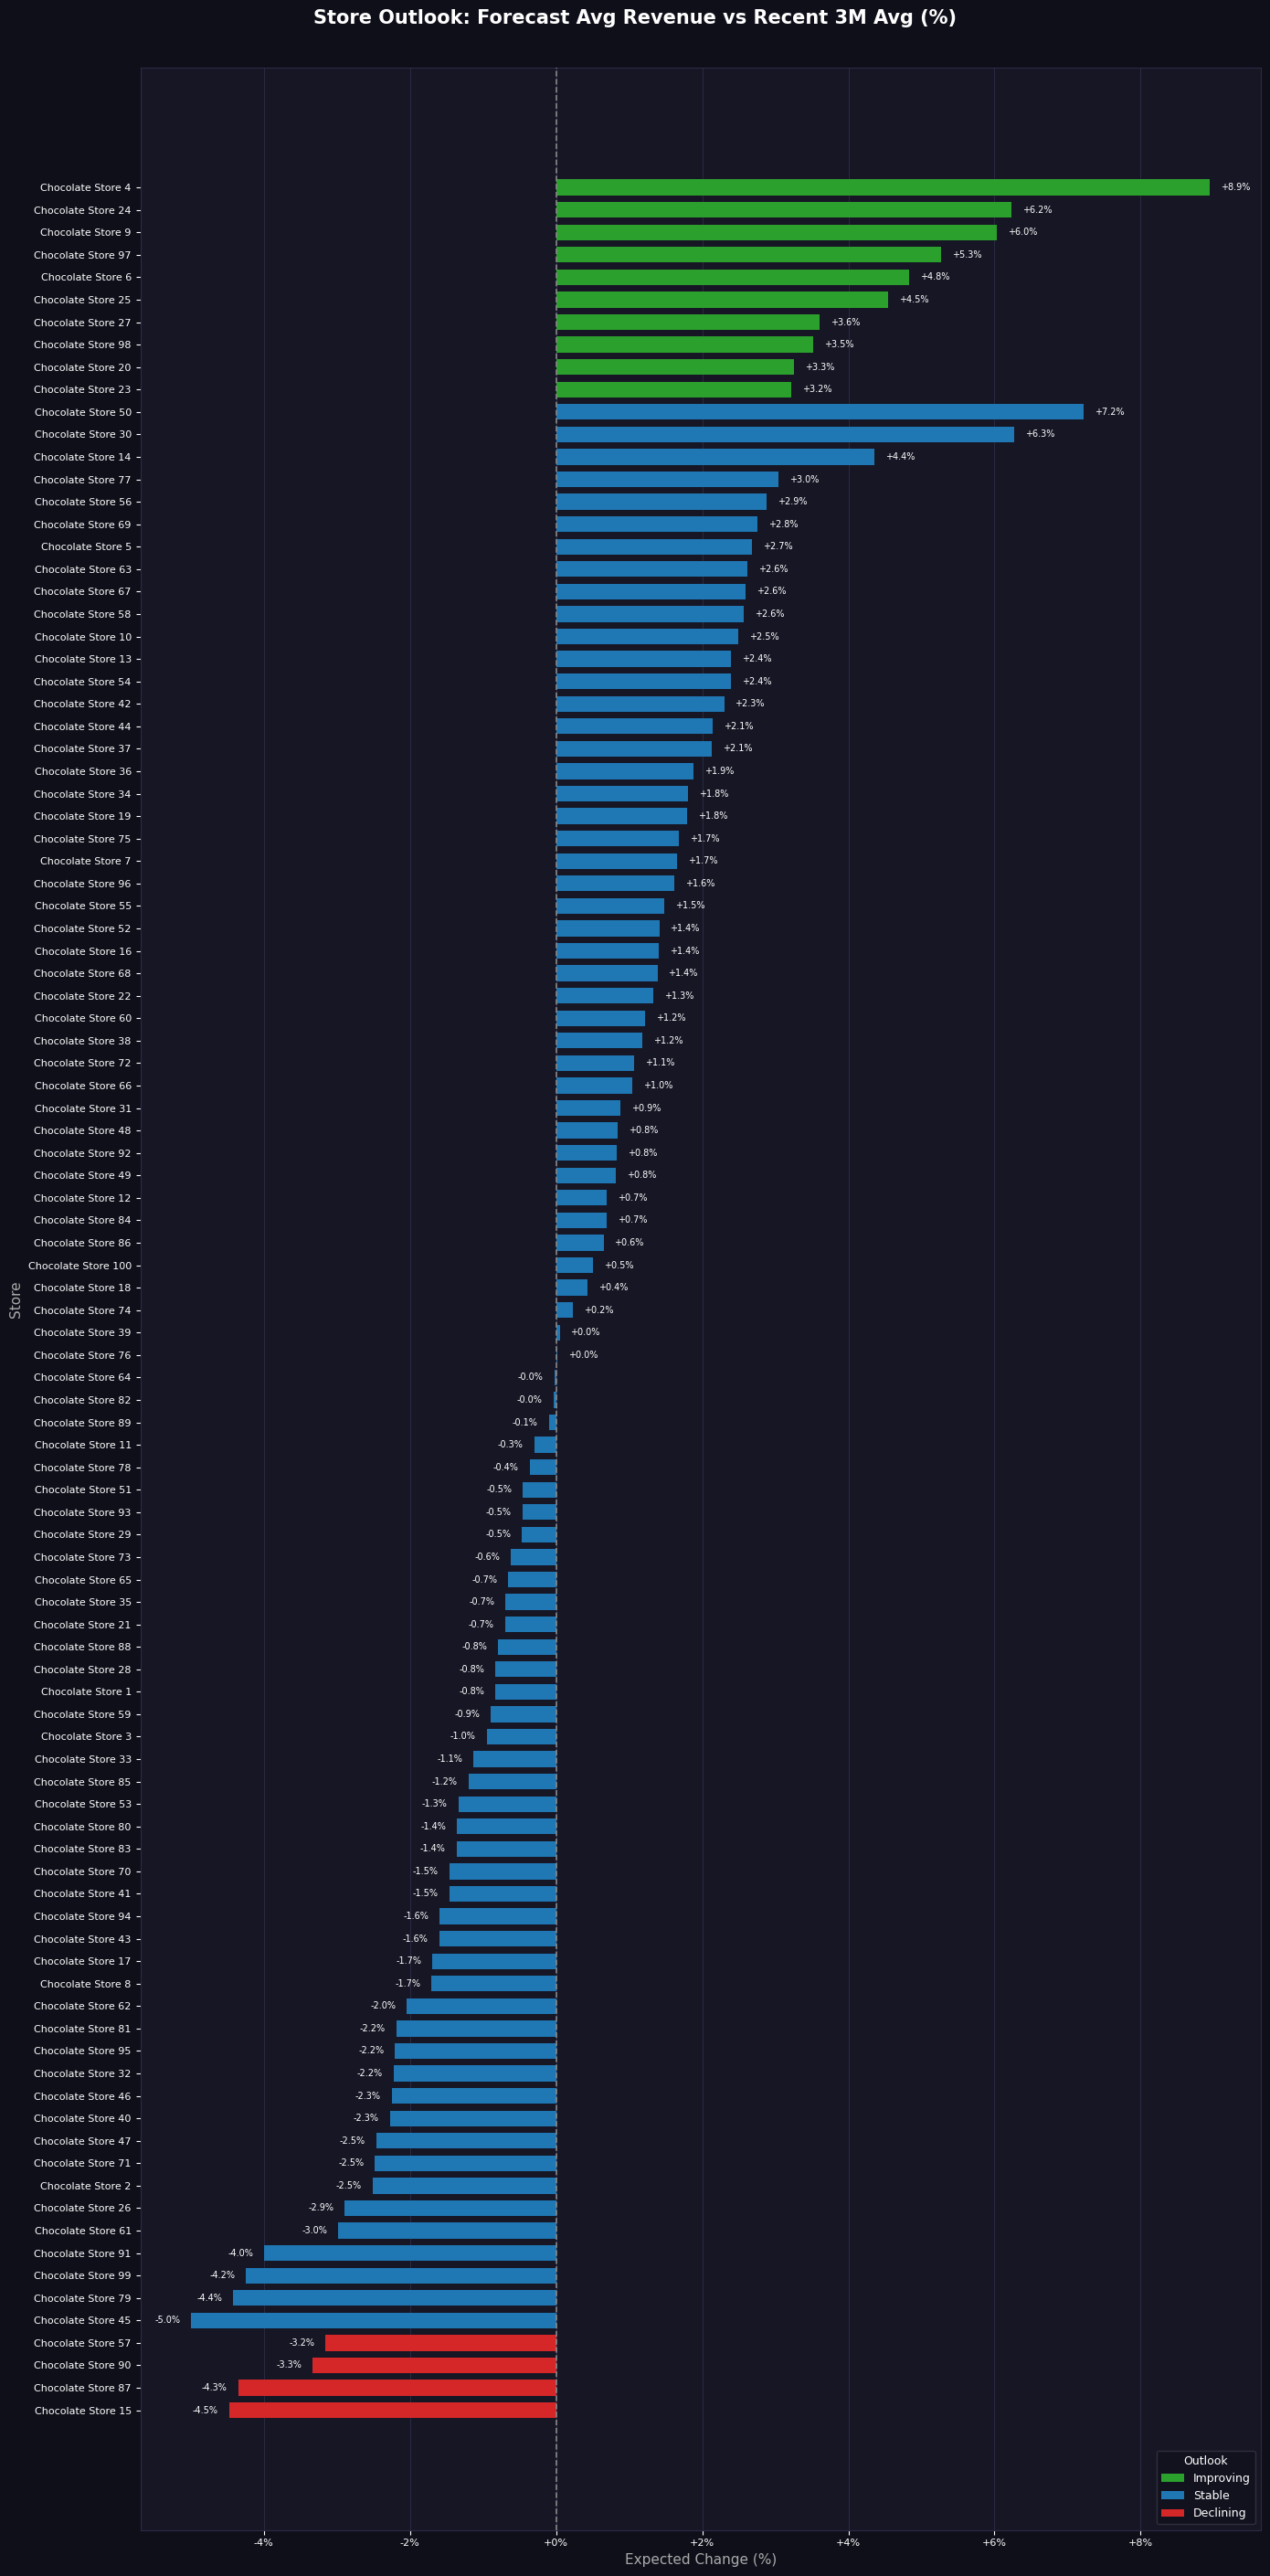

In [ ]:
# Which stores will improve or decline in performance?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

store_label_col = 'store_name' if 'store_name' in analysis_df.columns else 'store_id'
FORECAST_MONTHS = 6
outlook_order   = ['Improving', 'Stable', 'Declining']

# ── 1. Monthly revenue by store ───────────────────────────────────────────────
store_month = (
    analysis_df
    .groupby(['store_id', store_label_col, pd.Grouper(key='order_date', freq='MS')])['revenue']
    .sum()
    .reset_index()
    .rename(columns={'order_date': 'month', 'revenue': 'monthly_revenue'})
)

all_months_store = pd.date_range(
    store_month['month'].min(), store_month['month'].max(), freq='MS'
)

rows = []
for (sid, sname), g in store_month.groupby(['store_id', store_label_col]):
    ts = (
        g.set_index('month')['monthly_revenue']
        .reindex(all_months_store, fill_value=0.0)
        .sort_index()
    )
    if len(ts) < 6:
        continue

    x = np.arange(len(ts))
    slope, intercept = np.polyfit(x, ts.values, 1)

    future_x    = np.arange(len(ts), len(ts) + FORECAST_MONTHS)
    future_vals = np.maximum(intercept + slope * future_x, 0)

    recent_3m_avg = ts.tail(3).mean()
    forecast_avg  = future_vals.mean()
    change_pct    = ((forecast_avg - recent_3m_avg) / recent_3m_avg * 100) if recent_3m_avg > 0 else 0

    rows.append({
        'store_id'         : sid,
        store_label_col    : sname,
        'trend_slope'      : slope,
        'recent_3m_avg'    : recent_3m_avg,
        'forecast_avg_6m'  : forecast_avg,
        'forecast_total_6m': future_vals.sum(),
        'change_pct'       : change_pct,
    })

store_trend_df = pd.DataFrame(rows)

# ── 2. Classify trend ─────────────────────────────────────────────────────────
def classify(row):
    if row['change_pct'] >= 3 and row['trend_slope'] > 0:
        return 'Improving'
    if row['change_pct'] <= -3 and row['trend_slope'] < 0:
        return 'Declining'
    return 'Stable'

store_trend_df['performance_outlook'] = store_trend_df.apply(classify, axis=1)
store_trend_df['performance_outlook'] = pd.Categorical(
    store_trend_df['performance_outlook'], categories=outlook_order, ordered=True
)

# ── 3. Print summary ──────────────────────────────────────────────────────────
improving_stores = (store_trend_df[store_trend_df['performance_outlook'] == 'Improving']
                    .sort_values('change_pct', ascending=False))
declining_stores = (store_trend_df[store_trend_df['performance_outlook'] == 'Declining']
                    .sort_values('change_pct', ascending=True))
outlook_counts   = (store_trend_df['performance_outlook']
                    .value_counts().reindex(outlook_order, fill_value=0))

print('=' * 80)
print('STORE PERFORMANCE OUTLOOK (NEXT 6 MONTHS)')
print('=' * 80)
print(f"Improving stores: {int(outlook_counts['Improving'])}")
print(f"Stable stores   : {int(outlook_counts['Stable'])}")
print(f"Declining stores: {int(outlook_counts['Declining'])}")

show_cols = ['store_id', store_label_col, 'recent_3m_avg',
             'forecast_avg_6m', 'change_pct', 'trend_slope']
print('\nTop improving stores:')
print(improving_stores[show_cols].head(10).to_string(index=False))
print('\nTop declining stores:')
print(declining_stores[show_cols].head(10).to_string(index=False))

# ── 4. matplotlib chart ───────────────────────────────────────────────────────
plt.style.use('dark_background')
BG_FC    = '#0F0F1A'
PANEL_FC = '#161625'
colors   = {'Improving': '#2ca02c', 'Stable': '#1f77b4', 'Declining': '#d62728'}

# Sort: Improving=0 → top after invert_yaxis, Declining=2 → bottom
outlook_sort = {'Improving': 0, 'Stable': 1, 'Declining': 2}
plot_df = (
    store_trend_df
    .assign(outlook_rank=store_trend_df['performance_outlook'].map(outlook_sort))
    .sort_values(['outlook_rank', 'change_pct'], ascending=[True, False])
    .drop(columns='outlook_rank')
    .reset_index(drop=True)
)

fig_h = max(8, len(plot_df) * 0.28)
fig, ax = plt.subplots(figsize=(14, fig_h), facecolor=BG_FC)
ax.set_facecolor(PANEL_FC)
for spine in ax.spines.values():
    spine.set_edgecolor('#2a2a45')

fig.suptitle('Store Outlook: Forecast Avg Revenue vs Recent 3M Avg (%)',
             fontsize=15, fontweight='bold', color='white', y=1.005)

# One barh call per group → clean legend
for outlook in outlook_order:
    subset = plot_df[plot_df['performance_outlook'] == outlook]
    if subset.empty:
        continue
    ax.barh(
        subset[store_label_col].astype(str),
        subset['change_pct'],
        color=colors[outlook],
        edgecolor='none',
        height=0.7,
        label=outlook,
    )

# First row → top of chart
ax.invert_yaxis()

# Zero reference line
ax.axvline(0, color='#888888', linewidth=1.2, linestyle='--', zorder=3)

# Value labels
for _, row in plot_df.iterrows():
    pad   = 0.15 if row['change_pct'] >= 0 else -0.15
    align = 'left' if row['change_pct'] >= 0 else 'right'
    ax.text(row['change_pct'] + pad, str(row[store_label_col]),
            f"{row['change_pct']:+.1f}%",
            va='center', ha=align, fontsize=7, color='white')

ax.set_xlabel('Expected Change (%)', color='#aaaaaa', fontsize=11)
ax.set_ylabel('Store', color='#aaaaaa', fontsize=11)
ax.tick_params(colors='white', labelsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
ax.grid(axis='x', color='#2a2a45', linewidth=0.7)
ax.set_axisbelow(True)

legend_handles = [Patch(facecolor=colors[o], label=o) for o in outlook_order
                  if o in plot_df['performance_outlook'].values]
ax.legend(handles=legend_handles, title='Outlook', title_fontsize=9,
          fontsize=9, framealpha=0.15, labelcolor='white', loc='lower right')

plt.tight_layout()
plt.savefig('store_performance_outlook.png', dpi=150,
            bbox_inches='tight', facecolor=BG_FC)
plt.show()

STORE-LEVEL REVENUE GROWTH FORECAST (NEXT 6 MONTHS)
Stores analyzed      : 100
Average pred. growth : 0.44%

Top 15 stores by predicted growth:
store_id         store_name  predicted_growth_pct  recent_3m_avg_rev  forecast_6m_avg_monthly_rev  forecast_6m_total_rev  trend_slope
    S004  Chocolate Store 4                  8.95           9,611.44                    10,471.48              62,828.91         9.60
    S050 Chocolate Store 50                  7.22          10,025.16                    10,749.35              64,496.08        -4.28
    S030 Chocolate Store 30                  6.26          10,114.88                    10,748.46              64,490.73        -0.75
    S024 Chocolate Store 24                  6.24           9,965.33                    10,586.94              63,521.64         8.22
    S009  Chocolate Store 9                  6.03          10,298.89                    10,919.58              65,517.47        19.13
    S097 Chocolate Store 97                  5.27   

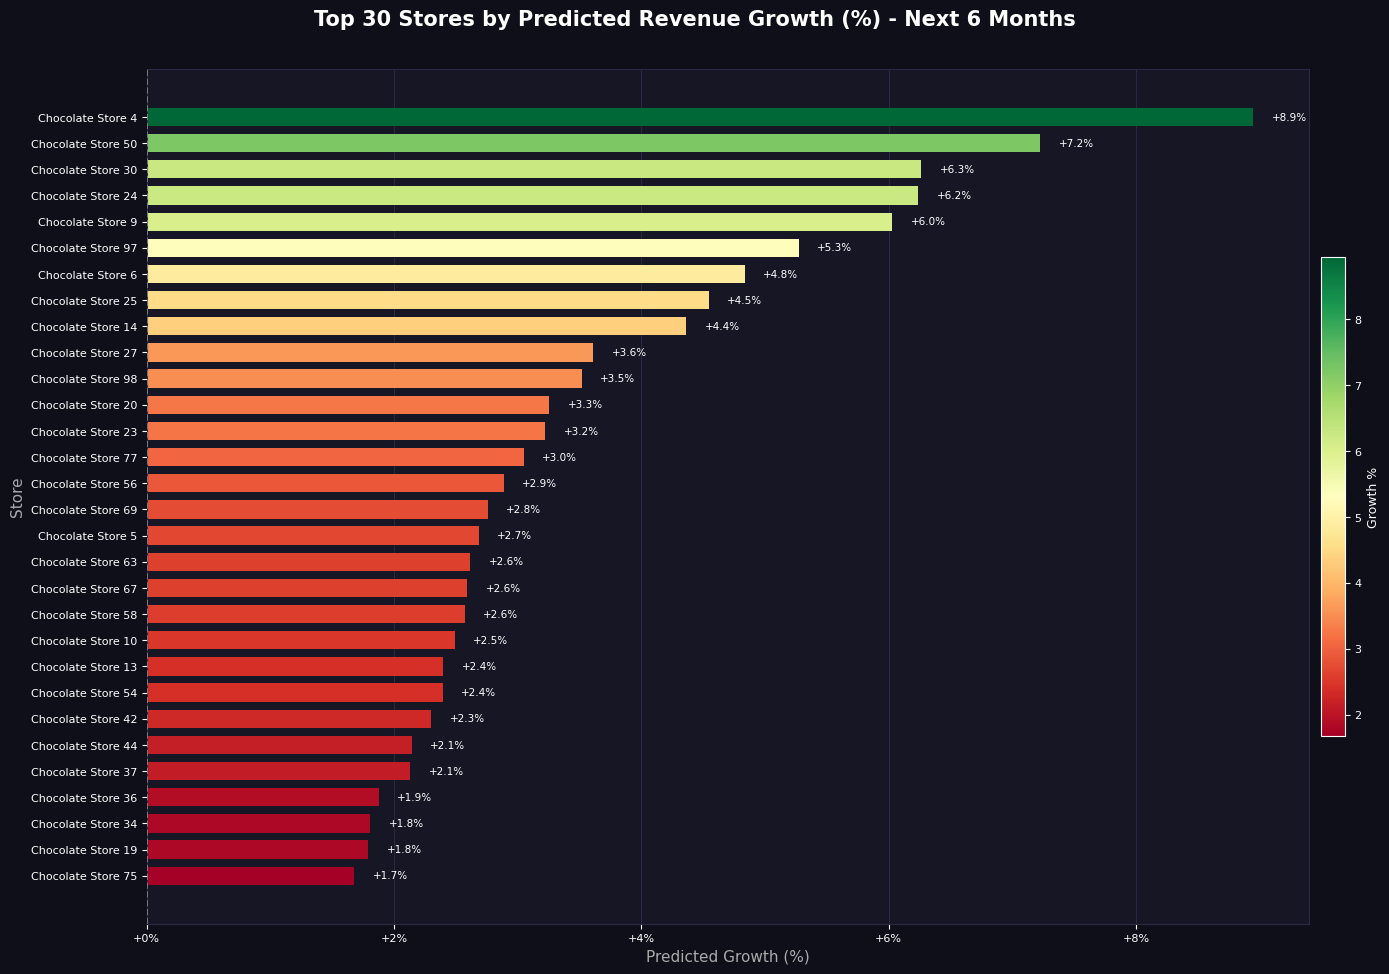

In [ ]:
# Predict store-level revenue growth (next 6 months)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

store_label_col = 'store_name' if 'store_name' in analysis_df.columns else 'store_id'
FORECAST_MONTHS = 6

# ── 1. Monthly revenue by store ───────────────────────────────────────────────
store_monthly = (
    analysis_df
    .groupby(['store_id', store_label_col, pd.Grouper(key='order_date', freq='MS')])['revenue']
    .sum()
    .reset_index()
    .rename(columns={'order_date': 'month', 'revenue': 'monthly_revenue'})
)

all_months = pd.date_range(store_monthly['month'].min(), store_monthly['month'].max(), freq='MS')

# ── 2. Fit linear trend + forecast per store ──────────────────────────────────
growth_rows = []
for (sid, sname), g in store_monthly.groupby(['store_id', store_label_col]):
    ts = (
        g.set_index('month')['monthly_revenue']
        .reindex(all_months, fill_value=0.0)
        .sort_index()
    )
    if len(ts) < 6:
        continue

    x = np.arange(len(ts))
    slope, intercept = np.polyfit(x, ts.values, 1)

    future_x    = np.arange(len(ts), len(ts) + FORECAST_MONTHS)
    future_vals = np.maximum(intercept + slope * future_x, 0)

    recent_3m_avg   = ts.tail(3).mean()
    forecast_6m_avg = future_vals.mean()
    growth_pct      = ((forecast_6m_avg - recent_3m_avg) / recent_3m_avg * 100) if recent_3m_avg > 0 else np.nan

    growth_rows.append({
        'store_id'                  : sid,
        store_label_col             : sname,
        'recent_3m_avg_rev'         : recent_3m_avg,
        'forecast_6m_avg_monthly_rev': forecast_6m_avg,
        'forecast_6m_total_rev'     : future_vals.sum(),
        'predicted_growth_pct'      : growth_pct,
        'trend_slope'               : slope,
    })

store_growth_df = (
    pd.DataFrame(growth_rows)
    .dropna(subset=['predicted_growth_pct'])
    .sort_values('predicted_growth_pct', ascending=False)
    .reset_index(drop=True)
)

# ── 3. Print summary ──────────────────────────────────────────────────────────
print('=' * 92)
print('STORE-LEVEL REVENUE GROWTH FORECAST (NEXT 6 MONTHS)')
print('=' * 92)
print(f"Stores analyzed      : {len(store_growth_df)}")
print(f"Average pred. growth : {store_growth_df['predicted_growth_pct'].mean():.2f}%")

show_cols = ['store_id', store_label_col, 'predicted_growth_pct',
             'recent_3m_avg_rev', 'forecast_6m_avg_monthly_rev',
             'forecast_6m_total_rev', 'trend_slope']

print('\nTop 15 stores by predicted growth:')
print(store_growth_df[show_cols].head(15).to_string(index=False,
      float_format=lambda v: f'{v:,.2f}'))

print('\nBottom 15 stores by predicted growth:')
print(store_growth_df[show_cols].tail(15).to_string(index=False,
      float_format=lambda v: f'{v:,.2f}'))

# ── 4. matplotlib chart ───────────────────────────────────────────────────────
plt.style.use('dark_background')
BG_FC    = '#0F0F1A'
PANEL_FC = '#161625'

# Top 30, sorted ascending → highest growth at top after invert_yaxis
plot_df = store_growth_df.head(30).sort_values('predicted_growth_pct', ascending=False).copy()

# RdYlGn colormap mapped to growth % values
vmin = plot_df['predicted_growth_pct'].min()
vmax = plot_df['predicted_growth_pct'].max()
cmap = plt.cm.RdYlGn
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
bar_colors = [cmap(norm(v)) for v in plot_df['predicted_growth_pct']]

fig_h = max(8, len(plot_df) * 0.32)
fig, ax = plt.subplots(figsize=(14, fig_h), facecolor=BG_FC)
ax.set_facecolor(PANEL_FC)
for spine in ax.spines.values():
    spine.set_edgecolor('#2a2a45')

fig.suptitle('Top 30 Stores by Predicted Revenue Growth (%) - Next 6 Months',
             fontsize=15, fontweight='bold', color='white', y=1.01)

bars = ax.barh(
    plot_df[store_label_col].astype(str),
    plot_df['predicted_growth_pct'],
    color=bar_colors,
    edgecolor='none',
    height=0.7,
)

# Value labels
for bar, val in zip(bars, plot_df['predicted_growth_pct']):
    pad   = 0.15 if val >= 0 else -0.15
    align = 'left' if val >= 0 else 'right'
    ax.text(val + pad, bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f}%', va='center', ha=align,
            fontsize=7.5, color='white')

# Zero reference line
ax.axvline(0, color='#888888', linewidth=1.2, linestyle='--', zorder=3)

# First row → top
ax.invert_yaxis()

ax.set_xlabel('Predicted Growth (%)', color='#aaaaaa', fontsize=11)
ax.set_ylabel('Store', color='#aaaaaa', fontsize=11)
ax.tick_params(colors='white', labelsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
ax.grid(axis='x', color='#2a2a45', linewidth=0.7)
ax.set_axisbelow(True)

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, fraction=0.02)
cbar.set_label('Growth %', color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white', labelsize=8)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.tight_layout()
plt.savefig('store_growth_forecast.png', dpi=150, bbox_inches='tight', facecolor=BG_FC)
plt.show()

In [ ]:
%pip install mpld3
%pip install mplcursors


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\hetal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\hetal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\hetal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
widget backend unavailable; switched to inline backend.
STORE EXPANSION POTENTIAL — COMPOSITE SCORE RANKING
Tier                    Count   Avg Score
------------------------------------------
  High Potential           30       66.9
  Moderate Potential       30       53.7
  Watch & Improve          40       35.5

Top 20 stores by Expansion Score:
 rank store_id         store_name  expansion_score expansion_tier  predicted_growth_pct  total_revenue  total_orders   aov   cv
    1     S098 Chocolate Store 98            85.40 High Potential                  3.52     259,055.13         10130 25.57 0.05
    2     S027 Chocolate Store 27            81.50 High Potential                  3.61     259,006.23         10163 25.49 0.08
    3     S050 Chocolate Store 50            81.30 High Potential                  7.22     259,526.62         10110 25.67 0.07
    4     S074 Chocolate Store 74            80.70 High Potential      

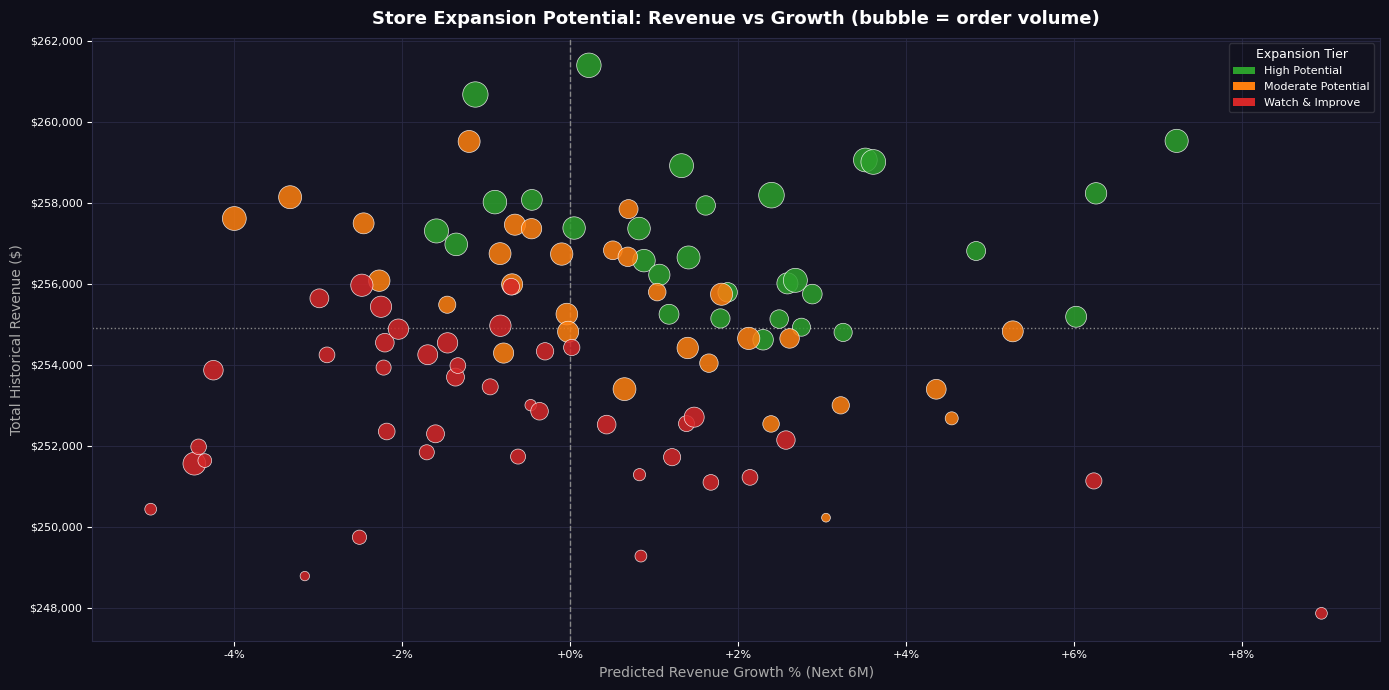

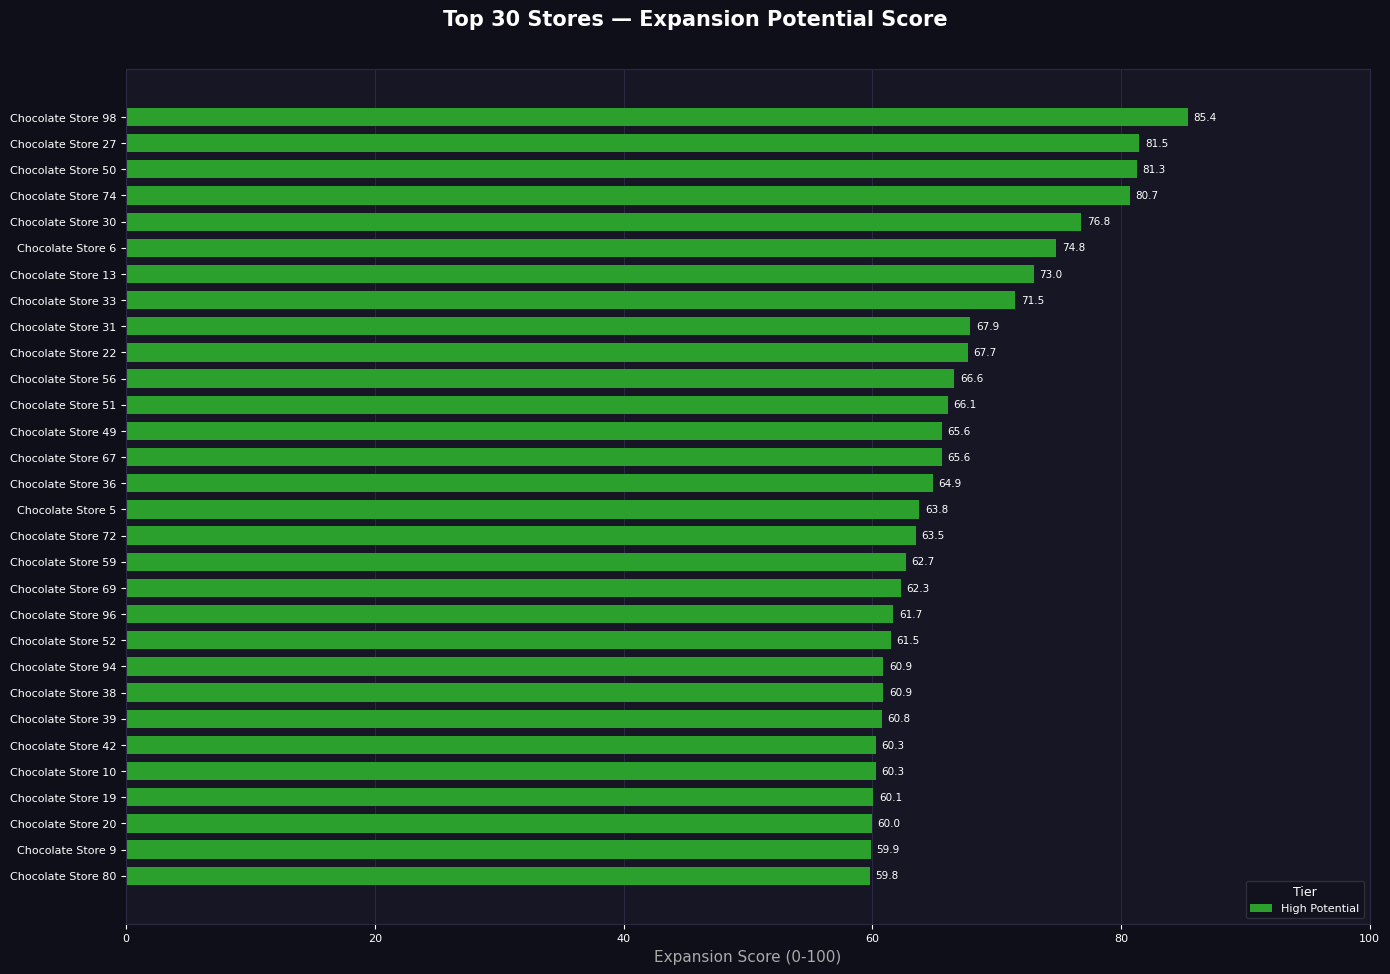


Score weights: {'growth': 0.3, 'revenue': 0.2, 'orders': 0.2, 'aov': 0.1, 'stability': 0.1, 'loyalty': 0.1}

Note: Expansion score combines predicted revenue growth (highest weight),
total revenue, order volume, average order value, and revenue stability.
Tier thresholds: High Potential >= 70th pct, Moderate >= 40th pct.


In [ ]:
# Which store locations have future expansion potential?
# Score each store across 5 signals: growth trend, revenue volume, order demand,
# average order value, and revenue stability. Tier into High / Moderate / Watch.
%pip install -q matplotlib ipympl mpld3 mplcursors
from IPython import get_ipython
import importlib
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import matplotlib.widgets as mwidgets
import mplcursors # for interactive tooltips

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        ip.run_line_magic('matplotlib', 'inline')
        print("widget backend unavailable; switched to inline backend.")

store_label_col = 'store_name' if 'store_name' in analysis_df.columns else 'store_id'
FORECAST_MONTHS = 6

# ── 1. Store-level aggregates ─────────────────────────────────────────────────
store_agg = (
    analysis_df
    .groupby(['store_id', store_label_col], as_index=False)
    .agg(
        total_revenue   = ('revenue',     'sum'),
        total_orders    = ('order_id',    'nunique'),
        total_customers = ('customer_id', 'nunique'),
        total_quantity  = ('quantity',    'sum'),
    )
)
store_agg['aov']              = store_agg['total_revenue'] / store_agg['total_orders']
store_agg['rev_per_customer'] = store_agg['total_revenue'] / store_agg['total_customers']

# ── 2. Monthly revenue CV (stability) ────────────────────────────────────────
store_monthly_rev = (
    analysis_df
    .groupby(['store_id', pd.Grouper(key='order_date', freq='MS')])['revenue']
    .sum().reset_index()
)
stability = (
    store_monthly_rev.groupby('store_id')['revenue']
    .agg(cv=lambda s: s.std() / s.mean() if s.mean() > 0 else np.nan)
    .reset_index()
)

# ── 3. Loyalty penetration ────────────────────────────────────────────────────
loyalty_col = next((c for c in analysis_df.columns if 'loyalty' in c.lower()), None)
if loyalty_col:
    loyalty_rate = (
        analysis_df.groupby('store_id')[loyalty_col]
        .apply(lambda s: (s == 1).mean() if s.dtype != object else (s.str.lower() == 'yes').mean())
        .reset_index().rename(columns={loyalty_col: 'loyalty_rate'})
    )
else:
    loyalty_rate = store_agg[['store_id']].copy()
    loyalty_rate['loyalty_rate'] = np.nan

# ── 4. Merge all signals ──────────────────────────────────────────────────────
expansion_df = (
    store_agg
    .merge(stability,    on='store_id', how='left')
    .merge(loyalty_rate, on='store_id', how='left')
    .merge(store_growth_df[['store_id', 'predicted_growth_pct', 'trend_slope']],
           on='store_id', how='left')
)

# ── 5. Rank-percentile normalisation ─────────────────────────────────────────
def rank_pct(series, ascending=True):
    r = series.rank(pct=True, na_option='bottom')
    return r if ascending else 1 - r

expansion_df['sc_growth']    = rank_pct(expansion_df['predicted_growth_pct'], ascending=True)
expansion_df['sc_revenue']   = rank_pct(expansion_df['total_revenue'],         ascending=True)
expansion_df['sc_orders']    = rank_pct(expansion_df['total_orders'],           ascending=True)
expansion_df['sc_aov']       = rank_pct(expansion_df['aov'],                   ascending=True)
expansion_df['sc_stability'] = rank_pct(expansion_df['cv'],                    ascending=False)

if expansion_df['loyalty_rate'].notna().sum() > 0:
    expansion_df['sc_loyalty'] = rank_pct(expansion_df['loyalty_rate'], ascending=True)
    WEIGHTS = dict(growth=0.30, revenue=0.20, orders=0.20, aov=0.10, stability=0.10, loyalty=0.10)
    expansion_df['expansion_score'] = (
        WEIGHTS['growth']    * expansion_df['sc_growth']    +
        WEIGHTS['revenue']   * expansion_df['sc_revenue']   +
        WEIGHTS['orders']    * expansion_df['sc_orders']    +
        WEIGHTS['aov']       * expansion_df['sc_aov']       +
        WEIGHTS['stability'] * expansion_df['sc_stability'] +
        WEIGHTS['loyalty']   * expansion_df['sc_loyalty']
    ) * 100
else:
    WEIGHTS = dict(growth=0.35, revenue=0.22, orders=0.22, aov=0.11, stability=0.10)
    expansion_df['expansion_score'] = (
        WEIGHTS['growth']    * expansion_df['sc_growth']    +
        WEIGHTS['revenue']   * expansion_df['sc_revenue']   +
        WEIGHTS['orders']    * expansion_df['sc_orders']    +
        WEIGHTS['aov']       * expansion_df['sc_aov']       +
        WEIGHTS['stability'] * expansion_df['sc_stability']
    ) * 100

# ── 6. Tier classification ────────────────────────────────────────────────────
p70 = expansion_df['expansion_score'].quantile(0.70)
p40 = expansion_df['expansion_score'].quantile(0.40)

def classify_tier(score):
    if score >= p70: return 'High Potential'
    if score >= p40: return 'Moderate Potential'
    return 'Watch & Improve'

expansion_df['expansion_tier'] = expansion_df['expansion_score'].apply(classify_tier)
expansion_df = expansion_df.sort_values('expansion_score', ascending=False).reset_index(drop=True)
expansion_df['rank'] = expansion_df.index + 1

# ── 7. Console summary ────────────────────────────────────────────────────────
tier_order  = ['High Potential', 'Moderate Potential', 'Watch & Improve']
tier_colors = {'High Potential': '#2ca02c', 'Moderate Potential': '#ff7f0e', 'Watch & Improve': '#d62728'}
tier_counts = expansion_df['expansion_tier'].value_counts().reindex(tier_order, fill_value=0)

print('=' * 90)
print('STORE EXPANSION POTENTIAL — COMPOSITE SCORE RANKING')
print('=' * 90)
print(f"{'Tier':<22}  {'Count':>5}  {'Avg Score':>10}")
print('-' * 42)
for tier in tier_order:
    cnt = tier_counts[tier]
    avg = expansion_df.loc[expansion_df['expansion_tier'] == tier, 'expansion_score'].mean()
    print(f"  {tier:<20}  {cnt:>5}  {avg:>9.1f}")

show_cols = ['rank', 'store_id', store_label_col, 'expansion_score', 'expansion_tier',
             'predicted_growth_pct', 'total_revenue', 'total_orders', 'aov', 'cv']
print('\nTop 20 stores by Expansion Score:')
print(expansion_df[show_cols].head(20).to_string(index=False, float_format=lambda v: f'{v:,.2f}'))
print('\nBottom 10 (Watch & Improve):')
print(expansion_df[show_cols].tail(10).to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

# ── matplotlib style ──────────────────────────────────────────────────────────
plt.style.use('dark_background')
BG_FC    = '#0F0F1A'
PANEL_FC = '#161625'

# Bubble size normalisation
scatter_df = expansion_df.copy()
bmin, bmax = scatter_df['total_orders'].min(), scatter_df['total_orders'].max()
brange     = bmax - bmin if bmax != bmin else 1
scatter_df['bubble_pt2'] = 40 + 300 * (scatter_df['total_orders'] - bmin) / brange

# ═══════════════════════════════════════════════════════════════════════════════
# CHART 1 — Bubble scatter: Revenue vs Growth
# ═══════════════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(14, 7), facecolor=BG_FC)
ax1.set_facecolor(PANEL_FC)
for spine in ax1.spines.values():
    spine.set_edgecolor('#2a2a45')

scatter_objects = []
for tier in tier_order:
    sub = scatter_df[scatter_df['expansion_tier'] == tier].reset_index(drop=True)
    sc  = ax1.scatter(
        sub['predicted_growth_pct'],
        sub['total_revenue'],
        s=sub['bubble_pt2'],
        c=tier_colors[tier],
        alpha=0.85,
        edgecolors='white',
        linewidths=0.5,
        label=tier,
        zorder=3,
    )
    sc._tooltip_data = sub[[
        store_label_col, 'store_id', 'expansion_score',
        'predicted_growth_pct', 'total_revenue', 'aov', 'total_orders', 'cv'
    ]].to_dict('records')
    scatter_objects.append(sc)

ax1.axvline(0, color='#888888', linewidth=1, linestyle='--')
ax1.axhline(expansion_df['total_revenue'].median(), color='#888888', linewidth=1, linestyle=':')

ax1.set_title('Store Expansion Potential: Revenue vs Growth (bubble = order volume)',
              color='white', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Predicted Revenue Growth % (Next 6M)', color='#aaaaaa', fontsize=10)
ax1.set_ylabel('Total Historical Revenue ($)',          color='#aaaaaa', fontsize=10)
ax1.tick_params(colors='white', labelsize=8)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.grid(color='#2a2a45', linewidth=0.6)
ax1.set_axisbelow(True)

legend_handles1 = [Patch(facecolor=tier_colors[t], label=t) for t in tier_order]
ax1.legend(handles=legend_handles1, title='Expansion Tier', title_fontsize=9,
           fontsize=8, framealpha=0.15, labelcolor='white')

# Tooltip — scatter
cursor1 = mplcursors.cursor(scatter_objects, hover=True, highlight=True)

@cursor1.connect("add")
def on_scatter(sel):
    row = sel.artist._tooltip_data[sel.index]
    sel.annotation.set_text(
        f"{row[store_label_col]} ({row['store_id']})\n"
        f"Growth     : {row['predicted_growth_pct']:+.2f}%\n"
        f"Revenue    : ${row['total_revenue']:,.0f}\n"
        f"Exp Score  : {row['expansion_score']:.1f}\n"
        f"AOV        : ${row['aov']:.2f}\n"
        f"Orders     : {row['total_orders']:,}\n"
        f"Revenue CV : {row['cv']:.2f}"
    )
    sel.annotation.get_bbox_patch().set(facecolor='#1a1a2e', edgecolor='#636EFA', alpha=0.92)
    sel.annotation.set_color('white')
    sel.annotation.set_fontsize(8)

fig1.tight_layout()
fig1.savefig('expansion_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG_FC)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# CHART 2 — Horizontal bar: Top 30 expansion score
# ═══════════════════════════════════════════════════════════════════════════════
bar_df  = expansion_df.head(30).sort_values('expansion_score', ascending=False).copy().reset_index(drop=True)

fig2_h  = max(8, len(bar_df) * 0.32)
fig2, ax2 = plt.subplots(figsize=(14, fig2_h), facecolor=BG_FC)
ax2.set_facecolor(PANEL_FC)
for spine in ax2.spines.values():
    spine.set_edgecolor('#2a2a45')

fig2.suptitle('Top 30 Stores — Expansion Potential Score',
              fontsize=15, fontweight='bold', color='white', y=1.01)

bar_objects = []
for tier in tier_order:
    subset = bar_df[bar_df['expansion_tier'] == tier].reset_index(drop=True)
    if subset.empty:
        continue
    bars = ax2.barh(
        subset[store_label_col].astype(str),
        subset['expansion_score'],
        color=tier_colors[tier],
        edgecolor='none',
        height=0.7,
        label=tier,
    )
    ax2.bar_label(bars,
                  labels=[f"{v:.1f}" for v in subset['expansion_score']],
                  padding=4, color='white', fontsize=7.5)
    bars._tooltip_data = subset[[
        store_label_col, 'store_id', 'expansion_score', 'expansion_tier',
        'predicted_growth_pct', 'total_revenue', 'total_orders', 'aov', 'cv'
    ]].to_dict('records')
    bar_objects.append(bars)

ax2.invert_yaxis()
ax2.set_xlim(0, 100)
ax2.set_xlabel('Expansion Score (0-100)', color='#aaaaaa', fontsize=11)
ax2.tick_params(colors='white', labelsize=8)
ax2.grid(axis='x', color='#2a2a45', linewidth=0.7)
ax2.set_axisbelow(True)

legend_handles2 = [Patch(facecolor=tier_colors[t], label=t) for t in tier_order
                   if t in bar_df['expansion_tier'].values]
ax2.legend(handles=legend_handles2, title='Tier', title_fontsize=9,
           fontsize=8, framealpha=0.15, labelcolor='white', loc='lower right')

# Tooltip — bar chart
cursor2 = mplcursors.cursor(bar_objects, hover=True, highlight=True)

@cursor2.connect("add")
def on_bar(sel):
    row = sel.artist._tooltip_data[sel.index]
    sel.annotation.set_text(
        f"{row[store_label_col]} ({row['store_id']})\n"
        f"Tier       : {row['expansion_tier']}\n"
        f"Exp Score  : {row['expansion_score']:.1f}\n"
        f"Growth     : {row['predicted_growth_pct']:+.2f}%\n"
        f"Revenue    : ${row['total_revenue']:,.0f}\n"
        f"Orders     : {row['total_orders']:,}\n"
        f"AOV        : ${row['aov']:.2f}\n"
        f"Revenue CV : {row['cv']:.2f}"
    )
    sel.annotation.get_bbox_patch().set(facecolor='#1a1a2e', edgecolor='#ff7f0e', alpha=0.92)
    sel.annotation.set_color('white')
    sel.annotation.set_fontsize(8)

fig2.tight_layout()
fig2.savefig('expansion_bar.png', dpi=150, bbox_inches='tight', facecolor=BG_FC)
plt.show()

print(f"\nScore weights: {WEIGHTS}")
print("\nNote: Expansion score combines predicted revenue growth (highest weight),")
print("total revenue, order volume, average order value, and revenue stability.")
print("Tier thresholds: High Potential >= 70th pct, Moderate >= 40th pct.")

In [161]:
%pip install matplotlib ipywidgets mplcursors

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\hetal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


STORES THAT MAY REQUIRE OPERATIONAL IMPROVEMENTS
Flagged stores: 59
(Criteria: Watch & Improve tier or negative predicted growth)

Top 20 priority stores:
 priority_rank store_id         store_name  expansion_tier  predicted_growth_pct  expansion_score  risk_score  total_revenue  total_orders   aov   cv                                                                operational_reason
             1     S045 Chocolate Store 45 Watch & Improve                 -4.99            14.10           4     250,430.30          9830 25.48 0.07 weak future growth, low revenue base, low order traffic, volatile monthly revenue
             2     S079 Chocolate Store 79 Watch & Improve                 -4.42            21.90           4     251,970.37          9904 25.44 0.07 weak future growth, low revenue base, low order traffic, volatile monthly revenue
             3     S002  Chocolate Store 2 Watch & Improve                 -2.51            22.80           4     249,737.67          9875 25.29 0.05

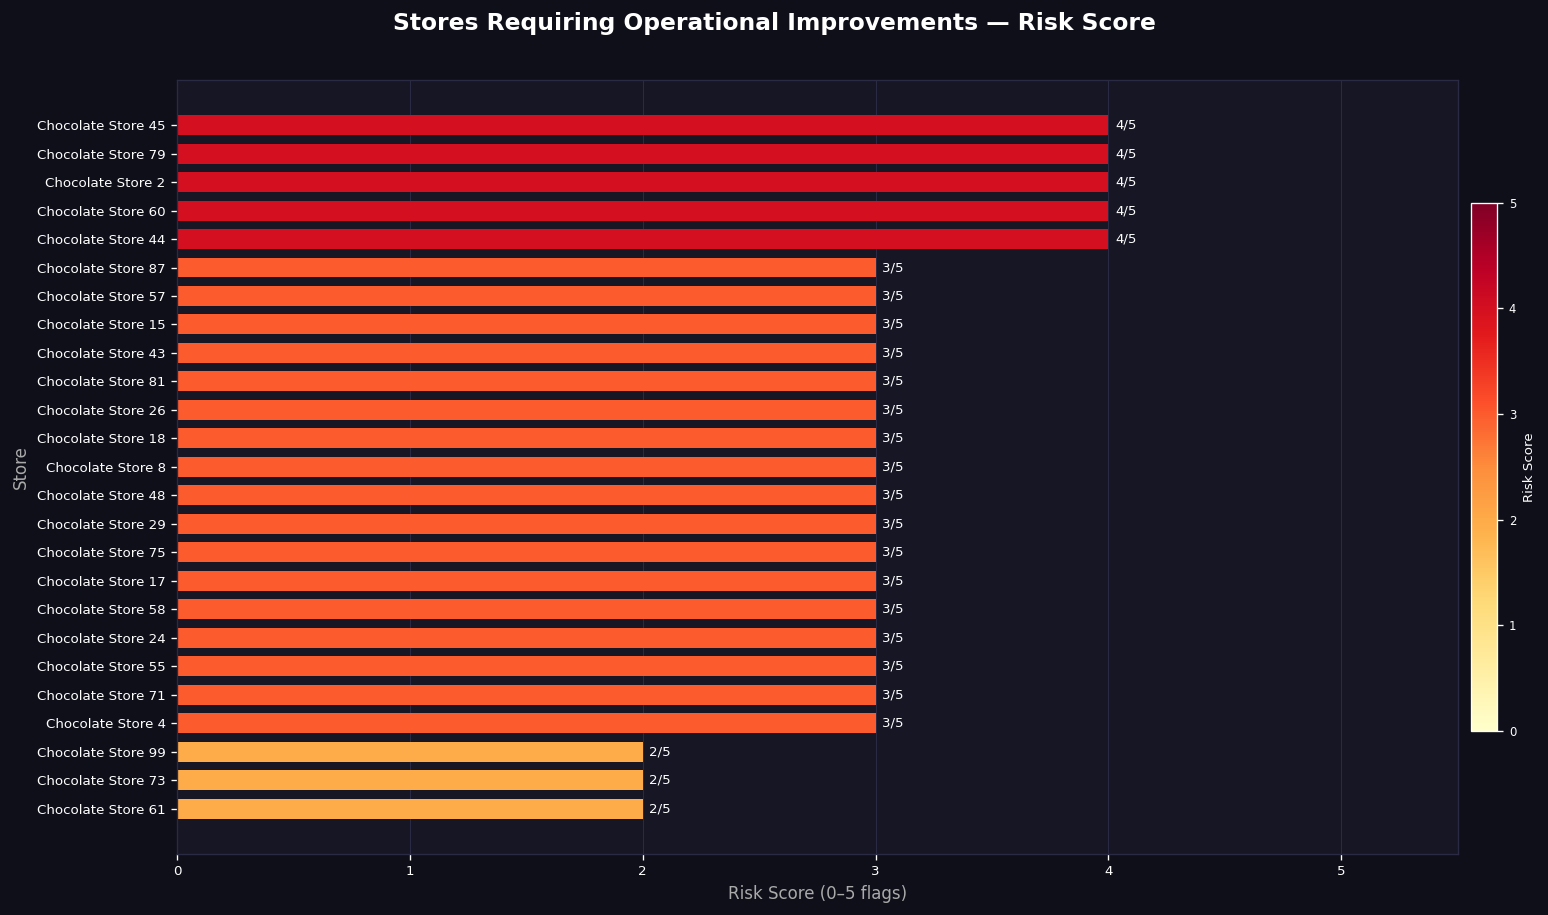

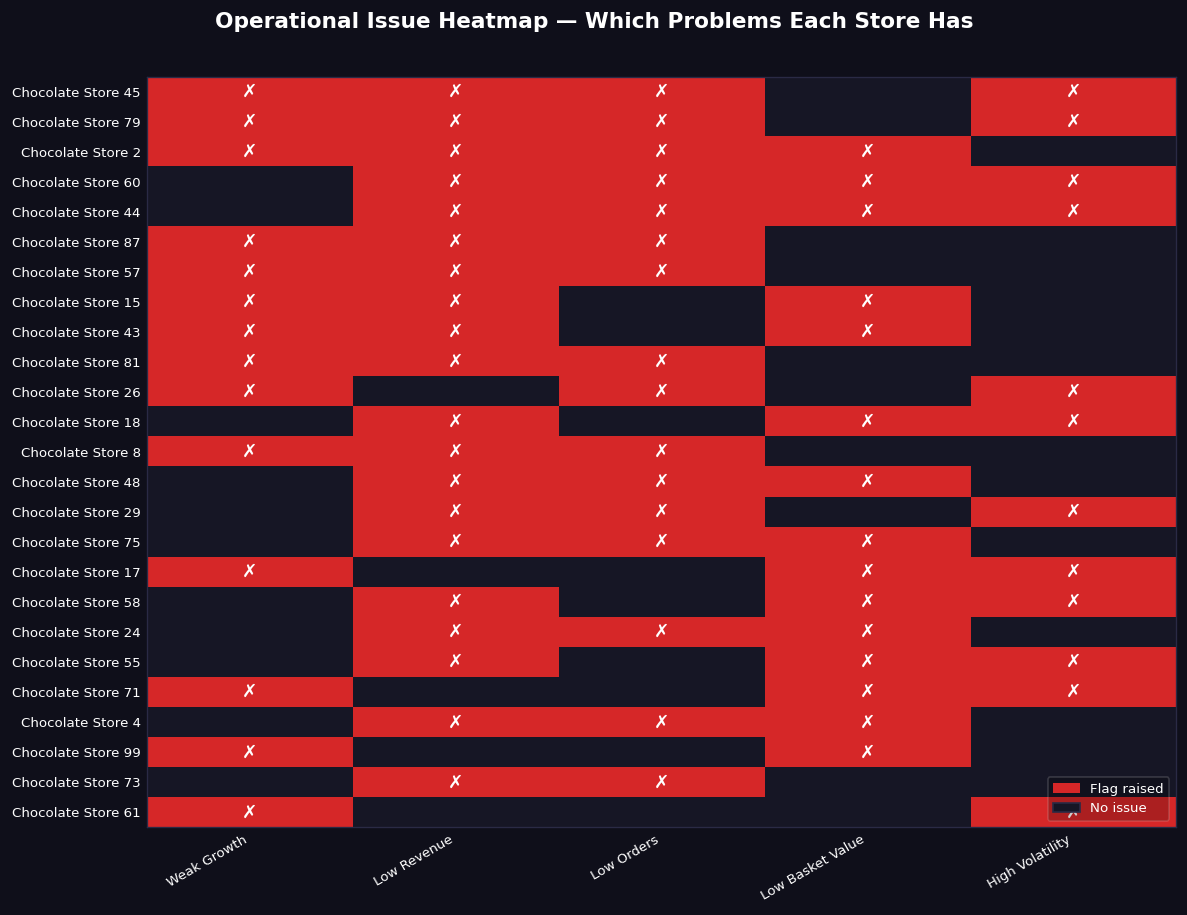

In [162]:
# Which stores may require operational improvements?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import mplcursors # for interactive tooltips

store_label_col = 'store_name' if 'store_name' in expansion_df.columns else 'store_id'

# ── Thresholds ────────────────────────────────────────────────────────────────
rev_p30    = expansion_df['total_revenue'].quantile(0.30)
orders_p30 = expansion_df['total_orders'].quantile(0.30)
aov_p30    = expansion_df['aov'].quantile(0.30)
growth_p30 = expansion_df['predicted_growth_pct'].quantile(0.30)
cv_p70     = expansion_df['cv'].quantile(0.70)

watchlist = expansion_df.copy()
watchlist['needs_ops_improvement'] = (
    (watchlist['expansion_tier'] == 'Watch & Improve') |
    (watchlist['predicted_growth_pct'] < 0)
)
watchlist = watchlist[watchlist['needs_ops_improvement']].copy()

def build_reason(row):
    reasons = []
    if row['predicted_growth_pct'] <= growth_p30:
        reasons.append('weak future growth')
    if row['total_revenue'] <= rev_p30:
        reasons.append('low revenue base')
    if row['total_orders'] <= orders_p30:
        reasons.append('low order traffic')
    if row['aov'] <= aov_p30:
        reasons.append('low basket value')
    if row['cv'] >= cv_p70:
        reasons.append('volatile monthly revenue')
    return ', '.join(reasons) if reasons else 'monitor closely'

watchlist['operational_reason'] = watchlist.apply(build_reason, axis=1)

watchlist['risk_score'] = (
    (watchlist['predicted_growth_pct'] <= growth_p30).astype(int) +
    (watchlist['total_revenue'] <= rev_p30).astype(int) +
    (watchlist['total_orders'] <= orders_p30).astype(int) +
    (watchlist['aov'] <= aov_p30).astype(int) +
    (watchlist['cv'] >= cv_p70).astype(int)
)

watchlist = watchlist.sort_values(
    ['risk_score', 'expansion_score', 'predicted_growth_pct'],
    ascending=[False, True, True]
).reset_index(drop=True)

watchlist['priority_rank'] = watchlist.index + 1

# Flag columns for heatmap
DIAG_FLAGS = {
    'Weak Growth': watchlist['predicted_growth_pct'] <= growth_p30,
    'Low Revenue': watchlist['total_revenue'] <= rev_p30,
    'Low Orders': watchlist['total_orders'] <= orders_p30,
    'Low Basket Value': watchlist['aov'] <= aov_p30,
    'High Volatility': watchlist['cv'] >= cv_p70,
}

for col, mask in DIAG_FLAGS.items():
    watchlist[col] = mask.astype(int)

cols_show = [
    'priority_rank', 'store_id', store_label_col, 'expansion_tier',
    'predicted_growth_pct', 'expansion_score', 'risk_score',
    'total_revenue', 'total_orders', 'aov', 'cv', 'operational_reason'
]

print('=' * 100)
print('STORES THAT MAY REQUIRE OPERATIONAL IMPROVEMENTS')
print('=' * 100)
print(f"Flagged stores: {len(watchlist)}")
print("(Criteria: Watch & Improve tier or negative predicted growth)")
print('\nTop 20 priority stores:')
print(watchlist[cols_show].head(20).to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

# ── matplotlib style ──────────────────────────────────────────────────────────
plt.style.use('dark_background')
BG_FC = '#0F0F1A'
PANEL_FC = '#161625'

plot_df = watchlist.head(25).copy()

# ══════════════════════════════════════════════════════════════════════════════
# CHART 1 — Risk score bar chart
# ══════════════════════════════════════════════════════════════════════════════
fig1_h = max(7, len(plot_df) * 0.30)
fig1, ax1 = plt.subplots(figsize=(13, fig1_h), facecolor=BG_FC)
ax1.set_facecolor(PANEL_FC)

for spine in ax1.spines.values():
    spine.set_edgecolor('#2a2a45')

fig1.suptitle(
    'Stores Requiring Operational Improvements — Risk Score',
    fontsize=14, fontweight='bold', color='white', y=1.01
)

risk_cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(vmin=0, vmax=5)
bar_colors = [risk_cmap(norm(v)) for v in plot_df['risk_score']]

bars = ax1.barh(
    plot_df[store_label_col].astype(str),
    plot_df['risk_score'],
    color=bar_colors,
    edgecolor='none',
    height=0.7
)

ax1.bar_label(
    bars,
    labels=[f"{v}/5" for v in plot_df['risk_score']],
    padding=4,
    color='white',
    fontsize=8
)

ax1.invert_yaxis()
ax1.set_xlim(0, 5.5)
ax1.set_xlabel('Risk Score (0–5 flags)', color='#aaaaaa', fontsize=10)
ax1.set_ylabel('Store', color='#aaaaaa', fontsize=10)
ax1.tick_params(colors='white', labelsize=8)
ax1.grid(axis='x', color='#2a2a45', linewidth=0.6)
ax1.set_axisbelow(True)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=risk_cmap, norm=norm)
sm.set_array([])
cb = fig1.colorbar(sm, ax=ax1, fraction=0.02, pad=0.01)
cb.set_label('Risk Score', color='white', fontsize=8)
cb.ax.yaxis.set_tick_params(color='white', labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

# Hover tooltip for bar chart
bar_tooltip_data = plot_df[[
    'store_id', store_label_col, 'expansion_tier', 'risk_score',
    'predicted_growth_pct', 'expansion_score', 'total_revenue',
    'total_orders', 'aov', 'cv', 'operational_reason'
]].reset_index(drop=True)

cursor1 = mplcursors.cursor(bars, hover=True)

@cursor1.connect("add")
def on_add_bar(sel):
    idx = sel.index
    row = bar_tooltip_data.iloc[idx]

    sel.annotation.set_text(
        f"{row[store_label_col]} ({row['store_id']})\n"
        f"Tier         : {row['expansion_tier']}\n"
        f"Risk Score   : {row['risk_score']}/5\n"
        f"Growth       : {row['predicted_growth_pct']:+.2f}%\n"
        f"Exp Score    : {row['expansion_score']:.1f}\n"
        f"Revenue      : ${row['total_revenue']:,.0f}\n"
        f"Orders       : {row['total_orders']:,}\n"
        f"AOV          : ${row['aov']:.2f}\n"
        f"Revenue CV   : {row['cv']:.2f}\n"
        f"Reason       : {row['operational_reason']}"
    )
    sel.annotation.get_bbox_patch().set(
        facecolor='#1a1a2e',
        edgecolor='#ff7f0e',
        alpha=0.95
    )
    sel.annotation.set_color('white')
    sel.annotation.set_fontsize(8)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# CHART 2 — Diagnostic heatmap
# ══════════════════════════════════════════════════════════════════════════════
diag_cols = list(DIAG_FLAGS.keys())
heatmap_df = plot_df.set_index(store_label_col)[diag_cols]

fig2_h = max(7, len(heatmap_df) * 0.30)
fig2, ax2 = plt.subplots(figsize=(10, fig2_h), facecolor=BG_FC)
ax2.set_facecolor(PANEL_FC)

for spine in ax2.spines.values():
    spine.set_edgecolor('#2a2a45')

fig2.suptitle(
    'Operational Issue Heatmap — Which Problems Each Store Has',
    fontsize=13, fontweight='bold', color='white', y=1.01
)

heat_cmap = mcolors.LinearSegmentedColormap.from_list(
    'risk_heat', ['#161625', '#d62728']
)

im = ax2.imshow(
    heatmap_df.values,
    cmap=heat_cmap,
    aspect='auto',
    vmin=0,
    vmax=1,
    interpolation='nearest'
)

# Cell labels
for i in range(len(heatmap_df)):
    for j in range(len(diag_cols)):
        val = heatmap_df.values[i, j]
        ax2.text(
            j, i,
            '✗' if val else '',
            ha='center',
            va='center',
            fontsize=11,
            color='white',
            fontweight='bold'
        )

ax2.set_xticks(range(len(diag_cols)))
ax2.set_xticklabels(diag_cols, rotation=30, ha='right', color='white', fontsize=8)

ax2.set_yticks(range(len(heatmap_df)))
ax2.set_yticklabels(heatmap_df.index.astype(str), color='white', fontsize=8)

ax2.tick_params(length=0)

legend_els = [
    Patch(facecolor='#d62728', label='Flag raised'),
    Patch(facecolor='#161625', edgecolor='#2a2a45', label='No issue')
]
ax2.legend(handles=legend_els, loc='lower right', fontsize=8, framealpha=0.2, labelcolor='white')

# Hover tooltip for heatmap
cursor2 = mplcursors.cursor(im, hover=True)

@cursor2.connect("add")
def on_add_heatmap(sel):
    x, y = map(int, sel.target)
    if 0 <= y < len(heatmap_df.index) and 0 <= x < len(diag_cols):
        store_name = str(heatmap_df.index[y])
        issue_name = diag_cols[x]
        flag_value = heatmap_df.iloc[y, x]

        row = plot_df.iloc[y]
        status = 'Flag raised' if flag_value == 1 else 'No issue'

        sel.annotation.set_text(
            f"{store_name} ({row['store_id']})\n"
            f"Issue        : {issue_name}\n"
            f"Status       : {status}\n"
            f"Risk Score   : {row['risk_score']}/5\n"
            f"Growth       : {row['predicted_growth_pct']:+.2f}%\n"
            f"Revenue      : ${row['total_revenue']:,.0f}\n"
            f"Orders       : {row['total_orders']:,}\n"
            f"AOV          : ${row['aov']:.2f}\n"
            f"Reason       : {row['operational_reason']}"
        )
        sel.annotation.get_bbox_patch().set(
            facecolor='#1a1a2e',
            edgecolor='#d62728',
            alpha=0.95
        )
        sel.annotation.set_color('white')
        sel.annotation.set_fontsize(8)

plt.tight_layout()
plt.show()

# Keep for downstream use
ops_improvement_stores = watchlist.copy()


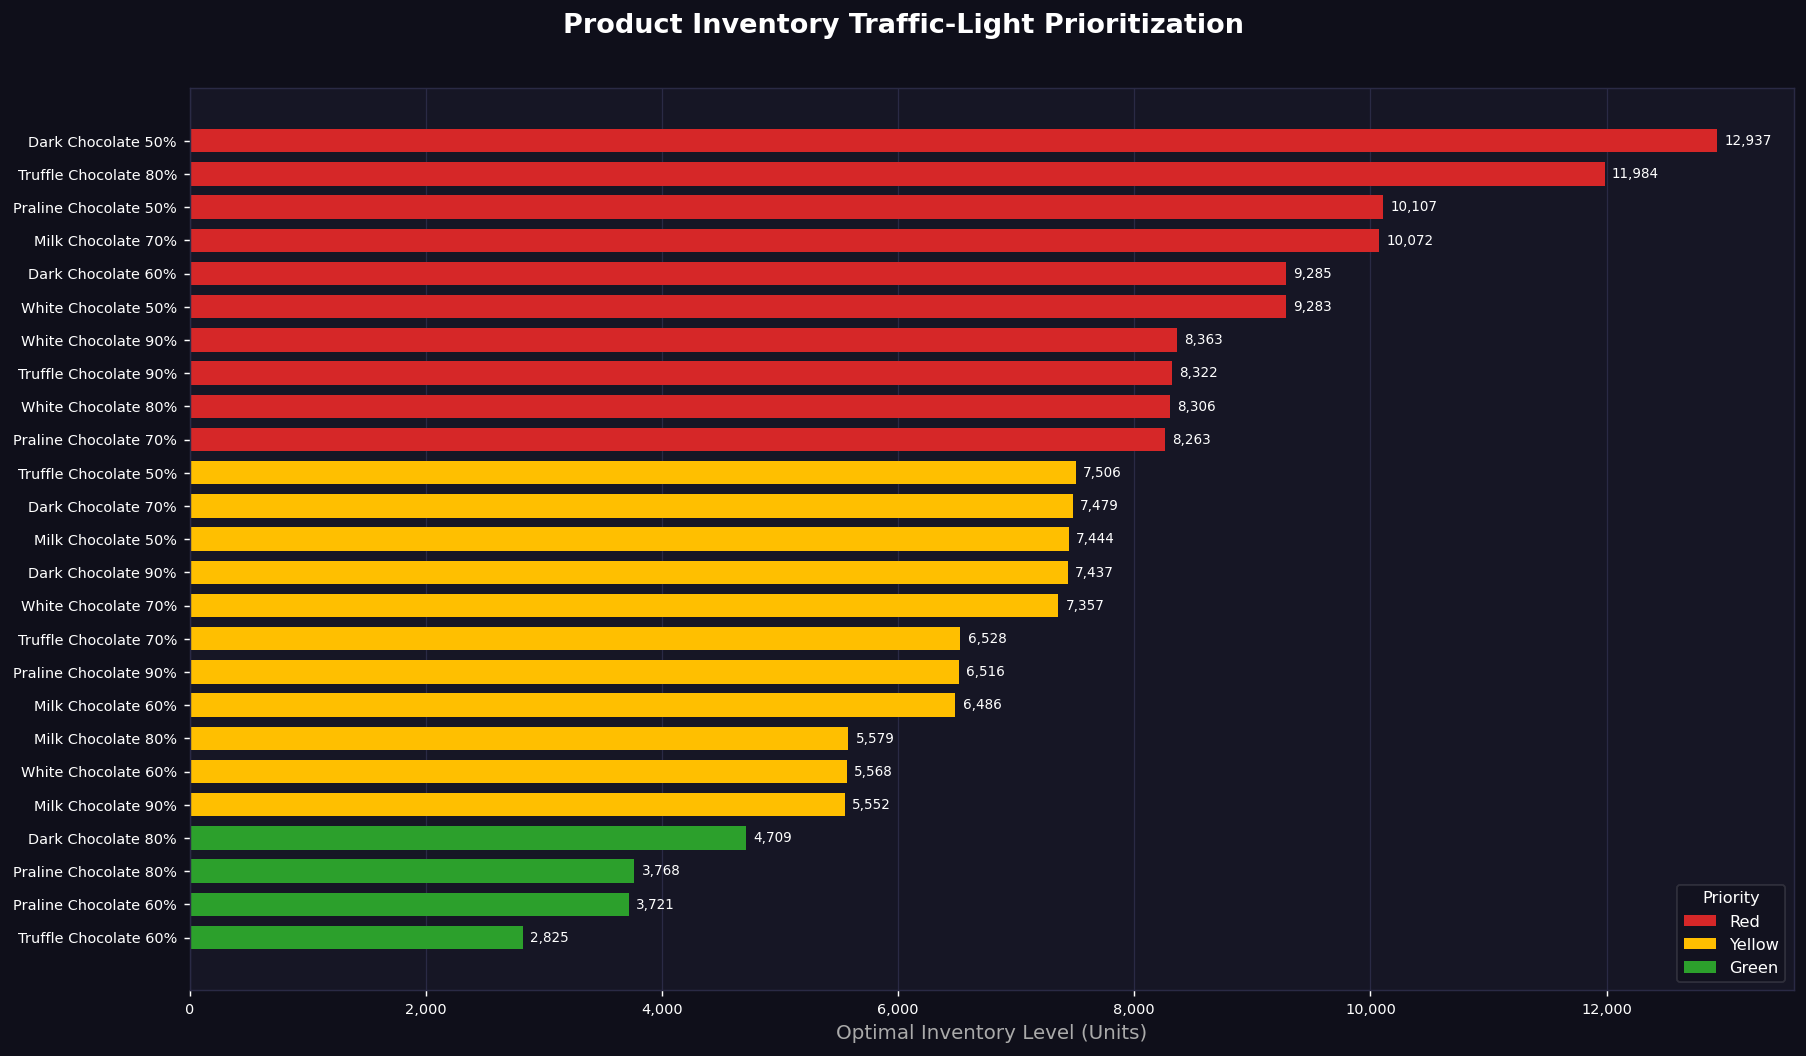

In [166]:
# ── 4. matplotlib chart ───────────────────────────────────────────────────────
import io, base64
from IPython.display import display, HTML

plt.style.use('dark_background')
BG_FC    = '#0F0F1A'
PANEL_FC = '#161625'
color_map = {'Red': '#d62728', 'Yellow': '#ffbf00', 'Green': '#2ca02c'}

plot_df = traffic_df.sort_values('optimal_inventory_level_qty', ascending=False).reset_index(drop=True)

fig_h = max(8, len(plot_df) * 0.30)
fig, ax = plt.subplots(figsize=(14, fig_h), facecolor=BG_FC)
ax.set_facecolor(PANEL_FC)
for spine in ax.spines.values():
    spine.set_edgecolor('#2a2a45')

fig.suptitle('Product Inventory Traffic-Light Prioritization',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for light in ['Red', 'Yellow', 'Green']:
    subset = plot_df[plot_df['inventory_light'] == light].reset_index(drop=True)
    if subset.empty:
        continue
    bars = ax.barh(
        subset[product_label_col].astype(str),
        subset['optimal_inventory_level_qty'],
        color=color_map[light],
        edgecolor='none', height=0.7, label=light,
    )
    ax.bar_label(bars,
                 labels=[f"{v:,}" for v in subset['optimal_inventory_level_qty']],
                 padding=4, color='white', fontsize=7.5)

ax.invert_yaxis()
ax.set_xlabel('Optimal Inventory Level (Units)', color='#aaaaaa', fontsize=11)
ax.tick_params(colors='white', labelsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(axis='x', color='#2a2a45', linewidth=0.7)
ax.set_axisbelow(True)

legend_handles = [Patch(facecolor=color_map[l], label=l) for l in ['Red', 'Yellow', 'Green']
                  if l in plot_df['inventory_light'].values]
ax.legend(handles=legend_handles, title='Priority', title_fontsize=9,
          fontsize=9, framealpha=0.15, labelcolor='white', loc='lower right')

fig.tight_layout()

# ── Force display as inline image (works in all Jupyter backends) ─────────────
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=130, bbox_inches='tight', facecolor=BG_FC)
fig.savefig('inventory_traffic_light.png', dpi=150, bbox_inches='tight', facecolor=BG_FC)
buf.seek(0)
encoded = base64.b64encode(buf.read()).decode('utf-8')
plt.close(fig)   # prevent double-render
display(HTML(f'<img src="data:image/png;base64,{encoded}" style="max-width:100%;"/>'))

# Keep for downstream use
inventory_traffic_df = traffic_df.copy()

PREDICTIVE STOCK-OUT EARLY WARNING
No on-hand stock column found; using optimal inventory level as proxy.
Snapshot date : 2024-12-31
Lead time     : 14d | Buffer: 7d | Coverage: 44d

Risk counts:
stockout_risk
Critical     0
High         0
Watch       21
Healthy      4

Top 20 products at greatest stock-out risk:
         product_name  current_stock_qty  effective_daily_demand_qty  days_to_stockout predicted_stockout_date  reorder_point_qty stockout_risk                            action
  White Chocolate 50%               9283                      231.71             40.06              2025-02-09               3028         Watch Schedule replenishment this cycle
Truffle Chocolate 60%               2825                       69.50             40.65              2025-02-09                939         Watch Schedule replenishment this cycle
Praline Chocolate 90%               6516                      158.21             41.18              2025-02-10               2137         Watch Schedul


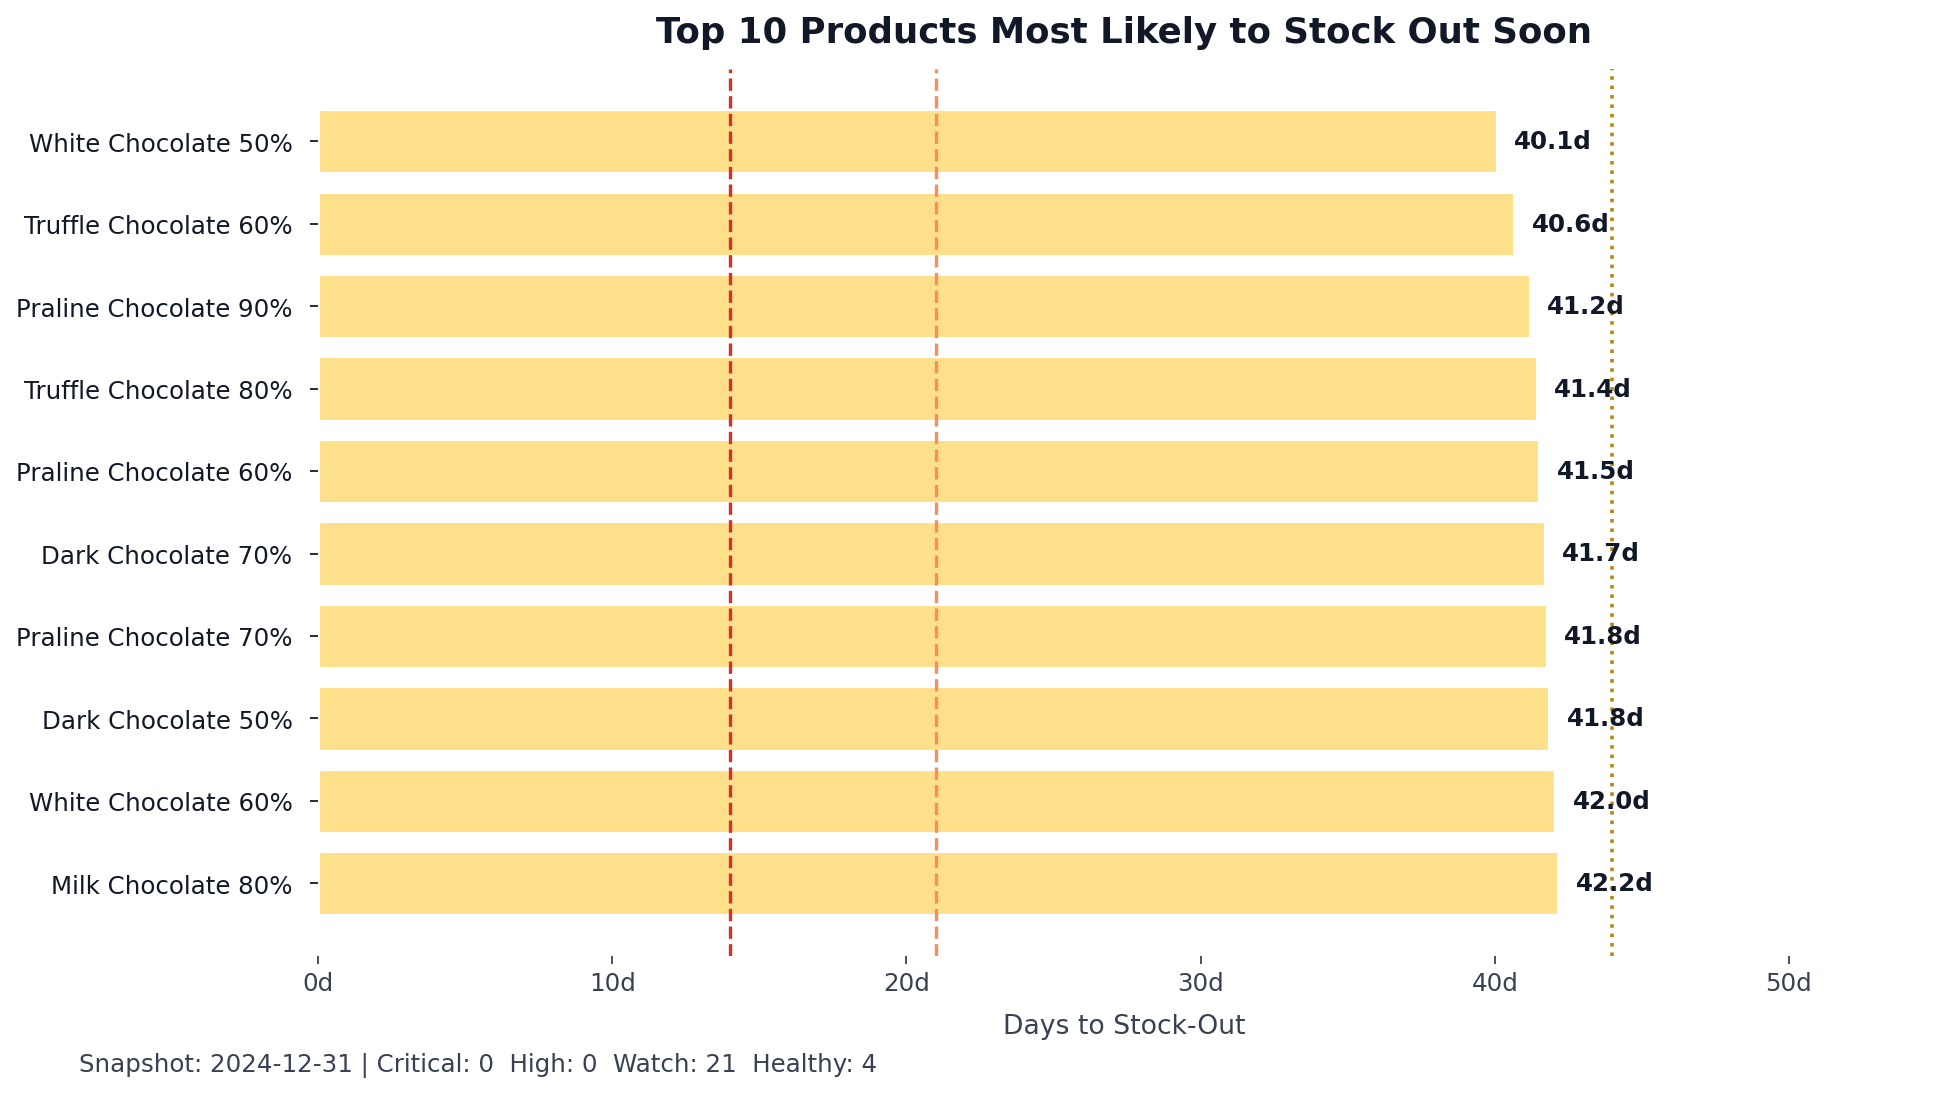

In [182]:
# Predict stock-outs before they happen (early warning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import io, base64
import textwrap
from IPython.display import display, HTML

if 'optimal_inventory_df' not in globals():
    raise ValueError('Run the inventory optimization cell first to create optimal_inventory_df.')
if 'LEAD_TIME_DAYS' not in globals():
    LEAD_TIME_DAYS = 14
if 'COVERAGE_DAYS' not in globals():
    COVERAGE_DAYS = 44
if 'product_label_col' not in globals():
    product_label_col = 'product_name' if 'product_name' in analysis_df.columns else 'product_id'

stockout_df = optimal_inventory_df.copy()
snapshot_date = analysis_df['order_date'].max().normalize()

# Resolve on-hand stock column
products_df = None
for name in ['products', 'products_clean', 'products_analysis']:
    obj = globals().get(name, None)
    if isinstance(obj, pd.DataFrame):
        products_df = obj
        break

candidate_cols = [
    'stock_on_hand', 'on_hand_qty', 'on_hand', 'inventory_qty',
    'current_stock', 'stock_qty', 'qty_on_hand'
]
on_hand_col = None
if products_df is not None:
    on_hand_col = next((c for c in products_df.columns if c.lower() in candidate_cols), None)

if on_hand_col is not None and product_label_col in products_df.columns:
    on_hand_map = products_df[[product_label_col, on_hand_col]].drop_duplicates(subset=[product_label_col])
    stockout_df = stockout_df.merge(on_hand_map, on=product_label_col, how='left')
    stockout_df['current_stock_qty'] = stockout_df[on_hand_col].fillna(stockout_df['optimal_inventory_level_qty'])
    stock_basis_note = f"Using product master column '{on_hand_col}' as current stock."
else:
    stockout_df['current_stock_qty'] = stockout_df['optimal_inventory_level_qty']
    stock_basis_note = 'No on-hand stock column found; using optimal inventory level as proxy.'

# Recent demand burst (last 14 days)
recent_days = 14
recent_cutoff = analysis_df['order_date'].max() - pd.Timedelta(days=recent_days)
recent_daily = (
    analysis_df[analysis_df['order_date'] >= recent_cutoff]
    .groupby(product_label_col)['quantity']
    .sum()
    .div(recent_days)
    .rename('recent_daily_demand_qty')
    .reset_index()
)
stockout_df = stockout_df.merge(recent_daily, on=product_label_col, how='left')
stockout_df['recent_daily_demand_qty'] = stockout_df['recent_daily_demand_qty'].fillna(stockout_df['avg_daily_demand_qty'])

# Conservative demand assumption
stockout_df['effective_daily_demand_qty'] = (
    stockout_df[['avg_daily_demand_qty', 'recent_daily_demand_qty']].max(axis=1).clip(lower=0.01)
)
stockout_df['days_to_stockout'] = stockout_df['current_stock_qty'] / stockout_df['effective_daily_demand_qty']
stockout_df['predicted_stockout_date'] = (
    snapshot_date + pd.to_timedelta(np.floor(stockout_df['days_to_stockout']), unit='D')
)

# Risk tiers
buffer_days = 7
stockout_df['stockout_risk'] = np.select(
    [
        stockout_df['days_to_stockout'] <= LEAD_TIME_DAYS,
        stockout_df['days_to_stockout'] <= (LEAD_TIME_DAYS + buffer_days),
        stockout_df['days_to_stockout'] <= COVERAGE_DAYS,
    ],
    ['Critical', 'High', 'Watch'],
    default='Healthy'
)
stockout_df['action'] = stockout_df['stockout_risk'].map({
    'Critical': 'Place emergency replenishment now',
    'High': 'Expedite reorder in next 24-48h',
    'Watch': 'Schedule replenishment this cycle',
    'Healthy': 'Continue normal monitoring',
})
risk_order = ['Critical', 'High', 'Watch', 'Healthy']
stockout_df['stockout_risk'] = pd.Categorical(stockout_df['stockout_risk'], categories=risk_order, ordered=True)
stockout_df = stockout_df.sort_values(['stockout_risk', 'days_to_stockout']).reset_index(drop=True)

# Print summary
print('=' * 96)
print('PREDICTIVE STOCK-OUT EARLY WARNING')
print('=' * 96)
print(stock_basis_note)
print(f'Snapshot date : {snapshot_date.date()}')
print(f'Lead time     : {LEAD_TIME_DAYS}d | Buffer: {buffer_days}d | Coverage: {COVERAGE_DAYS}d')
print('\nRisk counts:')
print(stockout_df['stockout_risk'].value_counts().reindex(risk_order, fill_value=0).to_string())
print('\nTop 20 products at greatest stock-out risk:')
print(
    stockout_df[[
        product_label_col, 'current_stock_qty', 'effective_daily_demand_qty',
        'days_to_stockout', 'predicted_stockout_date',
        'reorder_point_qty', 'stockout_risk', 'action',
    ]].head(20).to_string(index=False, float_format=lambda v: f'{v:,.2f}')
)

# Clear and readable chart (presentation style)
risk_colors = {
    'Critical': '#D73027',
    'High': '#FC8D59',
    'Watch': '#FEE08B',
    'Healthy': '#1A9850',
}

top_n = 10
plot_df = stockout_df.head(top_n).copy().sort_values('days_to_stockout', ascending=True)
plot_df['label'] = plot_df[product_label_col].astype(str).map(lambda s: '\n'.join(textwrap.wrap(s, width=24)))
risk_counts = stockout_df['stockout_risk'].value_counts().reindex(risk_order, fill_value=0)

fig, ax = plt.subplots(figsize=(13, 7.2), facecolor='white')
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_visible(False)

bars = ax.barh(
    plot_df['label'],
    plot_df['days_to_stockout'],
    color=[risk_colors[r] for r in plot_df['stockout_risk']],
    edgecolor='white',
    linewidth=1.4,
    height=0.78,
)

for bar, row in zip(bars, plot_df.itertuples(index=False)):
    ax.text(
        bar.get_width() + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f"{row.days_to_stockout:.1f}d",
        va='center',
        ha='left',
        fontsize=11,
        color='#111827',
        fontweight='bold',
    )

# Minimal thresholds
ax.axvline(LEAD_TIME_DAYS, color='#D73027', linestyle='--', linewidth=1.5)
ax.axvline(LEAD_TIME_DAYS + buffer_days, color='#FC8D59', linestyle='--', linewidth=1.5)
ax.axvline(COVERAGE_DAYS, color='#B8860B', linestyle=':', linewidth=1.6)

ax.set_title('Top 10 Products Most Likely to Stock Out Soon', fontsize=16, fontweight='bold', color='#111827', pad=12)
ax.set_xlabel('Days to Stock-Out', fontsize=12, color='#374151', labelpad=8)
ax.tick_params(axis='y', labelsize=11, colors='#111827', pad=8)
ax.tick_params(axis='x', labelsize=11, colors='#374151')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}d'))
ax.grid(False)
ax.invert_yaxis()
ax.set_xlim(0, max(plot_df['days_to_stockout'].max() * 1.30, COVERAGE_DAYS * 1.06))

subtitle = (
    f"Snapshot: {snapshot_date.date()} | Critical: {int(risk_counts['Critical'])}  "
    f"High: {int(risk_counts['High'])}  Watch: {int(risk_counts['Watch'])}  Healthy: {int(risk_counts['Healthy'])}"
)
fig.text(0.01, 0.01, subtitle, fontsize=11, color='#374151')

fig.savefig('stockout_early_warning.png', dpi=190, bbox_inches='tight', facecolor='white')

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=160, bbox_inches='tight', facecolor='white')
buf.seek(0)
encoded = base64.b64encode(buf.read()).decode('utf-8')
plt.close(fig)
display(HTML(f'<img src="data:image/png;base64,{encoded}" style="max-width:100%;"/>'))

stockout_prediction_df = stockout_df.copy()

In [ ]:
# Inventory targets to meet future demand (concise table)
if 'optimal_inventory_df' not in globals():
    raise ValueError('Run the optimal inventory cell first.')

name_col = 'product_name' if 'product_name' in optimal_inventory_df.columns else optimal_inventory_df.columns[0]
inv_table = (
    optimal_inventory_df[[name_col, 'optimal_inventory_level_qty', 'reorder_point_qty']]
    .sort_values('optimal_inventory_level_qty', ascending=False)
    .reset_index(drop=True)
 )

print('Recommended inventory by product:')
print(inv_table.to_string(index=False))
print('\nTotal optimal inventory units across products:', int(inv_table['optimal_inventory_level_qty'].sum()))

Recommended inventory by product:
         product_name  optimal_inventory_level_qty  reorder_point_qty
   Dark Chocolate 50%                        12937               4205
Truffle Chocolate 80%                        11984               3897
Praline Chocolate 50%                        10107               3294
   Milk Chocolate 70%                        10072               3279
   Dark Chocolate 60%                         9285               3027
  White Chocolate 50%                         9283               3028
  White Chocolate 90%                         8363               2731
Truffle Chocolate 90%                         8322               2716
  White Chocolate 80%                         8306               2715
Praline Chocolate 70%                         8263               2699
Truffle Chocolate 50%                         7506               2457
   Dark Chocolate 70%                         7479               2445
   Milk Chocolate 50%                         7444      

CUSTOMER SEGMENTATION
Total customers: 50,000

Thresholds used:
- Frequent Buyers: total_orders >= 23 (75th percentile)
- High Spenders  : total_spend >= 596.37 (75th percentile)
- Low Spenders   : total_spend <= 415.34 (25th percentile)

Segment mix:
- Frequent Buyers :  13826 customers (27.65%)
- High Spenders   :   3124 customers ( 6.25%)
- Mid Spenders    :  20602 customers (41.20%)
- Low Spenders    :  12448 customers (24.90%)

Sample customer segmentation table (top 25 by spend):
customer_id  total_spend  total_orders  total_quantity customer_segment
    C033309     1,183.16            39             125  Frequent Buyers
    C009919     1,153.66            38             128  Frequent Buyers
    C044802     1,123.37            34             115  Frequent Buyers
    C024448     1,111.54            32             113  Frequent Buyers
    C026507     1,104.10            37             119  Frequent Buyers
    C020498     1,100.16            35             117  Frequent Buyers
    C

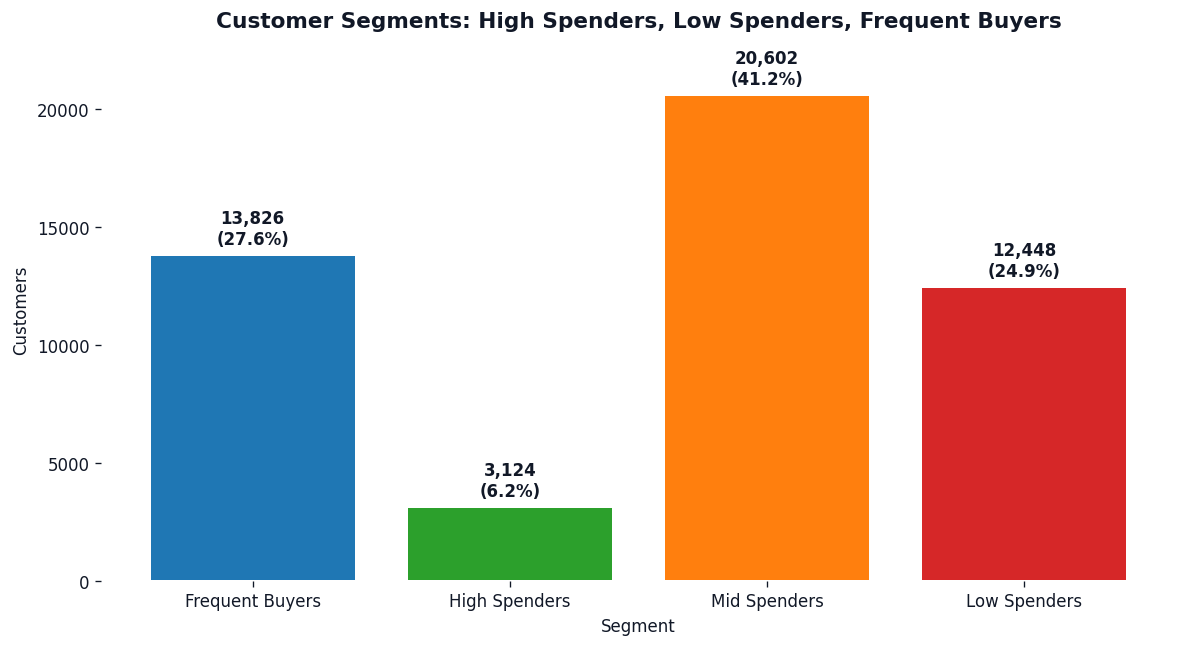

In [185]:
# Group customers into segments: high spenders, low spenders, frequent buyers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

customer_col = 'customer_id' if 'customer_id' in analysis_df.columns else 'cust_id'
if customer_col not in analysis_df.columns:
    raise ValueError('Customer ID column not found in analysis_df.')

cust_seg_df = (
    analysis_df.groupby(customer_col, as_index=False)
    .agg(
        total_spend=('revenue', 'sum'),
        total_orders=('order_id', 'nunique'),
        total_quantity=('quantity', 'sum'),
        last_purchase=('order_date', 'max')
    )
)

# Percentile thresholds
spend_p75 = cust_seg_df['total_spend'].quantile(0.75)
spend_p25 = cust_seg_df['total_spend'].quantile(0.25)
orders_p75 = cust_seg_df['total_orders'].quantile(0.75)

# Priority rule to keep one primary segment per customer
def assign_segment(row):
    if row['total_orders'] >= orders_p75:
        return 'Frequent Buyers'
    if row['total_spend'] >= spend_p75:
        return 'High Spenders'
    if row['total_spend'] <= spend_p25:
        return 'Low Spenders'
    return 'Mid Spenders'

cust_seg_df['customer_segment'] = cust_seg_df.apply(assign_segment, axis=1)

segment_order = ['Frequent Buyers', 'High Spenders', 'Mid Spenders', 'Low Spenders']
cust_seg_df['customer_segment'] = pd.Categorical(
    cust_seg_df['customer_segment'],
    categories=segment_order,
    ordered=True
)

segment_counts = cust_seg_df['customer_segment'].value_counts().reindex(segment_order, fill_value=0)
segment_share = (segment_counts / len(cust_seg_df) * 100).round(2)

print('=' * 90)
print('CUSTOMER SEGMENTATION')
print('=' * 90)
print(f'Total customers: {len(cust_seg_df):,}')
print('\nThresholds used:')
print(f'- Frequent Buyers: total_orders >= {orders_p75:.0f} (75th percentile)')
print(f'- High Spenders  : total_spend >= {spend_p75:,.2f} (75th percentile)')
print(f'- Low Spenders   : total_spend <= {spend_p25:,.2f} (25th percentile)')

print('\nSegment mix:')
for seg in segment_order:
    print(f'- {seg:<16}: {int(segment_counts[seg]):>6} customers ({segment_share[seg]:>5.2f}%)')

print('\nSample customer segmentation table (top 25 by spend):')
print(
    cust_seg_df.sort_values('total_spend', ascending=False)
    [[customer_col, 'total_spend', 'total_orders', 'total_quantity', 'customer_segment']]
    .head(25)
    .to_string(index=False, float_format=lambda v: f'{v:,.2f}')
)

seg_plot_df = segment_counts.reset_index()
seg_plot_df.columns = ['Segment', 'Customers']

# Matplotlib chart
colors = {
    'Frequent Buyers': '#1f77b4',
    'High Spenders': '#2ca02c',
    'Mid Spenders': '#ff7f0e',
    'Low Spenders': '#d62728'
}

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='white')
ax.set_facecolor('white')

bars = ax.bar(
    seg_plot_df['Segment'],
    seg_plot_df['Customers'],
    color=[colors[s] for s in seg_plot_df['Segment']],
    edgecolor='white',
    linewidth=1.2
 )

max_count = seg_plot_df['Customers'].max()
label_offset = max_count * 0.015

for bar, seg in zip(bars, seg_plot_df['Segment']):
    value = int(bar.get_height())
    pct = segment_share[seg]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_offset,
        f'{value:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#111827'
    )

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Customer Segments: High Spenders, Low Spenders, Frequent Buyers', fontsize=13, fontweight='bold', color='#111827')
ax.set_xlabel('Segment', color='#111827')
ax.set_ylabel('Customers', color='#111827')
ax.set_ylim(0, max_count * 1.12)
ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(axis='x', colors='#111827', labelsize=10)
ax.tick_params(axis='y', colors='#111827', labelsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Keep for downstream use
customer_segments_df = cust_seg_df.copy()

In [ ]:
# Which segment contributes the most revenue?
if 'customer_segments_df' not in globals():
    raise ValueError('Run the customer segmentation cell first.')

segment_revenue = (
    customer_segments_df
    .groupby('customer_segment', as_index=False)['total_spend']
    .sum()
    .rename(columns={'total_spend': 'segment_revenue'})
    .sort_values('segment_revenue', ascending=False)
    .reset_index(drop=True)
 )
segment_revenue['revenue_share_pct'] = (
    segment_revenue['segment_revenue'] / segment_revenue['segment_revenue'].sum() * 100
 ).round(2)

top_seg = segment_revenue.iloc[0]
print(f"Top revenue-contributing segment: {top_seg['customer_segment']}")
print(f"Revenue: ${top_seg['segment_revenue']:,.2f} ({top_seg['revenue_share_pct']:.2f}% of total)")

print('\nSegment revenue contribution:')
print(segment_revenue.to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

Top revenue-contributing segment: Mid Spenders
Revenue: $10,204,866.18 (40.04% of total)

Segment revenue contribution:
customer_segment  segment_revenue  revenue_share_pct
    Mid Spenders    10,204,866.18              40.04
 Frequent Buyers     8,982,701.43              35.25
    Low Spenders     4,296,904.84              16.86
   High Spenders     2,001,656.41               7.85


FUTURE SEGMENT BEHAVIOR OUTLOOK (NEXT 6 MONTHS)
customer_segment  recent_3m_avg_revenue  forecast_6m_avg_monthly_revenue  forecast_6m_total_revenue  predicted_revenue_growth_pct  recent_3m_avg_orders  forecast_6m_avg_monthly_orders  predicted_orders_growth_pct        future_behavior_outlook
    Mid Spenders             425,757.81                       427,769.15               2,566,614.88                          0.47             16,423.00                       16,468.52                         0.28 Likely steady to modest growth
 Frequent Buyers             376,169.54                       377,574.28               2,265,445.67                          0.37             14,803.67                       14,841.26                         0.25 Likely steady to modest growth
    Low Spenders             178,407.38                       178,236.79               1,069,420.73                         -0.10              7,920.00                        7,894.96                        -0.32        

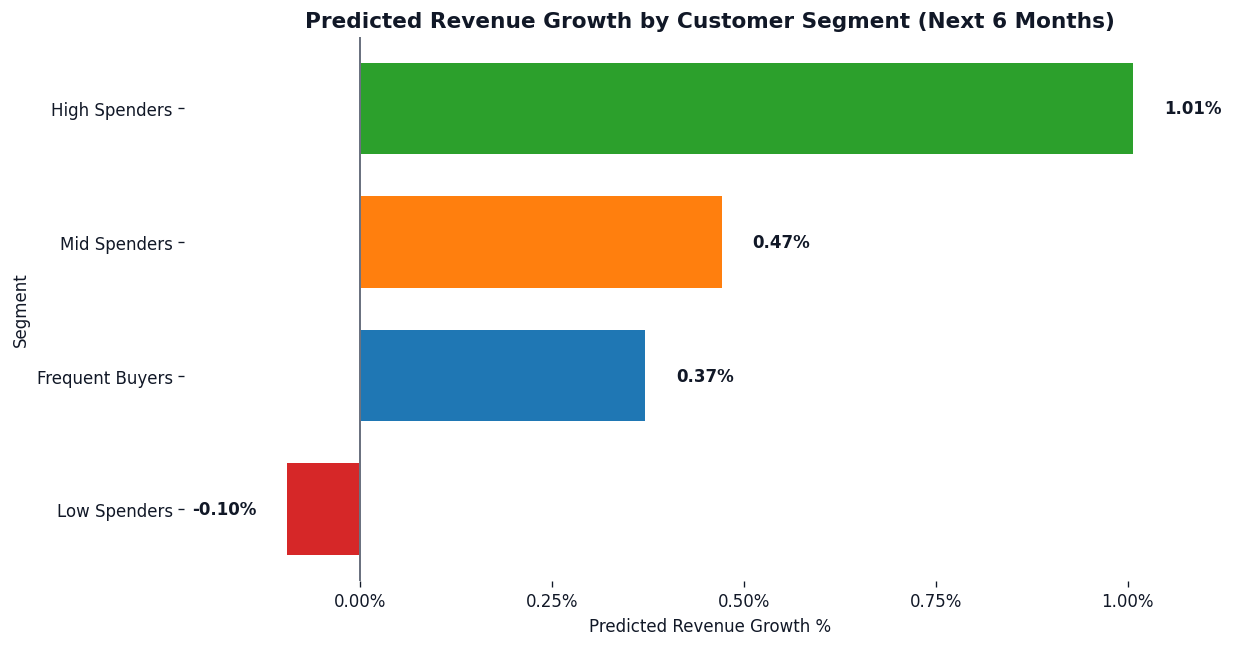

In [187]:
# How will each segment behave in the future?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if 'customer_segments_df' not in globals():
    raise ValueError('Run the customer segmentation cell first.')

customer_col = 'customer_id' if 'customer_id' in analysis_df.columns else 'cust_id'
if customer_col not in analysis_df.columns or customer_col not in customer_segments_df.columns:
    raise ValueError('Customer key not aligned between analysis_df and customer_segments_df.')

segment_map = customer_segments_df[[customer_col, 'customer_segment']].copy()
seg_txn = analysis_df.merge(segment_map, on=customer_col, how='left')
seg_txn = seg_txn.dropna(subset=['customer_segment']).copy()

# Monthly segment performance
seg_monthly = (
    seg_txn.groupby(['customer_segment', pd.Grouper(key='order_date', freq='MS')], as_index=False)
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique')
    )
    .rename(columns={'order_date': 'month'})
 )

all_months = pd.date_range(seg_monthly['month'].min(), seg_monthly['month'].max(), freq='MS')
forecast_horizon = 6
rows = []

for seg in seg_monthly['customer_segment'].dropna().unique():
    g = seg_monthly[seg_monthly['customer_segment'] == seg].set_index('month').reindex(all_months, fill_value=0).sort_index()

    # Revenue trend
    x = np.arange(len(g))
    y_rev = g['revenue'].values.astype(float)
    rev_slope, rev_intercept = np.polyfit(x, y_rev, 1)
    future_x = np.arange(len(g), len(g) + forecast_horizon)
    rev_forecast = np.maximum(rev_intercept + rev_slope * future_x, 0)

    # Orders trend
    y_ord = g['orders'].values.astype(float)
    ord_slope, ord_intercept = np.polyfit(x, y_ord, 1)
    ord_forecast = np.maximum(ord_intercept + ord_slope * future_x, 0)

    recent_3m_rev = g['revenue'].tail(3).mean()
    future_6m_avg_rev = rev_forecast.mean()
    rev_growth_pct = ((future_6m_avg_rev - recent_3m_rev) / recent_3m_rev * 100) if recent_3m_rev > 0 else np.nan

    recent_3m_ord = g['orders'].tail(3).mean()
    future_6m_avg_ord = ord_forecast.mean()
    ord_growth_pct = ((future_6m_avg_ord - recent_3m_ord) / recent_3m_ord * 100) if recent_3m_ord > 0 else np.nan

    if rev_growth_pct >= 5 and ord_growth_pct >= 3:
        behavior = 'Likely to expand strongly'
    elif rev_growth_pct >= 0 and ord_growth_pct >= 0:
        behavior = 'Likely steady to modest growth'
    elif rev_growth_pct < 0 and ord_growth_pct < 0:
        behavior = 'Likely softening demand'
    else:
        behavior = 'Mixed signals, monitor closely'

    rows.append({
        'customer_segment': seg,
        'recent_3m_avg_revenue': recent_3m_rev,
        'forecast_6m_avg_monthly_revenue': future_6m_avg_rev,
        'forecast_6m_total_revenue': rev_forecast.sum(),
        'predicted_revenue_growth_pct': rev_growth_pct,
        'recent_3m_avg_orders': recent_3m_ord,
        'forecast_6m_avg_monthly_orders': future_6m_avg_ord,
        'predicted_orders_growth_pct': ord_growth_pct,
        'future_behavior_outlook': behavior,
    })

segment_future_df = pd.DataFrame(rows).sort_values('forecast_6m_total_revenue', ascending=False).reset_index(drop=True)

print('=' * 110)
print('FUTURE SEGMENT BEHAVIOR OUTLOOK (NEXT 6 MONTHS)')
print('=' * 110)
print(segment_future_df.to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

print('\nPlain-English outlook:')
for _, r in segment_future_df.iterrows():
    print(
        f"- {r['customer_segment']}: {r['future_behavior_outlook']} "
        f"(Revenue growth: {r['predicted_revenue_growth_pct']:.2f}%, Orders growth: {r['predicted_orders_growth_pct']:.2f}%)"
    )

# Visual: predicted revenue growth by segment (Matplotlib)
plot_df = segment_future_df.sort_values('predicted_revenue_growth_pct', ascending=True).copy()
color_map = {
    'Frequent Buyers': '#1f77b4',
    'High Spenders': '#2ca02c',
    'Mid Spenders': '#ff7f0e',
    'Low Spenders': '#d62728'
}

fig, ax = plt.subplots(figsize=(10.5, 5.5), facecolor='white')
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_visible(False)

bars = ax.barh(
    plot_df['customer_segment'],
    plot_df['predicted_revenue_growth_pct'],
    color=[color_map.get(s, '#7f7f7f') for s in plot_df['customer_segment']],
    edgecolor='white',
    linewidth=1.2,
    height=0.7
)

x_min = float(plot_df['predicted_revenue_growth_pct'].min())
x_max = float(plot_df['predicted_revenue_growth_pct'].max())
span = max(x_max - x_min, 0.2)
offset = span * 0.035

for bar, val in zip(bars, plot_df['predicted_revenue_growth_pct']):
    ax.text(
        bar.get_width() + (offset if val >= 0 else -offset),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=10,
        fontweight='bold',
        color='#111827'
    )

ax.axvline(0, color='#6b7280', linewidth=1.2)
ax.set_title('Predicted Revenue Growth by Customer Segment (Next 6 Months)', fontsize=13, fontweight='bold', color='#111827')
ax.set_xlabel('Predicted Revenue Growth %', color='#111827')
ax.set_ylabel('Segment', color='#111827')
ax.tick_params(axis='x', colors='#111827', labelsize=10)
ax.tick_params(axis='y', colors='#111827', labelsize=10)
pad = span * 0.12
ax.set_xlim(x_min - pad, x_max + pad)
ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}%'))
ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [189]:
# How will sales vary by day, week, or month in future? (combined outlook)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
plt.style.use('default')

# --- 1) Daily expected pattern (uses historical weekday profile as forward baseline)
day_col = 'day_of_week' if 'day_of_week' in analysis_df.columns else None
if day_col is None:
    raise ValueError('day_of_week column not found in analysis_df.')

daily_future_profile = (
    analysis_df.groupby(day_col, as_index=False)['revenue']
    .mean()
    .rename(columns={'revenue': 'expected_daily_revenue'})
    .sort_values(day_col)
 )

weekday_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday', 7: 'Sunday'}
daily_future_profile['weekday'] = daily_future_profile[day_col].map(weekday_map).fillna('Unknown')

# --- 2) Weekly forecast (next 8 weeks)
weekly_hist = (
    analysis_df.groupby(pd.Grouper(key='order_date', freq='W-MON'))['revenue']
    .sum()
    .sort_index()
 )
if len(weekly_hist) < 8:
    raise ValueError('Need at least 8 weeks of data for weekly forecast.')

xw = np.arange(len(weekly_hist))
yw = weekly_hist.values
slope_w, intercept_w = np.polyfit(xw, yw, 1)
future_weeks = 8
future_xw = np.arange(len(weekly_hist), len(weekly_hist) + future_weeks)
future_week_dates = pd.date_range(weekly_hist.index[-1] + pd.Timedelta(days=7), periods=future_weeks, freq='W-MON')
weekly_future_df = pd.DataFrame({
    'week_start': future_week_dates,
    'forecast_weekly_revenue': np.maximum(intercept_w + slope_w * future_xw, 0)
})

# --- 3) Monthly forecast (next 6 months)
monthly_hist = (
    analysis_df.groupby(pd.Grouper(key='order_date', freq='MS'))['revenue']
    .sum()
    .sort_index()
 )
if len(monthly_hist) < 6:
    raise ValueError('Need at least 6 months of data for monthly forecast.')

xm = np.arange(len(monthly_hist))
ym = monthly_hist.values
slope_m, intercept_m = np.polyfit(xm, ym, 1)
future_months = 6
future_xm = np.arange(len(monthly_hist), len(monthly_hist) + future_months)
future_month_dates = pd.date_range(monthly_hist.index[-1] + pd.offsets.MonthBegin(1), periods=future_months, freq='MS')
monthly_future_df = pd.DataFrame({
    'month_start': future_month_dates,
    'forecast_monthly_revenue': np.maximum(intercept_m + slope_m * future_xm, 0)
})

# Keep outputs for downstream use
daily_future_profile_df = daily_future_profile.copy()
weekly_future_sales_df = weekly_future_df.copy()
monthly_future_sales_df = monthly_future_df.copy()

print('Prepared daily, weekly, and monthly outlook data. Run the next two cells for summary and chart.')

Prepared daily, weekly, and monthly outlook data. Run the next two cells for summary and chart.


In [190]:
# --- 4) Summary print
top_day = daily_future_profile.loc[daily_future_profile['expected_daily_revenue'].idxmax()]
low_day = daily_future_profile.loc[daily_future_profile['expected_daily_revenue'].idxmin()]
weekly_trend = 'upward' if slope_w > 0 else 'downward' if slope_w < 0 else 'flat'
monthly_trend = 'upward' if slope_m > 0 else 'downward' if slope_m < 0 else 'flat'

print('=' * 100)
print('FUTURE SALES VARIATION OUTLOOK: DAY vs WEEK vs MONTH')
print('=' * 100)
print(f"Day pattern   : highest expected = {top_day['weekday']} (${top_day['expected_daily_revenue']:,.2f}), lowest = {low_day['weekday']} (${low_day['expected_daily_revenue']:,.2f})")
print(f"Week trend    : {weekly_trend} | forecast next 4 weeks = ${weekly_future_df['forecast_weekly_revenue'].head(4).sum():,.2f} | next 8 weeks = ${weekly_future_df['forecast_weekly_revenue'].sum():,.2f}")
print(f"Month trend   : {monthly_trend} | forecast next 3 months = ${monthly_future_df['forecast_monthly_revenue'].head(3).sum():,.2f} | next 6 months = ${monthly_future_df['forecast_monthly_revenue'].sum():,.2f}")

print('\nWeekly forecast (next 8 weeks):')
print(weekly_future_df.to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

print('\nMonthly forecast (next 6 months):')
print(monthly_future_df.to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

FUTURE SALES VARIATION OUTLOOK: DAY vs WEEK vs MONTH
Day pattern   : highest expected = Monday ($25.51), lowest = Saturday ($25.44)
Week trend    : downward | forecast next 4 weeks = $955,224.13 | next 8 weeks = $1,909,974.33
Month trend   : upward | forecast next 3 months = $3,202,114.75 | next 6 months = $6,407,862.54

Weekly forecast (next 8 weeks):
week_start  forecast_weekly_revenue
2025-01-13               238,850.46
2025-01-20               238,820.84
2025-01-27               238,791.22
2025-02-03               238,761.60
2025-02-10               238,731.98
2025-02-17               238,702.36
2025-02-24               238,672.74
2025-03-03               238,643.12

Monthly forecast (next 6 months):
month_start  forecast_monthly_revenue
 2025-01-01              1,066,967.91
 2025-02-01              1,067,371.58
 2025-03-01              1,067,775.25
 2025-04-01              1,068,178.92
 2025-05-01              1,068,582.59
 2025-06-01              1,068,986.26


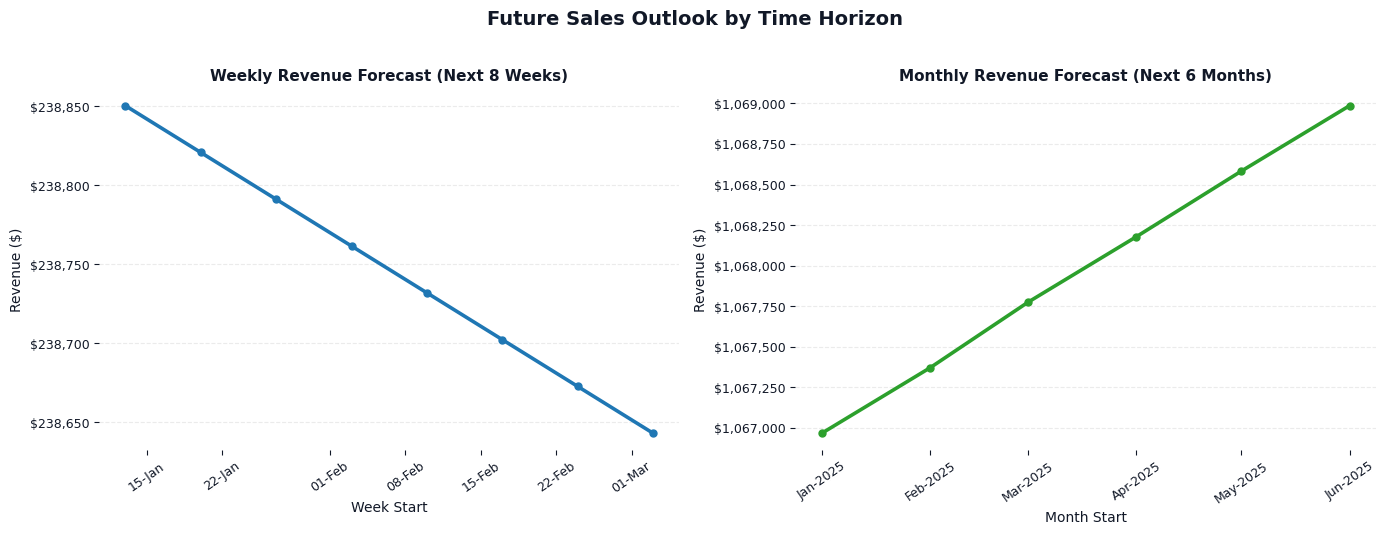

In [191]:
# --- 5) Combined visualization (Matplotlib)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), facecolor='white')
for ax in (ax1, ax2):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#111827', labelsize=9)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

ax1.plot(
    weekly_future_df['week_start'],
    weekly_future_df['forecast_weekly_revenue'],
    color='#1f77b4',
    marker='o',
    linewidth=2.6,
    markersize=5
)
ax1.set_title('Weekly Revenue Forecast (Next 8 Weeks)', fontsize=11, fontweight='bold', color='#111827')
ax1.set_xlabel('Week Start', color='#111827')
ax1.set_ylabel('Revenue ($)', color='#111827')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax1.tick_params(axis='x', rotation=35)

ax2.plot(
    monthly_future_df['month_start'],
    monthly_future_df['forecast_monthly_revenue'],
    color='#2ca02c',
    marker='o',
    linewidth=2.6,
    markersize=5
)
ax2.set_title('Monthly Revenue Forecast (Next 6 Months)', fontsize=11, fontweight='bold', color='#111827')
ax2.set_xlabel('Month Start', color='#111827')
ax2.set_ylabel('Revenue ($)', color='#111827')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.tick_params(axis='x', rotation=35)

fig.suptitle('Future Sales Outlook by Time Horizon', fontsize=14, fontweight='bold', color='#111827', y=1.02)
plt.tight_layout()
plt.show()

WEEKEND vs WEEKDAY CONTINUITY CHECK (NEXT 12 WEEKS)
Historical weekend share: 28.68%
Forecast weekend share  : 28.55%
Change (percentage points): -0.13 pp
Conclusion: Yes - weekend vs weekday mix is expected to stay broadly stable.

Historical split:
day_type       revenue  share_pct
 Weekday 18,175,619.14      71.32
 Weekend  7,310,509.72      28.68

Forecast split (next 12 weeks):
day_type  forecast_revenue  share_pct
 Weekday          1,529.11      71.45
 Weekend            611.10      28.55


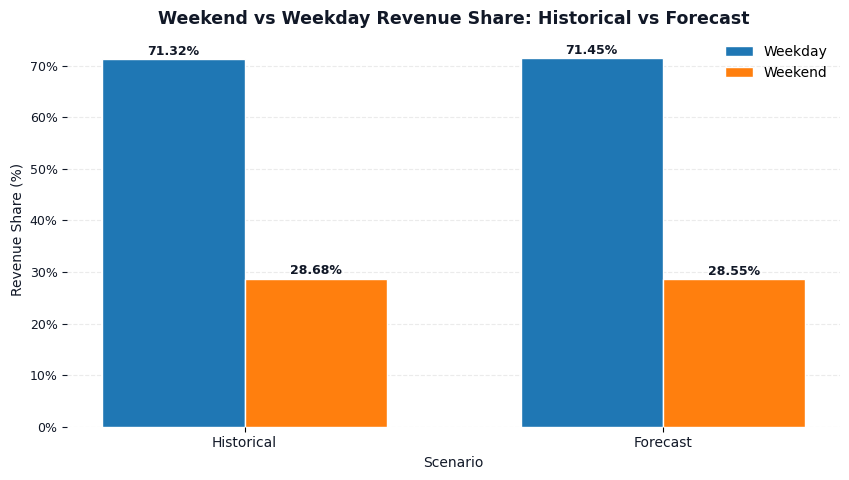

In [197]:
# Will weekend vs weekday trends continue?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.style.use('default')

if 'day_of_week' not in analysis_df.columns:
    raise ValueError('day_of_week column not found in analysis_df.')

df_day = analysis_df.copy()
df_day['order_date'] = pd.to_datetime(df_day['order_date'])

# Normalize day_of_week to 0-6 when possible (Sunday=0)
dow = df_day['day_of_week'].astype(int)
dow_norm = dow.where(dow <= 6, dow % 7)
df_day['dow_norm'] = dow_norm

# Historical daily revenue pattern
daily_pattern = df_day.groupby('dow_norm', as_index=False)['revenue'].mean().rename(columns={'revenue': 'avg_revenue'})
base_map = dict(zip(daily_pattern['dow_norm'], daily_pattern['avg_revenue']))

# Historical weekend vs weekday split
df_day['is_weekend'] = df_day['dow_norm'].isin([0, 6])
hist_split = df_day.groupby('is_weekend', as_index=False)['revenue'].sum()
hist_split['day_type'] = np.where(hist_split['is_weekend'], 'Weekend', 'Weekday')
hist_split['share_pct'] = (hist_split['revenue'] / hist_split['revenue'].sum() * 100).round(2)

# Build a simple day-level trend from historical daily totals
daily_totals = (
    df_day.groupby('order_date', as_index=False)['revenue']
    .sum()
    .sort_values('order_date')
 )
x = np.arange(len(daily_totals))
y = daily_totals['revenue'].values
slope, intercept = np.polyfit(x, y, 1)

# Forecast next 12 weeks at day granularity
forecast_days = 84
future_dates = pd.date_range(df_day['order_date'].max() + pd.Timedelta(days=1), periods=forecast_days, freq='D')
future_df = pd.DataFrame({'date': future_dates})
future_df['dow_norm'] = future_df['date'].dt.dayofweek.map(lambda d: (d + 1) % 7)  # pandas Monday=0 -> Sunday=0
future_df['base_day_revenue'] = future_df['dow_norm'].map(base_map).fillna(np.mean(list(base_map.values())))

# Trend multiplier anchored at end of history
future_x = np.arange(len(daily_totals), len(daily_totals) + forecast_days)
trend_line = np.maximum(intercept + slope * future_x, 0.01)
hist_end_level = max((intercept + slope * (len(daily_totals)-1)), 0.01)
future_df['trend_multiplier'] = trend_line / hist_end_level
future_df['forecast_revenue'] = future_df['base_day_revenue'] * future_df['trend_multiplier']

future_df['is_weekend'] = future_df['dow_norm'].isin([0, 6])
future_split = future_df.groupby('is_weekend', as_index=False)['forecast_revenue'].sum()
future_split['day_type'] = np.where(future_split['is_weekend'], 'Weekend', 'Weekday')
future_split['share_pct'] = (future_split['forecast_revenue'] / future_split['forecast_revenue'].sum() * 100).round(2)

hist_weekend_share = float(hist_split.loc[hist_split['day_type'] == 'Weekend', 'share_pct'].iloc[0])
future_weekend_share = float(future_split.loc[future_split['day_type'] == 'Weekend', 'share_pct'].iloc[0])
delta_pp = future_weekend_share - hist_weekend_share

if abs(delta_pp) <= 1.0:
    verdict = 'Yes - weekend vs weekday mix is expected to stay broadly stable.'
elif delta_pp > 1.0:
    verdict = 'Partly - weekend contribution is expected to increase.'
else:
    verdict = 'Partly - weekend contribution is expected to decrease.'

print('=' * 95)
print('WEEKEND vs WEEKDAY CONTINUITY CHECK (NEXT 12 WEEKS)')
print('=' * 95)
print(f'Historical weekend share: {hist_weekend_share:.2f}%')
print(f'Forecast weekend share  : {future_weekend_share:.2f}%')
print(f'Change (percentage points): {delta_pp:+.2f} pp')
print(f'Conclusion: {verdict}')

print('\nHistorical split:')
print(hist_split[['day_type', 'revenue', 'share_pct']].to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

print('\nForecast split (next 12 weeks):')
print(future_split[['day_type', 'forecast_revenue', 'share_pct']].to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

plot_df = pd.DataFrame({
    'Scenario': ['Historical', 'Historical', 'Forecast', 'Forecast'],
    'Day Type': ['Weekday', 'Weekend', 'Weekday', 'Weekend'],
    'Share %': [
        float(hist_split.loc[hist_split['day_type']=='Weekday', 'share_pct'].iloc[0]),
        float(hist_split.loc[hist_split['day_type']=='Weekend', 'share_pct'].iloc[0]),
        float(future_split.loc[future_split['day_type']=='Weekday', 'share_pct'].iloc[0]),
        float(future_split.loc[future_split['day_type']=='Weekend', 'share_pct'].iloc[0]),
    ]
})

# Matplotlib grouped bar chart
pivot_df = plot_df.pivot(index='Scenario', columns='Day Type', values='Share %').reindex(['Historical', 'Forecast'])
x_pos = np.arange(len(pivot_df.index))
width = 0.34

fig, ax = plt.subplots(figsize=(8.6, 4.9), facecolor='white')
ax.set_facecolor('white')

weekday_vals = pivot_df['Weekday'].values
weekend_vals = pivot_df['Weekend'].values

bars1 = ax.bar(x_pos - width / 2, weekday_vals, width=width, color='#1f77b4', label='Weekday', edgecolor='white', linewidth=1.0)
bars2 = ax.bar(x_pos + width / 2, weekend_vals, width=width, color='#ff7f0e', label='Weekend', edgecolor='white', linewidth=1.0)

for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + 0.25,
            f'{h:.2f}%',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color='#111827'
        )

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(x_pos)
ax.set_xticklabels(pivot_df.index, fontsize=10, color='#111827')
ax.set_ylabel('Revenue Share (%)', fontsize=10, color='#111827')
ax.set_xlabel('Scenario', fontsize=10, color='#111827')
ax.set_title('Weekend vs Weekday Revenue Share: Historical vs Forecast', fontsize=12.5, fontweight='bold', color='#111827')
ax.tick_params(axis='y', labelsize=9, colors='#111827')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}%'))
ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.25)
ax.set_axisbelow(True)
ax.set_ylim(0, max(np.max(weekday_vals), np.max(weekend_vals)) + 5)
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

weekend_weekday_forecast_df = future_df.copy()
weekend_weekday_split_df = future_split.copy()

HOLIDAY IMPACT FORECAST (NEXT 12 WEEKS)
Holiday signal source: Inferred proxy from top 5% non-weekend revenue dates (month-day pattern)
Historical average on holidays    : $35,947.90
Historical average on non-holidays: $34,778.35
Estimated holiday lift            : +3.36%

Forward impact (next 12 weeks):
- Holiday/event days in forecast window: 5
- Baseline forecast total            : $2,920,433.41
- Holiday-adjusted forecast total    : $2,926,278.88
- Incremental holiday impact         : $5,845.46 (+0.20%)


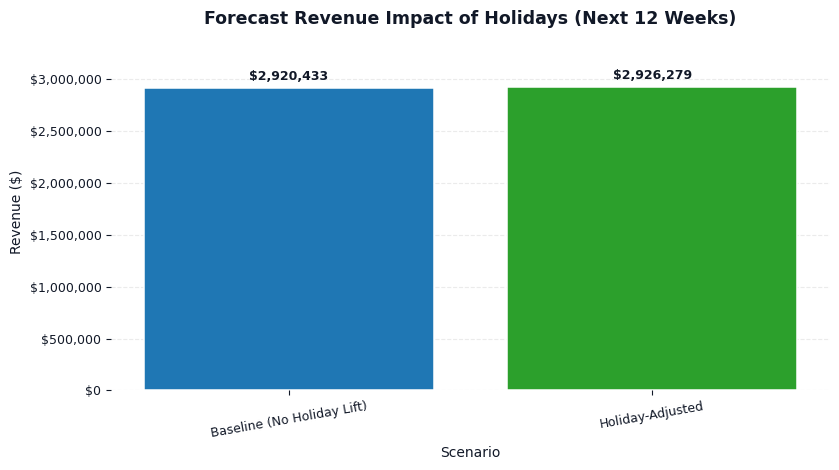

In [196]:
# Can we predict holiday impact on sales?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.style.use('default')

df_h = analysis_df.copy()
df_h['order_date'] = pd.to_datetime(df_h['order_date'])

# 1) Detect holiday signal from analysis_df or calendar
def to_binary_holiday(s):
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False).astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return (s.fillna(0) > 0).astype(int)
    txt = s.astype(str).str.strip().str.lower()
    return txt.isin(['1', 'true', 'yes', 'y', 'holiday', 'public holiday']).astype(int)

holiday_cols_analysis = [c for c in df_h.columns if 'holiday' in c.lower()]
holiday_cols_calendar = [c for c in calendar.columns if 'holiday' in c.lower()]

holiday_source = None
fallback_proxy_used = False

if holiday_cols_analysis:
    hol = pd.DataFrame({c: to_binary_holiday(df_h[c]) for c in holiday_cols_analysis})
    df_h['is_holiday'] = (hol.sum(axis=1) > 0).astype(int)
    holiday_source = f"analysis_df columns: {holiday_cols_analysis}"
elif 'date' in calendar.columns and holiday_cols_calendar:
    cal_h = calendar[['date'] + holiday_cols_calendar].copy()
    cal_h['date'] = pd.to_datetime(cal_h['date'])
    hol = pd.DataFrame({c: to_binary_holiday(cal_h[c]) for c in holiday_cols_calendar})
    cal_h['is_holiday'] = (hol.sum(axis=1) > 0).astype(int)
    cal_h = cal_h[['date', 'is_holiday']].drop_duplicates('date')

    df_h = df_h.merge(cal_h, left_on='order_date', right_on='date', how='left')
    df_h['is_holiday'] = df_h['is_holiday'].fillna(0).astype(int)
    holiday_source = f"calendar columns: {holiday_cols_calendar}"
else:
    # Fallback: infer holiday-like dates from top historical revenue days (proxy)
    daily_rev_proxy = df_h.groupby('order_date', as_index=False)['revenue'].sum()
    daily_rev_proxy['dow_norm'] = daily_rev_proxy['order_date'].dt.dayofweek.map(lambda d: (d + 1) % 7)
    daily_rev_proxy['is_weekend'] = daily_rev_proxy['dow_norm'].isin([0, 6])

    # Use high-revenue non-weekend days as event/holiday proxy to avoid weekend bias.
    threshold = daily_rev_proxy.loc[~daily_rev_proxy['is_weekend'], 'revenue'].quantile(0.95)
    proxy_days = daily_rev_proxy[(~daily_rev_proxy['is_weekend']) & (daily_rev_proxy['revenue'] >= threshold)].copy()
    proxy_mmdd = set(proxy_days['order_date'].dt.strftime('%m-%d'))

    df_h['mmdd'] = df_h['order_date'].dt.strftime('%m-%d')
    df_h['is_holiday'] = df_h['mmdd'].isin(proxy_mmdd).astype(int)
    fallback_proxy_used = True
    holiday_source = 'Inferred proxy from top 5% non-weekend revenue dates (month-day pattern)'

# 2) Historical holiday lift
daily_rev = (
    df_h.groupby('order_date', as_index=False)
    .agg(
        daily_revenue=('revenue', 'sum'),
        is_holiday=('is_holiday', 'max')
    )
    .sort_values('order_date')
 )

holiday_avg = daily_rev.loc[daily_rev['is_holiday'] == 1, 'daily_revenue'].mean()
non_holiday_avg = daily_rev.loc[daily_rev['is_holiday'] == 0, 'daily_revenue'].mean()
if pd.isna(holiday_avg) or non_holiday_avg <= 0:
    raise ValueError('Insufficient holiday/non-holiday history to estimate impact.')

holiday_lift_pct = (holiday_avg / non_holiday_avg - 1) * 100

# 3) Forecast next 12 weeks and apply holiday lift on flagged future dates
forecast_days = 84
future_dates = pd.date_range(daily_rev['order_date'].max() + pd.Timedelta(days=1), periods=forecast_days, freq='D')
future = pd.DataFrame({'date': future_dates})

# Base forecast from linear trend on daily totals
x = np.arange(len(daily_rev))
y = daily_rev['daily_revenue'].values
slope, intercept = np.polyfit(x, y, 1)
future_x = np.arange(len(daily_rev), len(daily_rev) + forecast_days)
future['base_forecast_revenue'] = np.maximum(intercept + slope * future_x, 0)

# Attach future holiday flag
if not fallback_proxy_used and ('date' in calendar.columns and holiday_cols_calendar):
    cal_future = calendar[['date'] + holiday_cols_calendar].copy()
    cal_future['date'] = pd.to_datetime(cal_future['date'])
    hol_f = pd.DataFrame({c: to_binary_holiday(cal_future[c]) for c in holiday_cols_calendar})
    cal_future['is_holiday'] = (hol_f.sum(axis=1) > 0).astype(int)
    cal_future = cal_future[['date', 'is_holiday']].drop_duplicates('date')
    future = future.merge(cal_future, on='date', how='left')
    future['is_holiday'] = future['is_holiday'].fillna(0).astype(int)
else:
    future['mmdd'] = future['date'].dt.strftime('%m-%d')
    hist_mmdd_holidays = set(df_h.loc[df_h['is_holiday'] == 1, 'order_date'].dt.strftime('%m-%d'))
    future['is_holiday'] = future['mmdd'].isin(hist_mmdd_holidays).astype(int)

future['forecast_with_holiday'] = np.where(
    future['is_holiday'] == 1,
    future['base_forecast_revenue'] * (1 + holiday_lift_pct / 100.0),
    future['base_forecast_revenue']
)

base_total = future['base_forecast_revenue'].sum()
with_holiday_total = future['forecast_with_holiday'].sum()
incremental_impact = with_holiday_total - base_total
incremental_pct = (incremental_impact / base_total * 100) if base_total > 0 else 0
future_holiday_days = int(future['is_holiday'].sum())

print('=' * 105)
print('HOLIDAY IMPACT FORECAST (NEXT 12 WEEKS)')
print('=' * 105)
print(f'Holiday signal source: {holiday_source}')
print(f'Historical average on holidays    : ${holiday_avg:,.2f}')
print(f'Historical average on non-holidays: ${non_holiday_avg:,.2f}')
print(f'Estimated holiday lift            : {holiday_lift_pct:+.2f}%')

print('\nForward impact (next 12 weeks):')
print(f'- Holiday/event days in forecast window: {future_holiday_days}')
print(f'- Baseline forecast total            : ${base_total:,.2f}')
print(f'- Holiday-adjusted forecast total    : ${with_holiday_total:,.2f}')
print(f'- Incremental holiday impact         : ${incremental_impact:,.2f} ({incremental_pct:+.2f}%)')

holiday_impact_summary_df = pd.DataFrame({
    'metric': [
        'historical_holiday_avg',
        'historical_non_holiday_avg',
        'holiday_lift_pct',
        'forecast_holiday_days',
        'baseline_total_12w',
        'holiday_adjusted_total_12w',
        'incremental_holiday_impact',
        'incremental_impact_pct'
    ],
    'value': [
        holiday_avg,
        non_holiday_avg,
        holiday_lift_pct,
        future_holiday_days,
        base_total,
        with_holiday_total,
        incremental_impact,
        incremental_pct
    ]
})

plot_df = pd.DataFrame({
    'Scenario': ['Baseline (No Holiday Lift)', 'Holiday-Adjusted'],
    'Revenue': [base_total, with_holiday_total]
})

# Matplotlib chart
fig, ax = plt.subplots(figsize=(8.5, 4.8), facecolor='white')
ax.set_facecolor('white')
colors = {'Baseline (No Holiday Lift)': '#1f77b4', 'Holiday-Adjusted': '#2ca02c'}
bars = ax.bar(plot_df['Scenario'], plot_df['Revenue'], color=[colors[s] for s in plot_df['Scenario']], edgecolor='white', linewidth=1.1)

for bar, val in zip(bars, plot_df['Revenue']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + plot_df['Revenue'].max() * 0.015,
        f'${val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='#111827'
    )

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Forecast Revenue Impact of Holidays (Next 12 Weeks)', fontsize=12.5, fontweight='bold', color='#111827')
ax.set_xlabel('Scenario', color='#111827')
ax.set_ylabel('Revenue ($)', color='#111827')
ax.tick_params(axis='x', labelsize=9, colors='#111827', rotation=10)
ax.tick_params(axis='y', labelsize=9, colors='#111827')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.25)
ax.set_axisbelow(True)
ax.set_ylim(0, plot_df['Revenue'].max() * 1.18)
plt.tight_layout()
plt.show()

future_holiday_forecast_df = future.copy()

PROFIT-MAXIMIZING PRICING STRATEGY (ELASTICITY-BASED)
No cost column found; using 60% of base price as unit cost proxy.
Estimated total monthly profit (current proxy): $421,998.69
Estimated total monthly profit (optimized)    : $586,561.05
Potential monthly uplift                      : $164,562.36 (+39.00%)

Top pricing actions by expected monthly profit uplift:
         product_name  elasticity  base_price  unit_cost  recommended_price_change_pct       strategy  profit_uplift
   Dark Chocolate 50%       -0.30        8.49       5.10                         20.00 Increase price      12,584.86
Truffle Chocolate 80%       -0.30        8.50       5.10                         20.00 Increase price      11,613.35
   Dark Chocolate 60%       -0.29        8.52       5.11                         20.00 Increase price       8,916.68
  White Chocolate 50%       -0.30        8.49       5.09                         20.00 Increase price       8,879.14
Truffle Chocolate 90%       -0.30        8.47    

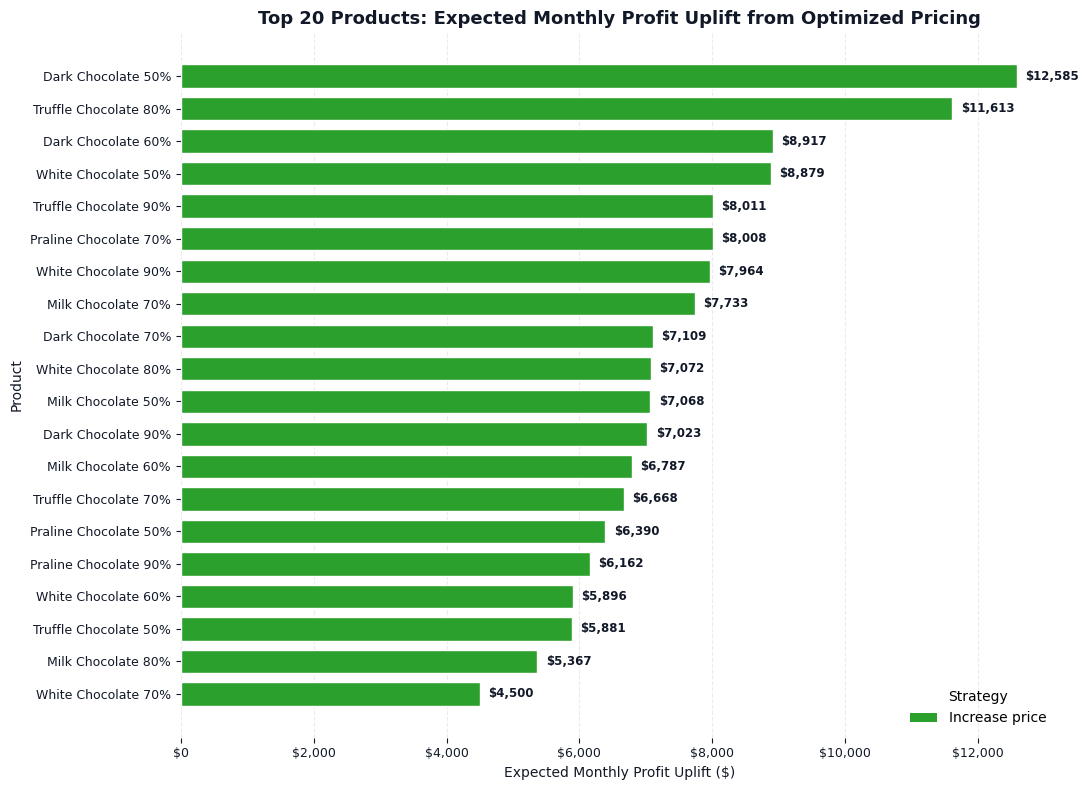

In [195]:
# What pricing strategy will maximize profit?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
plt.style.use('default')

# 1) Resolve product label/id columns
product_label_col = 'product_name' if 'product_name' in analysis_df.columns else 'product_id'
product_id_col = 'product_id' if 'product_id' in analysis_df.columns else None

# 2) Build monthly product price/quantity panel
prod_month = (
    analysis_df
    .groupby([product_label_col, pd.Grouper(key='order_date', freq='MS')], as_index=False)
    .agg(revenue=('revenue', 'sum'), quantity=('quantity', 'sum'))
    .rename(columns={'order_date': 'month'})
 )
prod_month = prod_month[prod_month['quantity'] > 0].copy()
prod_month['unit_price'] = prod_month['revenue'] / prod_month['quantity']

# 3) Estimate own-price elasticity per product with log-log regression
elas_rows = []
for p, g in prod_month.groupby(product_label_col):
    g = g[(g['unit_price'] > 0) & (g['quantity'] > 0)].copy()
    if len(g) < 6 or g['unit_price'].nunique() < 3:
        continue

    x = np.log(g['unit_price'].values)
    y = np.log(g['quantity'].values)
    slope, _ = np.polyfit(x, y, 1)
    elasticity = float(slope)

    # Guardrails: positive elasticity is usually spurious for own-price demand.
    if elasticity >= 0:
        elasticity = -0.3
    elasticity = float(np.clip(elasticity, -3.0, -0.1))

    base_price = g['revenue'].sum() / g['quantity'].sum()
    base_qty = g.sort_values('month')['quantity'].tail(3).mean()

    elas_rows.append({
        product_label_col: p,
        'elasticity': elasticity,
        'base_price': base_price,
        'base_monthly_qty': base_qty
    })

pricing_df = pd.DataFrame(elas_rows)
if pricing_df.empty:
    raise ValueError('Not enough variation to estimate product-level price elasticity.')

# 4) Attach unit cost if available; otherwise use margin assumption
products_df = None
for name in ['products', 'products_clean', 'products_analysis']:
    obj = globals().get(name, None)
    if isinstance(obj, pd.DataFrame):
        products_df = obj
        break

cost_col = None
cost_candidates = ['cost', 'unit_cost', 'cogs', 'product_cost', 'standard_cost', 'cost_price']
if products_df is not None:
    cost_col = next((c for c in products_df.columns if c.lower() in cost_candidates), None)

cost_note = ''
if cost_col is not None:
    keys = [k for k in [product_label_col, product_id_col] if k and k in products_df.columns]
    if keys:
        cost_map = products_df[keys + [cost_col]].drop_duplicates(subset=keys)
        pricing_df = pricing_df.merge(cost_map, on=[k for k in keys if k in pricing_df.columns], how='left')
        pricing_df['unit_cost'] = pricing_df[cost_col].astype(float)
        pricing_df['unit_cost'] = pricing_df['unit_cost'].fillna(pricing_df['base_price'] * 0.60)
        cost_note = f"Using product cost column '{cost_col}' where available; fallback 60% of base price."
    else:
        pricing_df['unit_cost'] = pricing_df['base_price'] * 0.60
        cost_note = 'No join key for product cost; using 60% of base price as unit cost proxy.'
else:
    pricing_df['unit_cost'] = pricing_df['base_price'] * 0.60
    cost_note = 'No cost column found; using 60% of base price as unit cost proxy.'

# Ensure feasible margins
pricing_df['unit_cost'] = np.minimum(pricing_df['unit_cost'], pricing_df['base_price'] * 0.95)

# 5) Simulate candidate price changes and select profit-maximizing point
price_multipliers = np.round(np.arange(0.80, 1.201, 0.02), 2)
sim_rows = []

for _, row in pricing_df.iterrows():
    bp = row['base_price']
    bq = row['base_monthly_qty']
    e = row['elasticity']
    c = row['unit_cost']

    for m in price_multipliers:
        p_new = bp * m
        q_new = bq * (p_new / bp) ** e
        q_new = max(q_new, 0)
        monthly_profit = (p_new - c) * q_new
        sim_rows.append({
            product_label_col: row[product_label_col],
            'price_multiplier': m,
            'new_price': p_new,
            'predicted_monthly_qty': q_new,
            'predicted_monthly_profit': monthly_profit
        })

sim_df = pd.DataFrame(sim_rows)

best_idx = sim_df.groupby(product_label_col)['predicted_monthly_profit'].idxmax()
best_prices = sim_df.loc[best_idx].reset_index(drop=True)

result_df = pricing_df.merge(best_prices, on=product_label_col, how='left')
result_df['current_monthly_profit_proxy'] = (result_df['base_price'] - result_df['unit_cost']) * result_df['base_monthly_qty']
result_df['profit_uplift'] = result_df['predicted_monthly_profit'] - result_df['current_monthly_profit_proxy']
result_df['recommended_price_change_pct'] = (result_df['price_multiplier'] - 1) * 100
result_df['strategy'] = np.where(
    result_df['recommended_price_change_pct'] > 1,
    'Increase price',
    np.where(result_df['recommended_price_change_pct'] < -1, 'Decrease price', 'Keep near current price')
)

result_df = result_df.sort_values('profit_uplift', ascending=False).reset_index(drop=True)

total_current = result_df['current_monthly_profit_proxy'].sum()
total_optimized = result_df['predicted_monthly_profit'].sum()
total_uplift = total_optimized - total_current
uplift_pct = (total_uplift / total_current * 100) if total_current > 0 else 0

print('=' * 112)
print('PROFIT-MAXIMIZING PRICING STRATEGY (ELASTICITY-BASED)')
print('=' * 112)
print(cost_note)
print(f"Estimated total monthly profit (current proxy): ${total_current:,.2f}")
print(f"Estimated total monthly profit (optimized)    : ${total_optimized:,.2f}")
print(f"Potential monthly uplift                      : ${total_uplift:,.2f} ({uplift_pct:+.2f}%)")

print('\nTop pricing actions by expected monthly profit uplift:')
show_cols = [
    product_label_col, 'elasticity', 'base_price', 'unit_cost',
    'recommended_price_change_pct', 'strategy', 'profit_uplift'
 ]
print(result_df[show_cols].head(20).to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

# Matplotlib chart
plot_df = result_df.head(20).sort_values('profit_uplift', ascending=True).copy()
strategy_colors = {
    'Increase price': '#2ca02c',
    'Decrease price': '#ff7f0e',
    'Keep near current price': '#1f77b4'
}

fig, ax = plt.subplots(figsize=(11, 8), facecolor='white')
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_visible(False)

bars = ax.barh(
    plot_df[product_label_col].astype(str),
    plot_df['profit_uplift'],
    color=[strategy_colors.get(s, '#7f7f7f') for s in plot_df['strategy']],
    edgecolor='white',
    linewidth=1.0,
    height=0.72
 )

for bar, val in zip(bars, plot_df['profit_uplift']):
    ax.text(
        val + (abs(plot_df['profit_uplift']).max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center',
        ha='left',
        fontsize=8.5,
        color='#111827',
        fontweight='bold'
    )

ax.set_title('Top 20 Products: Expected Monthly Profit Uplift from Optimized Pricing', fontsize=13, fontweight='bold', color='#111827')
ax.set_xlabel('Expected Monthly Profit Uplift ($)', color='#111827')
ax.set_ylabel('Product', color='#111827')
ax.tick_params(axis='x', labelsize=9, colors='#111827')
ax.tick_params(axis='y', labelsize=9, colors='#111827')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.25)
ax.set_axisbelow(True)

legend_handles = [Patch(facecolor=strategy_colors[s], label=s) for s in strategy_colors if s in plot_df['strategy'].values]
ax.legend(handles=legend_handles, title='Strategy', frameon=False, loc='lower right')

plt.tight_layout()
plt.show()

pricing_optimization_df = result_df.copy()
pricing_simulation_df = sim_df.copy()

DISCOUNT IMPACT FORECAST (NEXT 12 WEEKS)
Discount signal source        : explicit columns: ['discount']
Lift estimation method        : adaptive quartile split (high vs low discount-intensity days)
Historical discount-day rate  : 37.49%
Estimated discount sales lift : -0.45% on discount-active days

Forecast scenarios (12-week total revenue):
- Baseline (no discount effect)      : $2,920,433.41
- Current discount pattern           : $2,915,491.62
- Lower discount intensity (-10 pp)  : $2,916,809.92
- Higher discount intensity (+10 pp) : $2,914,173.32

Incremental vs baseline:
- Current pattern uplift : $-4,941.79 (-0.17%)
- Lower intensity uplift : $-3,623.50 (-0.12%)
- Higher intensity uplift: $-6,260.09 (-0.21%)


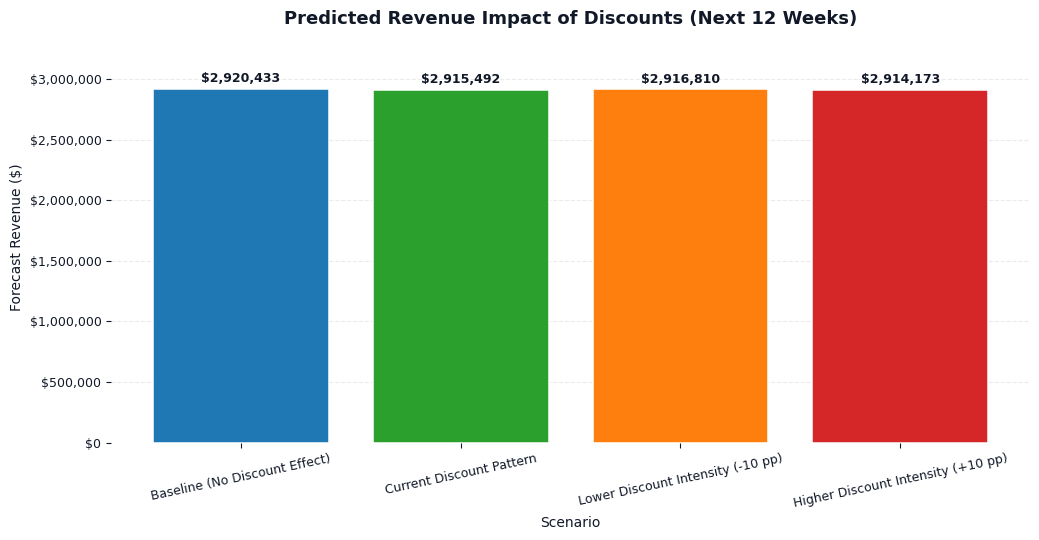

In [194]:
# Can we predict how discounts impact future sales?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.style.use('default')

df_d = analysis_df.copy()
df_d['order_date'] = pd.to_datetime(df_d['order_date'])

product_col = 'product_name' if 'product_name' in df_d.columns else 'product_id'
if product_col not in df_d.columns:
    raise ValueError('No product identifier found for discount impact modeling.')

# Base unit price
df_d = df_d[df_d['quantity'] > 0].copy()
df_d['unit_price'] = df_d['revenue'] / df_d['quantity']

# 1) Detect discount signal (explicit first, then inferred)
discount_cols = [c for c in df_d.columns if 'discount' in c.lower()]
discount_source = None

if discount_cols:
    dtmp = pd.DataFrame(index=df_d.index)
    for c in discount_cols:
        s = df_d[c]
        if pd.api.types.is_numeric_dtype(s):
            dtmp[c] = s.fillna(0) > 0
        elif pd.api.types.is_bool_dtype(s):
            dtmp[c] = s.fillna(False)
        else:
            txt = s.astype(str).str.lower().str.strip()
            dtmp[c] = txt.isin(['1', 'true', 'yes', 'y', 'discount', 'promo', 'promotion'])
    df_d['is_discounted'] = dtmp.any(axis=1).astype(int)
    discount_source = f"explicit columns: {discount_cols}"
else:
    # Inferred discount: transaction unit price at least 3% below product median price
    med_price = df_d.groupby(product_col)['unit_price'].median().rename('median_price')
    df_d = df_d.merge(med_price, on=product_col, how='left')
    df_d['price_ratio'] = df_d['unit_price'] / df_d['median_price'].replace(0, np.nan)
    df_d['is_discounted'] = (df_d['price_ratio'] <= 0.97).astype(int)
    discount_source = 'inferred from unit-price dips vs product median (>=3% below median)'

# 2) Historical discount lift estimation (daily view)
daily_disc = (
    df_d.groupby('order_date', as_index=False)
    .agg(
        daily_revenue=('revenue', 'sum'),
        discount_qty_share=('is_discounted', 'mean')
    )
 )

# Primary split: days with at least 5% discounted transactions vs others
daily_disc['is_discount_day'] = (daily_disc['discount_qty_share'] > 0.05).astype(int)
n_high = int((daily_disc['is_discount_day'] == 1).sum())
n_low = int((daily_disc['is_discount_day'] == 0).sum())

if n_high >= 5 and n_low >= 5:
    disc_day_avg = daily_disc.loc[daily_disc['is_discount_day'] == 1, 'daily_revenue'].mean()
    non_disc_day_avg = daily_disc.loc[daily_disc['is_discount_day'] == 0, 'daily_revenue'].mean()
    historical_discount_day_rate = daily_disc['is_discount_day'].mean()
    split_note = '5% threshold split'
else:
    # Fallback: compare top quartile discount-intensity days vs bottom quartile
    q75 = daily_disc['discount_qty_share'].quantile(0.75)
    q25 = daily_disc['discount_qty_share'].quantile(0.25)
    high_days = daily_disc[daily_disc['discount_qty_share'] >= q75]
    low_days = daily_disc[daily_disc['discount_qty_share'] <= q25]

    if len(high_days) < 5 or len(low_days) < 5:
        raise ValueError('Not enough variation in discount intensity to estimate discount impact reliably.')

    disc_day_avg = high_days['daily_revenue'].mean()
    non_disc_day_avg = low_days['daily_revenue'].mean()
    # Use average historical intensity as expected discount-day equivalent rate.
    historical_discount_day_rate = float(daily_disc['discount_qty_share'].mean())
    split_note = 'adaptive quartile split (high vs low discount-intensity days)'

if non_disc_day_avg <= 0:
    raise ValueError('Non-discount baseline is non-positive; cannot estimate lift.')

discount_lift_pct = (disc_day_avg / non_disc_day_avg - 1) * 100

# 3) Forecast baseline next 12 weeks (daily trend)
daily_total = df_d.groupby('order_date', as_index=False)['revenue'].sum().sort_values('order_date')
x = np.arange(len(daily_total))
y = daily_total['revenue'].values
slope, intercept = np.polyfit(x, y, 1)

forecast_days = 84
future_dates = pd.date_range(daily_total['order_date'].max() + pd.Timedelta(days=1), periods=forecast_days, freq='D')
future = pd.DataFrame({'date': future_dates})
future_x = np.arange(len(daily_total), len(daily_total) + forecast_days)
future['baseline_revenue'] = np.maximum(intercept + slope * future_x, 0)

# 4) Scenario simulation
r = float(np.clip(historical_discount_day_rate, 0, 1))
lift = discount_lift_pct / 100.0

future['revenue_with_current_discount_pattern'] = future['baseline_revenue'] * (1 + r * lift)
future['revenue_with_higher_discount_pattern'] = future['baseline_revenue'] * (1 + min(r + 0.10, 1.0) * lift)
future['revenue_with_lower_discount_pattern'] = future['baseline_revenue'] * (1 + max(r - 0.10, 0.0) * lift)

baseline_total = future['baseline_revenue'].sum()
current_disc_total = future['revenue_with_current_discount_pattern'].sum()
higher_disc_total = future['revenue_with_higher_discount_pattern'].sum()
lower_disc_total = future['revenue_with_lower_discount_pattern'].sum()

print('=' * 108)
print('DISCOUNT IMPACT FORECAST (NEXT 12 WEEKS)')
print('=' * 108)
print(f'Discount signal source        : {discount_source}')
print(f'Lift estimation method        : {split_note}')
print(f'Historical discount-day rate  : {r*100:.2f}%')
print(f'Estimated discount sales lift : {discount_lift_pct:+.2f}% on discount-active days')

print('\nForecast scenarios (12-week total revenue):')
print(f'- Baseline (no discount effect)      : ${baseline_total:,.2f}')
print(f'- Current discount pattern           : ${current_disc_total:,.2f}')
print(f'- Lower discount intensity (-10 pp)  : ${lower_disc_total:,.2f}')
print(f'- Higher discount intensity (+10 pp) : ${higher_disc_total:,.2f}')

print('\nIncremental vs baseline:')
print(f'- Current pattern uplift : ${current_disc_total - baseline_total:,.2f} ({(current_disc_total/baseline_total - 1)*100:+.2f}%)')
print(f'- Lower intensity uplift : ${lower_disc_total - baseline_total:,.2f} ({(lower_disc_total/baseline_total - 1)*100:+.2f}%)')
print(f'- Higher intensity uplift: ${higher_disc_total - baseline_total:,.2f} ({(higher_disc_total/baseline_total - 1)*100:+.2f}%)')

scenario_df = pd.DataFrame({
    'Scenario': [
        'Baseline (No Discount Effect)',
        'Current Discount Pattern',
        'Lower Discount Intensity (-10 pp)',
        'Higher Discount Intensity (+10 pp)'
    ],
    'Forecast Revenue': [baseline_total, current_disc_total, lower_disc_total, higher_disc_total]
})

# Matplotlib visualization
plot_df = scenario_df.copy()
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

fig, ax = plt.subplots(figsize=(10.5, 5.5), facecolor='white')
ax.set_facecolor('white')
bars = ax.bar(plot_df['Scenario'], plot_df['Forecast Revenue'], color=colors, edgecolor='white', linewidth=1.1)

for bar, val in zip(bars, plot_df['Forecast Revenue']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + plot_df['Forecast Revenue'].max() * 0.01,
        f'${val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='#111827'
    )

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Predicted Revenue Impact of Discounts (Next 12 Weeks)', fontsize=13, fontweight='bold', color='#111827')
ax.set_xlabel('Scenario', color='#111827')
ax.set_ylabel('Forecast Revenue ($)', color='#111827')
ax.tick_params(axis='x', labelsize=9, colors='#111827', rotation=12)
ax.tick_params(axis='y', labelsize=9, colors='#111827')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.25)
ax.set_axisbelow(True)
ax.set_ylim(0, plot_df['Forecast Revenue'].max() * 1.16)
plt.tight_layout()
plt.show()

discount_impact_forecast_df = future.copy()
discount_impact_scenarios_df = scenario_df.copy()

In [ ]:
# What is the optimal price point for products? (table)
if 'pricing_optimization_df' not in globals():
    raise ValueError('Run the pricing optimization cell first.')

name_col = 'product_name' if 'product_name' in pricing_optimization_df.columns else pricing_optimization_df.columns[0]

opt_price_df = pricing_optimization_df[[
    name_col,
    'base_price',
    'new_price',
    'recommended_price_change_pct',
    'strategy',
    'predicted_monthly_profit'
]].copy()

opt_price_df = opt_price_df.sort_values('predicted_monthly_profit', ascending=False).reset_index(drop=True)

print('Optimal product price points (profit-maximizing):')
print(opt_price_df.to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

print('\nSummary:')
print(f"Median recommended price change: {opt_price_df['recommended_price_change_pct'].median():.2f}%")
print(f"Average recommended price change: {opt_price_df['recommended_price_change_pct'].mean():.2f}%")

Optimal product price points (profit-maximizing):
         product_name  base_price  new_price  recommended_price_change_pct       strategy  predicted_monthly_profit
   Dark Chocolate 50%        8.49      10.19                         20.00 Increase price                 42,537.48
Truffle Chocolate 80%        8.50      10.19                         20.00 Increase price                 39,253.73
   Milk Chocolate 70%        8.53      10.24                         20.00 Increase price                 30,973.79
   Dark Chocolate 60%        8.52      10.23                         20.00 Increase price                 30,047.70
  White Chocolate 50%        8.49      10.18                         20.00 Increase price                 30,011.97
Praline Chocolate 50%        8.50      10.20                         20.00 Increase price                 29,517.74
Truffle Chocolate 90%        8.47      10.17                         20.00 Increase price                 27,078.53
Praline Chocolate 70% 

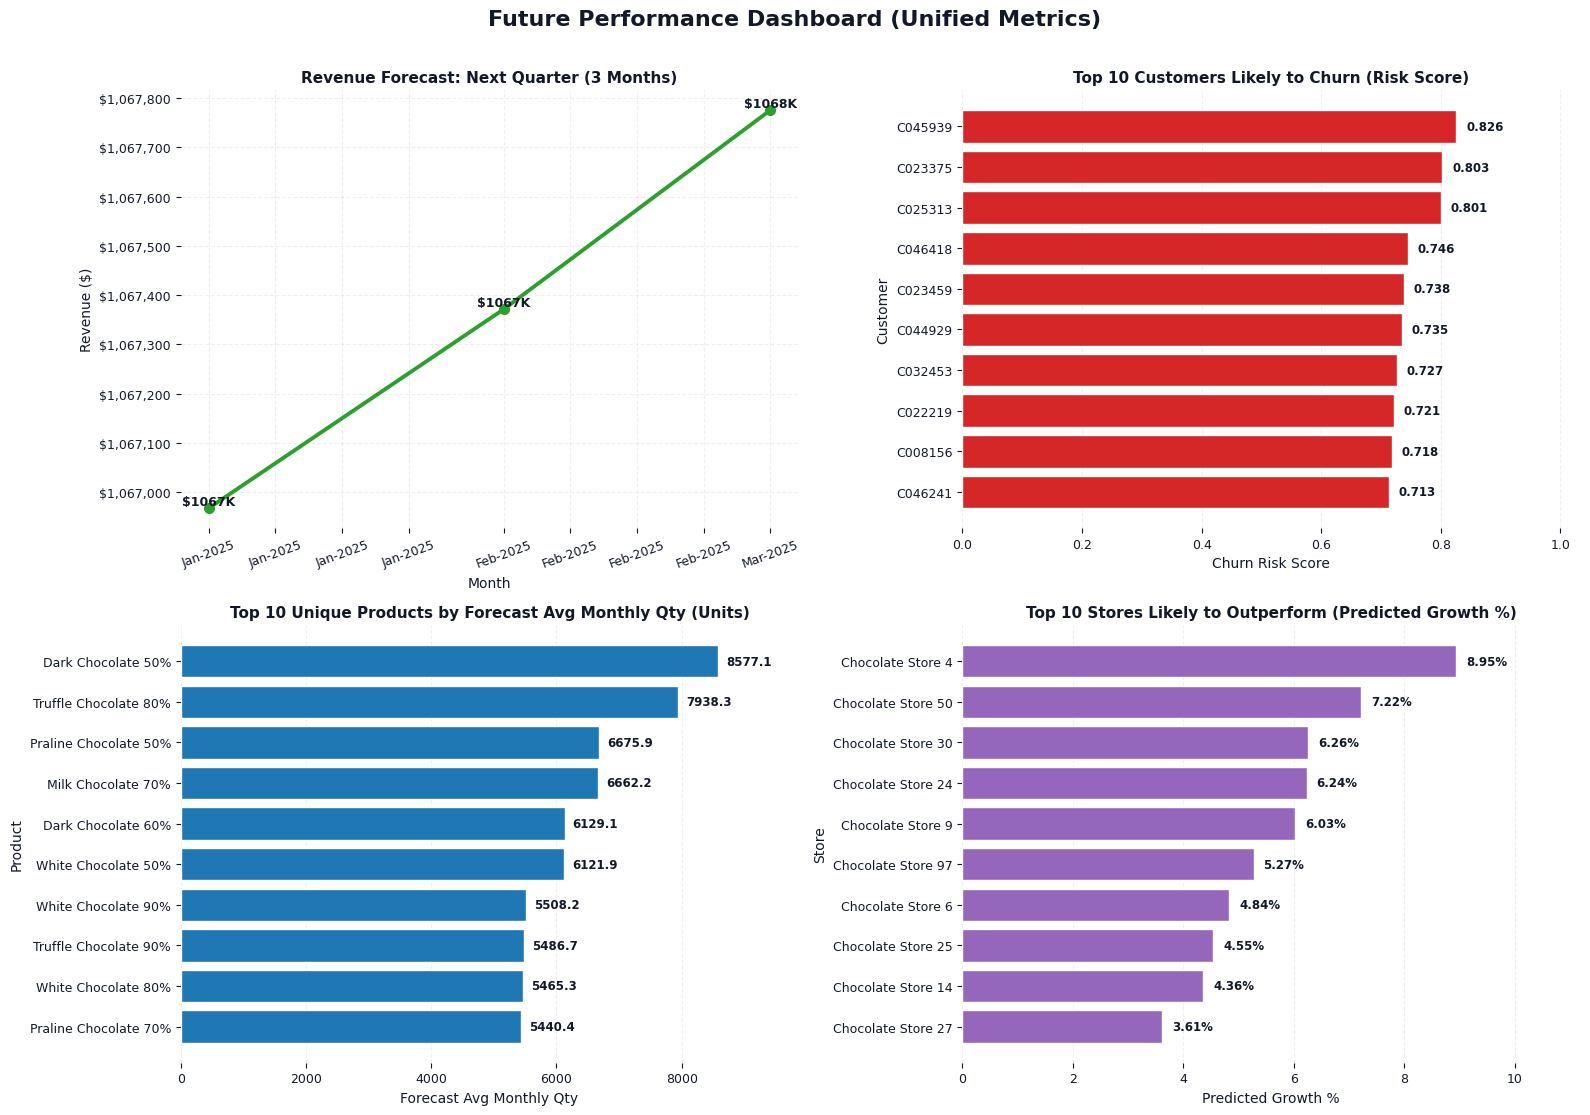

DASHBOARD SUMMARY (same source tables as chart)
Forecast revenue next quarter: $3,202,114.75
Highest churn-risk customer: C045939 (score=0.826)
Highest demand product next month: Dark Chocolate 50% (8577.1 units)
Top outperforming store: Chocolate Store 4 (8.95% growth)

Top 10 Product Demand Source Table (unique products):


,Product,Forecast Avg Monthly Qty
0,Dark Chocolate 50%,8577.127223
18,Truffle Chocolate 80%,7938.344733
10,Praline Chocolate 50%,6675.923393
7,Milk Chocolate 70%,6662.175103
1,Dark Chocolate 60%,6129.110807
20,White Chocolate 50%,6121.887825
24,White Chocolate 90%,5508.221614
19,Truffle Chocolate 90%,5486.675787
23,White Chocolate 80%,5465.294118
12,Praline Chocolate 70%,5440.383037


In [193]:
# Unified future dashboard: revenue, churn, next-month demand, store outperformance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from IPython.display import display
plt.style.use('default')

# -------------------------------
# 1) Revenue forecast next quarter
# -------------------------------
if 'monthly_future_sales_df' in globals() and 'forecast_monthly_revenue' in monthly_future_sales_df.columns:
    quarter_df = monthly_future_sales_df.head(3).copy()
    quarter_df = quarter_df.rename(columns={'month_start': 'Month', 'forecast_monthly_revenue': 'Revenue'})
else:
    monthly_hist = (
        analysis_df.groupby(pd.Grouper(key='order_date', freq='MS'))['revenue']
        .sum()
        .sort_index()
    )
    x = np.arange(len(monthly_hist))
    y = monthly_hist.values
    slope, intercept = np.polyfit(x, y, 1)
    future_x = np.arange(len(monthly_hist), len(monthly_hist) + 3)
    future_months = pd.date_range(monthly_hist.index[-1] + pd.offsets.MonthBegin(1), periods=3, freq='MS')
    quarter_df = pd.DataFrame({'Month': future_months, 'Revenue': np.maximum(intercept + slope * future_x, 0)})

next_quarter_revenue = quarter_df['Revenue'].sum()

# -------------------------------
# 2) Customers likely to churn
# -------------------------------
if 'churn_df' in globals() and 'churn_risk_score' in churn_df.columns:
    churn_top = churn_df.sort_values('churn_risk_score', ascending=False).head(10).copy()
    churn_customer_col = 'customer_id' if 'customer_id' in churn_top.columns else ('cust_id' if 'cust_id' in churn_top.columns else churn_top.columns[0])
    churn_plot_x = churn_top['churn_risk_score']
    churn_plot_y = churn_top[churn_customer_col].astype(str)
else:
    raise ValueError('Run churn analysis cell first to create churn_df with churn_risk_score.')

# -------------------------------
# 3) High-demand products next month (same logic as clean chart)
# -------------------------------
if 'product_forecast_df' in globals() and 'Forecast Avg Monthly Qty' in product_forecast_df.columns:
    prod_label = 'product_name' if 'product_name' in product_forecast_df.columns else 'product_id'
    demand_top = (
        product_forecast_df[[prod_label, 'Forecast Avg Monthly Qty']]
        .rename(columns={prod_label: 'Product'})
        .groupby('Product', as_index=False)['Forecast Avg Monthly Qty']
        .max()
        .sort_values('Forecast Avg Monthly Qty', ascending=False)
        .head(10)
    )
    demand_top['Forecast Avg Monthly Qty'] = demand_top['Forecast Avg Monthly Qty'].astype(float)
elif 'optimal_inventory_df' in globals() and 'avg_daily_demand_qty' in optimal_inventory_df.columns:
    prod_label = 'product_name' if 'product_name' in optimal_inventory_df.columns else ('product_id' if 'product_id' in optimal_inventory_df.columns else optimal_inventory_df.columns[0])
    demand_top = (
        optimal_inventory_df[[prod_label, 'avg_daily_demand_qty']]
        .rename(columns={prod_label: 'Product', 'avg_daily_demand_qty': 'Forecast Avg Monthly Qty'})
        .assign(**{'Forecast Avg Monthly Qty': lambda d: d['Forecast Avg Monthly Qty'] * 30})
        .groupby('Product', as_index=False)['Forecast Avg Monthly Qty']
        .max()
        .sort_values('Forecast Avg Monthly Qty', ascending=False)
        .head(10)
    )
    demand_top['Forecast Avg Monthly Qty'] = demand_top['Forecast Avg Monthly Qty'].astype(float)
else:
    raise ValueError('Run product demand forecast cell first, or create optimal_inventory_df with avg_daily_demand_qty.')

# -------------------------------
# 4) Stores likely to outperform
# -------------------------------
if 'store_growth_df' in globals() and 'predicted_growth_pct' in store_growth_df.columns:
    store_label = 'store_name' if 'store_name' in store_growth_df.columns else ('store_id' if 'store_id' in store_growth_df.columns else store_growth_df.columns[0])
    stores_top = store_growth_df[[store_label, 'predicted_growth_pct']].sort_values('predicted_growth_pct', ascending=False).head(10).copy()
    stores_top.columns = ['Store', 'Predicted Growth %']
else:
    raise ValueError('Run store growth forecast cell first to create store_growth_df.')

# -------------------------------
# Dashboard (Matplotlib)
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor='white')
ax1, ax2 = axes[0, 0], axes[0, 1]
ax3, ax4 = axes[1, 0], axes[1, 1]

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.2)
    ax.tick_params(colors='#111827', labelsize=9)
    ax.set_axisbelow(True)

# Revenue line
ax1.plot(
    quarter_df['Month'],
    quarter_df['Revenue'],
    color='#2ca02c',
    linewidth=2.8,
    marker='o',
    markersize=7
 )
for x, y in zip(quarter_df['Month'], quarter_df['Revenue']):
    ax1.text(x, y, f'${y/1000:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#111827')
ax1.set_title('Revenue Forecast: Next Quarter (3 Months)', fontsize=11, fontweight='bold', color='#111827')
ax1.set_xlabel('Month', color='#111827')
ax1.set_ylabel('Revenue ($)', color='#111827')
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax1.tick_params(axis='x', rotation=20)
ax1.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.2)

# Churn bar
churn_plot = pd.DataFrame({'Customer': churn_plot_y, 'Risk': churn_plot_x}).sort_values('Risk', ascending=True)
bars2 = ax2.barh(churn_plot['Customer'], churn_plot['Risk'], color='#d62728', edgecolor='white', linewidth=1.0)
for bar, v in zip(bars2, churn_plot['Risk']):
    ax2.text(v + churn_plot['Risk'].max() * 0.02, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center', ha='left', fontsize=8.5, color='#111827', fontweight='bold')
ax2.set_title('Top 10 Customers Likely to Churn (Risk Score)', fontsize=11, fontweight='bold', color='#111827')
ax2.set_xlabel('Churn Risk Score', color='#111827')
ax2.set_ylabel('Customer', color='#111827')
ax2.set_xlim(0, float(churn_plot['Risk'].max()) * 1.25)

# Demand bar
demand_plot = demand_top.sort_values('Forecast Avg Monthly Qty', ascending=True)
bars3 = ax3.barh(demand_plot['Product'].astype(str), demand_plot['Forecast Avg Monthly Qty'], color='#1f77b4', edgecolor='white', linewidth=1.0)
for bar, v in zip(bars3, demand_plot['Forecast Avg Monthly Qty']):
    ax3.text(v + demand_plot['Forecast Avg Monthly Qty'].max() * 0.015, bar.get_y() + bar.get_height() / 2, f'{v:.1f}', va='center', ha='left', fontsize=8.5, color='#111827', fontweight='bold')
ax3.set_title('Top 10 Unique Products by Forecast Avg Monthly Qty (Units)', fontsize=11, fontweight='bold', color='#111827')
ax3.set_xlabel('Forecast Avg Monthly Qty', color='#111827')
ax3.set_ylabel('Product', color='#111827')
ax3.set_xlim(0, float(demand_plot['Forecast Avg Monthly Qty'].max()) * 1.15)

# Store outperformance bar
store_plot = stores_top.sort_values('Predicted Growth %', ascending=True)
bars4 = ax4.barh(store_plot['Store'].astype(str), store_plot['Predicted Growth %'], color='#9467bd', edgecolor='white', linewidth=1.0)
for bar, v in zip(bars4, store_plot['Predicted Growth %']):
    ax4.text(v + store_plot['Predicted Growth %'].max() * 0.02, bar.get_y() + bar.get_height() / 2, f'{v:.2f}%', va='center', ha='left', fontsize=8.5, color='#111827', fontweight='bold')
ax4.set_title('Top 10 Stores Likely to Outperform (Predicted Growth %)', fontsize=11, fontweight='bold', color='#111827')
ax4.set_xlabel('Predicted Growth %', color='#111827')
ax4.set_ylabel('Store', color='#111827')
ax4.set_xlim(0, float(store_plot['Predicted Growth %'].max()) * 1.25)

fig.suptitle('Future Performance Dashboard (Unified Metrics)', fontsize=16, fontweight='bold', color='#111827', y=1.01)
plt.tight_layout()
plt.show()

print('=' * 100)
print('DASHBOARD SUMMARY (same source tables as chart)')
print('=' * 100)
print(f"Forecast revenue next quarter: ${next_quarter_revenue:,.2f}")
print(f"Highest churn-risk customer: {churn_plot_y.iloc[0]} (score={churn_plot_x.iloc[0]:.3f})")
print(f"Highest demand product next month: {demand_top.iloc[0]['Product']} ({demand_top.iloc[0]['Forecast Avg Monthly Qty']:.1f} units)")
print(f"Top outperforming store: {stores_top.iloc[0]['Store']} ({stores_top.iloc[0]['Predicted Growth %']:.2f}% growth)")

print('\nTop 10 Product Demand Source Table (unique products):')
display(demand_top)

future_performance_dashboard_inputs = {
    'quarter_forecast_df': quarter_df.copy(),
    'churn_top_df': churn_top.copy(),
    'high_demand_products_df': demand_top.copy(),
    'top_outperforming_stores_df': stores_top.copy(),
}

In [ ]:
# Clean visual: Top 10 unique products by forecast average monthly quantity
import plotly.express as px

if 'product_forecast_df' not in globals() or 'Forecast Avg Monthly Qty' not in product_forecast_df.columns:
    raise ValueError('Run product demand forecast cell first to create product_forecast_df.')

prod_label = 'product_name' if 'product_name' in product_forecast_df.columns else 'product_id'

demand_unique = (
    product_forecast_df[[prod_label, 'Forecast Avg Monthly Qty']]
    .rename(columns={prod_label: 'Product'})
    .groupby('Product', as_index=False)['Forecast Avg Monthly Qty']
    .max()
    .sort_values('Forecast Avg Monthly Qty', ascending=False)
    .head(10)
)

demand_unique = demand_unique.iloc[::-1].copy()

fig = px.bar(
    demand_unique,
    x='Forecast Avg Monthly Qty',
    y='Product',
    orientation='h',
    text=demand_unique['Forecast Avg Monthly Qty'].map(lambda v: f"{v:.1f}"),
    color='Forecast Avg Monthly Qty',
    color_continuous_scale='Blues',
    title='Top 10 Unique Products by Forecast Avg Monthly Qty (Units)'
)

fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(
    template='plotly_dark',
    coloraxis_showscale=False,
    height=620,
    margin=dict(l=220, r=80, t=80, b=50),
    xaxis_title='Forecast Avg Monthly Qty (Units)',
    yaxis_title='Product'
)
fig.show()

display(demand_unique.sort_values('Forecast Avg Monthly Qty', ascending=False))

,Product,Forecast Avg Monthly Qty
24,White Chocolate 90%,672.498261
10,Praline Chocolate 50%,667.313188
11,Praline Chocolate 60%,666.571159
18,Truffle Chocolate 80%,666.158841
23,White Chocolate 80%,665.523333
1,Dark Chocolate 60%,662.915797
2,Dark Chocolate 70%,660.990000
0,Dark Chocolate 50%,659.860435
5,Milk Chocolate 50%,656.344928
17,Truffle Chocolate 70%,655.001739
